In [2]:
%matplotlib inline
from matplotlib import pyplot as plt
from shutil import rmtree
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
import configparser
from collections import defaultdict
import os
from matplotlib.ticker import MaxNLocator


In [3]:
### functions
## for molecule design
# task_type = ['inference-results', 'training-results', 'simulation-results']
# task_color = {'run_simulation': 'blue', 'retrain_mpnn': 'red', 'evaluate_mpnn': 'yellow'}

## for fitune_surrogate
task_type = ['sampling-results', 'training-results', 'simulation-results', 'inference-results']
task_color = {'run_calculator': 'blue', 'train': 'red', 'run_sampling': 'yellow', 'evaluate': 'green'}

# without inferfence
task_type = ['sampling-results', 'training-results', 'simulation-results']
task_color = {'run_calculator': 'blue', 'train': 'red', 'run_sampling': 'yellow'}

def load_results(path: Path, task_type) -> pd.DataFrame:
    """Load the results from a run.
    
    Args:
        path: Path to the run directory.
    Returns:
        Dataframe of all results
    """
    
    # Loop over inference, training, and simulation results
    output = []
    for task in task_type:
        # Load the results
        data = path / f'{task}.json'
        assert data.is_file(), f'Could not find {data}'
        results = pd.read_json(data, lines=True)
        output.append(results)
    output = pd.concat(output)
    return output

def get_wct(results:pd.DataFrame) -> int:
    """get whole completion time.
    
    Args: 
        results dataframe of the workflow
    Returns:
        workflow completion time from task created to task results received.
    """
    start_time = results['time_created'].min()
    end_time = results['time_result_received'].max()
    return int(end_time - start_time)

def time_line_graph(results: pd.DataFrame, task_color: dict, title: str = "workflow analysis"):
    """Plot timeline graph of each task with per-node resource usage.

    Args:
        results (pd.DataFrame): results object of the workflow from colmena.
        task_color (dict): color of each task.  
    """
    # Get unique nodes
    nodes = results['resources'].apply(lambda x: x['node']).unique()
    n_nodes = len(nodes)
    
    # Create figure with multiple subplots
    fig, axs = plt.subplots(n_nodes + 1, 1, figsize=(20, 8 + 4*n_nodes), 
                           gridspec_kw={'height_ratios': [2] + [1]*n_nodes})
    
    fig.suptitle(title, fontsize=24, fontweight='bold', y=0.95)
    
    # Sort tasks by start time
    task_timeline = results.sort_values('time_compute_started').reset_index(drop=True)
    start_time = task_timeline['time_compute_started'].iloc[0]
    wct = get_wct(task_timeline)
    
    # Plot Gantt chart (top subplot)
    ax_gantt = axs[0]
    ax_gantt.text(0, len(task_timeline)-1, f'Workflow completion time: {wct}s', 
                  ha='left', va='center', fontsize=30, color='red')
    
    # Plot tasks in Gantt chart
    for index, row in task_timeline.iterrows():
        runtime = row['time_running']
        start = row['time_compute_started'] - start_time
        ax_gantt.barh(index, runtime, left=start, color=task_color[row['method']])
    
    # Plot resource usage for each node
    for node_idx, node in enumerate(nodes, 1):
        ax_resource = axs[node_idx]
        
        # Create second y-axis for task count
        ax_tasks = ax_resource.twinx()
        
        # Filter tasks for this node
        node_tasks = task_timeline[
            task_timeline['resources'].apply(lambda x: x['node'] == node)
        ]
        
        # Create timeline of resource usage for this node
        events = []
        for _, row in node_tasks.iterrows():
            start = row['time_compute_started'] - start_time
            end = start + row['time_running']
            cpu = row['resources'].get('cpu', 0)
            # gpus = len(row['resources'].get('gpu', []))
            gpus = row['resources'].get('gpu')
            if isinstance(gpus, int):
                pass
            else:
                gpus = len(gpus)
            events.append((start, cpu, gpus, 1, 'start'))
            events.append((end, cpu, gpus, 1, 'end'))
        
        # Sort events by time
        events.sort(key=lambda x: x[0])
        
        # Calculate cumulative resource usage
        time_points = [0]
        cpu_usage = [0]
        gpu_usage = [0]
        task_count = [0]
        current_cpu = 0
        current_gpu = 0
        current_tasks = 0
        
        for time, cpu, gpu, task, event_type in events:
            # Add point just before change
            time_points.append(time)
            cpu_usage.append(current_cpu)
            gpu_usage.append(current_gpu)
            task_count.append(current_tasks)
            
            # Add point after change
            if event_type == 'start':
                current_cpu += cpu
                current_gpu += gpu
                current_tasks += task
            else:
                current_cpu -= cpu
                current_gpu -= gpu
                current_tasks -= task
            time_points.append(time)
            cpu_usage.append(current_cpu)
            gpu_usage.append(current_gpu)
            task_count.append(current_tasks)
        
        # Add final point
        time_points.append(wct)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)
        
        # Plot CPU and GPU usage
        l1 = ax_resource.plot(time_points, cpu_usage, 'b-', linewidth=2, label='CPU Cores')
        ax_resource.fill_between(time_points, cpu_usage, alpha=0.2, color='blue')
        
        if max(gpu_usage) > 0:  # Only plot GPU line if GPUs were used
            l2 = ax_resource.plot(time_points, gpu_usage, 'r-', linewidth=2, label='GPUs')
            ax_resource.fill_between(time_points, gpu_usage, alpha=0.2, color='red')
        
        # Plot task count on secondary y-axis
        l3 = ax_tasks.plot(time_points, task_count, 'g-', linewidth=2, label='Running Tasks')
        ax_tasks.fill_between(time_points, task_count, alpha=0.2, color='green')
        
        # Set labels and limits
        ax_resource.set_ylabel(f'Resources\n{node}', fontsize=20)
        ax_tasks.set_ylabel('Task Count', fontsize=20)
        
        # Set y-axis limits
        max_resource = max(max(cpu_usage), max(gpu_usage))
        ax_resource.set_ylim(0, max_resource * 1.2 if max_resource > 0 else 1)
        
        max_tasks = max(task_count)
        ax_tasks.set_ylim(0, max_tasks * 1.2 if max_tasks > 0 else 1)
        
        # Combine legends from both axes
        lines = l1  # Start with CPU line
        labels = ['CPU Cores']
        if max(gpu_usage) > 0:
            lines += l2  # Add GPU line if present
            labels.append('GPUs')
        lines += l3  # Add task count line
        labels.append('Running Tasks')
        
        ax_resource.legend(lines, labels, loc='upper right', fontsize=12)
    
    # Formatting
    for ax in axs:
        ax.grid(True)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    
    # Gantt chart formatting
    ax_gantt.set_ylabel('Tasks', fontsize=34)
    ax_gantt.tick_params(axis='both', which='major', labelsize=20)
    
    # Resource usage formatting
    axs[-1].set_xlabel('Time (s)', fontsize=34)
    for ax in axs[1:]:
        ax.tick_params(axis='both', which='major', labelsize=20)
    
    # Legend for task types in Gantt chart
    handles = [mpatches.Patch(color=color, label=task) 
              for task, color in task_color.items()]
    ax_gantt.legend(handles=handles, loc='lower right', prop={'size': 20})
    
    plt.tight_layout()
    plt.show()




def plot_pred_timeline_graph(running_seq):
    fig,ax = plt.subplots(figsize=(20, 12))
    start_time = running_seq[0]['start_time']
    wct = running_seq[-1]['finish_time'] - start_time
    ax.text(0, len(running_seq)-1, f'  Workflow completion time: {wct}', ha='left', va='center', fontsize=30, color='red')
    handles = []
    labels = []
    for index, task_record in enumerate(running_seq):
        method = str(task_record['name'])+str(index)+"  time:  "+str(task_record['total_runtime'])
        bar = ax.barh(index, task_record['total_runtime'], left=task_record['start_time'] - start_time, color=task_color[task_record['name']])
        ax.text(task_record['start_time'] - start_time, index, method, ha='left', va='center',fontsize=6)
    
    ax.set_xlabel('Time (s)',fontsize=34)
    ax.set_ylabel('Task',fontsize=34)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    handles = []
    labels = []
    for task, color in task_color.items():
        patch = mpatches.Patch(color=color, label=task)
        handles.append(patch)
        labels.append(task)
    ax.legend(handles, labels, loc='lower right', prop={'size': 30})
    # ax.margins(y=0.1)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.tight_layout()
    plt.grid()
    plt.show()
    
    
    
# 新增函数：解析 resources.ini
def parse_resources_ini(resources_path: Path) -> dict:
    """解析节点资源配置文件"""
    config = configparser.ConfigParser()
    config.read(resources_path)
    
    node_resources = {}
    for section in config.sections():
        if section == 'Environment':
            continue
        node_resources[config[section]['name']] = {
            'cpus': config[section].getint('cpus'),
            'gpus': config[section].getint('gpus')
        }
    return node_resources

# 新增函数：节点资源统计
def calculate_node_stats(results: pd.DataFrame, resources_path: Path) -> dict:
    """计算节点级资源统计信息"""
    # 获取节点配置
    node_config = parse_resources_ini(resources_path)
    
    # 计算工作流总时间
    wct = get_wct(results)
    
    # 存储统计结果
    stats = defaultdict(lambda: {
        'cpu_area': 0.0,
        'gpu_area': 0.0,
        'cpu_utilization': 0.0,
        'gpu_utilization': 0.0
    })
    
    # 遍历所有任务计算资源面积
    for _, row in results.iterrows():
        node = row['resources']['node']
        runtime = row['time_running']
        
        # 计算CPU使用
        cpu = row['resources']['cpu']
        stats[node]['cpu_area'] += cpu * runtime
        
        # 计算GPU使用
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        stats[node]['gpu_area'] += gpu * runtime
    
    # 计算资源利用率
    for node in stats:
        config = node_config.get(node, {'cpus': 0, 'gpus': 0})
        total_cpu_time = config['cpus'] * wct if config['cpus'] else 1
        total_gpu_time = config['gpus'] * wct if config['gpus'] else 1
        
        stats[node]['cpu_utilization'] = stats[node]['cpu_area'] / total_cpu_time
        stats[node]['gpu_utilization'] = stats[node]['gpu_area'] / total_gpu_time
        
    return dict(stats)

# 新增函数：任务资源统计
def calculate_task_stats(results: pd.DataFrame) -> dict:
    """计算任务级资源统计信息"""
    task_stats = defaultdict(lambda: {
        'total_cpu_area': 0.0,
        'total_gpu_area': 0.0,
        'task_count': 0,
        'avg_cpu_area': 0.0,
        'avg_gpu_area': 0.0
    })
    
    for _, row in results.iterrows():
        method = row['method']
        runtime = row['time_running']
        
        # 计算CPU使用
        cpu = row['resources']['cpu']
        cpu_area = cpu * runtime
        
        # 计算GPU使用 
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        gpu_area = gpu * runtime
        
        # 更新统计
        task_stats[method]['total_cpu_area'] += cpu_area
        task_stats[method]['total_gpu_area'] += gpu_area
        task_stats[method]['task_count'] += 1
    
    # 计算平均值
    for method in task_stats:
        count = task_stats[method]['task_count']
        task_stats[method]['avg_cpu_area'] = task_stats[method]['total_cpu_area'] / count
        task_stats[method]['avg_gpu_area'] = task_stats[method]['total_gpu_area'] / count
        
    return dict(task_stats)

# 新增函数：吞吐量统计
def calculate_throughput(results: pd.DataFrame, window_size: int = 1000) -> dict:
    """计算吞吐量统计"""
    # 获取时间范围
    start_time = results['time_created'].min()
    end_time = results['time_result_received'].max()
    total_duration = end_time - start_time
    
    # 初始化时间窗口
    throughput = defaultdict(lambda: defaultdict(int))
    
    for _, row in results.iterrows():
        # 计算相对时间
        finish_time = row['time_result_received'] - start_time
        window = int(finish_time // window_size)
        
        # 按任务类型统计
        method = row['method']
        throughput[window][method] += 1
    
    # 转换为有序列表
    sorted_throughput = []
    for window in sorted(throughput.keys()):
        start = window * window_size
        end = (window + 1) * window_size
        sorted_throughput.append({
            'window': (start, end),
            'counts': dict(throughput[window])
        })
    
    return sorted_throughput

def calculate_cluster_utilization(results: pd.DataFrame, resources_path: Path) -> dict:
    """计算集群总体资源利用率"""
    # 解析节点配置
    node_config = parse_resources_ini(resources_path)
    
    # 计算总资源
    total_cpus = sum(node['cpus'] for node in node_config.values())
    total_gpus = sum(node['gpus'] for node in node_config.values())
    
    # 计算总使用面积
    total_cpu_area = 0.0
    total_gpu_area = 0.0
    for _, row in results.iterrows():
        runtime = row['time_running']
        total_cpu_area += row['resources']['cpu'] * runtime
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        total_gpu_area += gpu * runtime
    
    # 计算工作流完成时间
    wct = get_wct(results)
    
    return {
        'cpu_utilization': total_cpu_area / (total_cpus * wct) if total_cpus > 0 else 0,
        'gpu_utilization': total_gpu_area / (total_gpus * wct) if total_gpus > 0 else 0
    }

def calculate_resource_distribution(results: pd.DataFrame) -> dict:
    """计算各类任务的资源分配分布"""
    distribution = defaultdict(lambda: {
        'cpu': defaultdict(int),
        'gpu': defaultdict(int)
    })
    
    for _, row in results.iterrows():
        method = row['method']
        cpu = row['resources']['cpu']
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        
        distribution[method]['cpu'][cpu] += 1
        distribution[method]['gpu'][gpu] += 1
    
    return dict(distribution)

def generate_workflow_report(results: pd.DataFrame, resources_path: Path) -> dict:
    """生成完整工作流统计报告"""
    return {
        'cluster_utilization': calculate_cluster_utilization(results, resources_path),
        'task_counts': results['method'].value_counts().to_dict(),
        'resource_distribution': calculate_resource_distribution(results),
        'task_stats': calculate_task_stats(results),
        'node_stats': calculate_node_stats(results, resources_path),
        'wct': get_wct(results)
    }

def plot_total_resource_usage(results: pd.DataFrame, task_color: dict, title: str = "workflow analysis", 
                             start_time: float = None, end_time: float = None):
    """
    Plot aggregated resource utilization for the entire cluster.
    
    Parameters:
    - results: DataFrame containing task execution data
    - task_color: Dictionary mapping task types to colors
    - title: Plot title
    - start_time: Start time for plotting (seconds from global start), if None uses global start
    - end_time: End time for plotting (seconds from global start), if None uses global end
    """
    fig, ax = plt.subplots(figsize=(30, 12))
    
    # 获取全局时间范围
    global_start = results['time_created'].min()
    global_end = results['time_result_received'].max()
    global_wct = int(global_end - global_start)
    
    # 确定绘图的时间范围
    plot_start = 0 if start_time is None else max(0, start_time)
    plot_end = global_wct if end_time is None else min(global_wct, end_time)
    
    # 收集所有节点的事件
    events = []
    for _, row in results.iterrows():
        task_start = row['time_compute_started'] - global_start
        task_end = task_start + row['time_running']
        
        # 解析资源需求
        cpu = row['resources'].get('cpu', 0)
        gpu = row['resources'].get('gpu', 0)
        if not isinstance(gpu, int):
            gpu = len(gpu)
        
        events.append((task_start, cpu, gpu, 1, 'start'))
        events.append((task_end, cpu, gpu, 1, 'end'))
    
    # 按时间排序事件
    events.sort(key=lambda x: x[0])
    
    # 计算累积资源使用
    time_points = [0]
    cpu_usage = [0]
    gpu_usage = [0]
    task_count = [0]
    
    current_cpu = 0
    current_gpu = 0
    current_tasks = 0
    
    for time, cpu, gpu, delta, event_type in events:
        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)
        
        if event_type == 'start':
            current_cpu += cpu
            current_gpu += gpu
            current_tasks += delta
        else:
            current_cpu -= cpu
            current_gpu -= gpu
            current_tasks -= delta
        
        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)
    
    time_points.append(global_wct)
    cpu_usage.append(current_cpu)
    gpu_usage.append(current_gpu)
    task_count.append(current_tasks)
    
    # 绘制曲线
    ax.plot(time_points, cpu_usage, 'b-', linewidth=2, label='CPU Cores')
    ax.fill_between(time_points, cpu_usage, alpha=0.2, color='blue')
    
    if max(gpu_usage) > 0:
        ax.plot(time_points, gpu_usage, 'r-', linewidth=2, label='GPUs')
        ax.fill_between(time_points, gpu_usage, alpha=0.2, color='red')
    
    # 添加任务数曲线（次坐标轴）
    ax2 = ax.twinx()
    ax2.plot(time_points, task_count, 'g-', linewidth=2, label='Running Tasks') 
    ax2.fill_between(time_points, task_count, alpha=0.2, color='green')
    
    # 设置标签
    ax.set_xlabel('Time (s)', fontsize=24)
    ax.set_ylabel('Hardware Resources', fontsize=24)
    ax2.set_ylabel('Task Count', fontsize=24)
    
    # 设置坐标轴范围 - 这里设置时间范围为指定的区间
    ax.set_xlim(plot_start, plot_end)
    
    # 根据显示范围内的最大值设置y轴范围
    visible_cpu = [cpu for t, cpu in zip(time_points, cpu_usage) if plot_start <= t <= plot_end]
    visible_gpu = [gpu for t, gpu in zip(time_points, gpu_usage) if plot_start <= t <= plot_end]
    visible_tasks = [tasks for t, tasks in zip(time_points, task_count) if plot_start <= t <= plot_end]
    
    # 如果没有可见数据点，使用全局最大值
    if not visible_cpu:
        visible_cpu = cpu_usage
    if not visible_gpu:
        visible_gpu = gpu_usage
    if not visible_tasks:
        visible_tasks = task_count
    
    max_resource = max(max(visible_cpu), max(visible_gpu)) if visible_cpu and visible_gpu else 1
    ax.set_ylim(0, max_resource * 1.1)
    
    max_tasks = max(visible_tasks) if visible_tasks else 1
    ax2.set_ylim(0, max_tasks * 1.1)
    
    ax.tick_params(
        axis='both',          # 同时设置x和y轴
        which='major',        # 主刻度
        labelsize=22,         # 刻度标签字体大小
        length=8,             # 刻度线长度（可选）
        width=1.5             # 刻度线宽度（可选）
    )
    
    # 设置次坐标轴刻度参数
    ax2.tick_params(
        axis='y',             # 只需要设置y轴
        which='major',
        labelsize=22,
        length=8,
        width=1.5
    )
    
    # 合并图例
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=26)
    
    # 显示时间范围信息
    plot_duration = plot_end - plot_start
    time_info = f'Time Range: {plot_start:.1f}s - {plot_end:.1f}s (Duration: {plot_duration:.1f}s)'
    ax.text(0.5, 0.95, time_info, transform=ax.transAxes, fontsize=26, color='black', verticalalignment='top')
    
    # 格式设置
    ax.grid(True)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
    plt.title(f'{title} - Resource Usage', fontsize=26)
    plt.tight_layout()
    
    # 保存图表，文件名包含时间范围
    filename = f'{title}_resource_usage'
    if start_time is not None or end_time is not None:
        filename += f'_{plot_start:.0f}_{plot_end:.0f}'
    plt.savefig(f'{filename}.pdf')
    
    plt.show()

In [4]:
## 获取数据

task_type = ['sampling-results', 'training-results', 'simulation-results']

resources_path=Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250320_200632_ga_loadbalance_v1/resources.ini'))
scheduler_paths = {
'GA_basic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_004904_ga_basic_2912/dft-md-25Mar21-004943-05e295')),
'GA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250319_031644_test_v2_dynamic/dft-md-25Mar19-031753-d2ad2f')),
'EST' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_202640_fcfs_24core/dft-md-25Mar03-202722-6b6f06')),
'MRSA' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_064208_mrsa_2_3492s/dft-md-25Mar21-064247-91d4cf')),
'MRSA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250323_170502_mrsa_dynamic_3411/dft-md-25Mar23-170614-d1db82')),
}


for scheduler_type, path in scheduler_paths.items():
    print(f"Scheduler type: {scheduler_type}")
    results = load_results(path, task_type)

    report = generate_workflow_report(
    results, 
    resources_path=resources_path
    )
    # # 计算节点统计
    # node_stats = calculate_node_stats(results, path.parent / "resources.ini")
    # print("节点资源统计:")
    # print(node_stats)

    # # 计算任务统计
    # task_stats = calculate_task_stats(results)
    # print("\n任务资源统计:")
    # print(task_stats)

    # 计算吞吐量
    # throughput = calculate_throughput(results)
    # print("\n吞吐量统计:")
    # print(throughput)
    print("===WCT===")
    print(f"workflow completion time: {report['wct']}")
    
    print("=== Cluster Utilization ===")
    print(f"CPU: {report['cluster_utilization']['cpu_utilization']*100:.1f}%")
    print(f"GPU: {report['cluster_utilization']['gpu_utilization']*100:.1f}%")
    
    print("\n=== Task Counts ===")
    for task, count in report['task_counts'].items():
        print(f"{task}: {count} tasks")
    
    print("\n=== Resource Distribution ===")
    for task, dist in report['resource_distribution'].items():
        print(f"{task} CPU分配: {dict(dist['cpu'])}")
        print(f"{task} GPU分配: {dict(dist['gpu'])}")
    
    print("\n=== Task Statistics ===")
    for task, stats in report['task_stats'].items():
        print(f"{task}:")
        print(f"  平均CPU面积: {stats['avg_cpu_area']:.1f} core·s")
        print(f"  平均GPU面积: {stats['avg_gpu_area']:.1f} gpu·s")
        
    # plot_total_resource_usage(results, task_color,title=scheduler_type)

Scheduler type: GA_basic
===WCT===
workflow completion time: 2921
=== Cluster Utilization ===
CPU: 36.6%
GPU: 65.5%

=== Task Counts ===
run_sampling: 111 tasks
run_calculator: 111 tasks
train: 15 tasks

=== Resource Distribution ===
run_sampling CPU分配: {1: 108, 8: 1, 4: 1, 5: 1}
run_sampling GPU分配: {1: 111}
train CPU分配: {1: 15}
train GPU分配: {2: 5, 1: 10}
run_calculator CPU分配: {1: 19, 8: 44, 9: 13, 10: 10, 13: 8, 11: 3, 7: 1, 2: 3, 12: 4, 3: 4, 24: 1, 6: 1}
run_calculator GPU分配: {0: 111}

=== Task Statistics ===
run_sampling:
  平均CPU面积: 8.9 core·s
  平均GPU面积: 8.0 gpu·s
train:
  平均CPU面积: 160.8 core·s
  平均GPU面积: 196.3 gpu·s
run_calculator:
  平均CPU面积: 1124.0 core·s
  平均GPU面积: 0.0 gpu·s
Scheduler type: GA_dynamic
===WCT===
workflow completion time: 2946
=== Cluster Utilization ===
CPU: 47.3%
GPU: 80.0%

=== Task Counts ===
run_sampling: 156 tasks
run_calculator: 114 tasks
train: 15 tasks

=== Resource Distribution ===
run_sampling CPU分配: {16: 4, 1: 124, 18: 1, 15: 1, 14: 2, 7: 1, 4: 4, 10: 

In [5]:
## 数据收集
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib

# plt.rcParams['font.family'] = ['Noto Sans CJK SC', 'SimHei', 'Microsoft YaHei']  # 指定字体
# plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

task_type = ['sampling-results', 'training-results', 'simulation-results']


# 配置一负载一的实验
resources_path=Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250320_200632_ga_loadbalance_v1/resources.ini'))
scheduler_paths = {
'GA_basic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_004904_ga_basic_2912/dft-md-25Mar21-004943-05e295')),
'GA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250319_031644_test_v2_dynamic/dft-md-25Mar19-031753-d2ad2f')),
'EST' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_202640_fcfs_24core/dft-md-25Mar03-202722-6b6f06')),
'MRSA' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_064208_mrsa_2_3492s/dft-md-25Mar21-064247-91d4cf')),
'MRSA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250323_170502_mrsa_dynamic_3411/dft-md-25Mar23-170614-d1db82')),
}

# 配置二，负载一的实验
resources_path=Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/resources.ini'))
results_paths = {
    'EST' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/dft-md-25Mar31-010700-2d4692')),
    'MRSA' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250328_032817_mrsa3_2gpu_3416/dft-md-25Mar28-032901-55b3ea')),
    'GA_basic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250401_181152_ga_basic_2gpu_2733/dft-md-25Apr01-181247-968e04')),
    'GA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_224203_ga_dynamic_2gpu_2455/dft-md-25Mar30-224253-3f6843')),
}

# 配置三，负载一的实验
resources_path=Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_190805_mrsa4_4315_1gpu/resources.ini'))
results_paths = {
    'MRSA' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_190805_mrsa4_4315_1gpu/dft-md-25Mar30-190843-13a716')),
    'GA_basic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_234204_ga_basic_1gpu_4295/dft-md-25Mar30-234253-1d99f1')),
    'GA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_233852_ga_dynamic_1gpu_4235/dft-md-25Mar30-233941-6e459b')),
}

# 配置四，负载二的实验
resources_path=Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250331_164425_fcfs_4255/resources.ini'))
results_paths = {
    'EST' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250331_164425_fcfs_4255/dft-md-25Mar31-164521-c88a83')),
    'MRSA' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250331_182116__mrsa_3918/dft-md-25Mar31-182209-dc242f')),
    'GA_basic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250402_154156_ga_basic_3716/dft-md-25Apr02-154309-fa04cb')),
    'GA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250402_183522_ga_dynamic_3721/dft-md-25Apr02-183628-a4fefd')),
}

# 预测器误差实验，在配置二上进行
resources_path=Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/resources.ini'))
results_paths = {
    'GA_0.1_error' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250401_223518_10%_error_2676/dft-md-25Apr01-223609-d4232b')),
    'GA_0.2_error' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250402_002228_20%_error_2629/dft-md-25Apr02-002322-f6bb7c')),
    'GA_0.4_error' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250402_023524_40%_error_2748/dft-md-25Apr02-023614-879926')),
    'GA_0.8_error' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250402_040748_80%_error_3063/dft-md-25Apr02-040837-762e05')),
}
# ================== 数据收集 ==================
scheduler_data = {}

for scheduler_type, path in scheduler_paths.items():
    results = load_results(path, task_type)
    report = generate_workflow_report(results, resources_path=resources_path)
    
    # 计算平均资源分配
    avg_cpu_alloc = {}
    avg_gpu_alloc = {}
    for task in report['task_counts']:
        # CPU分配均值
        cpu_dist = report['resource_distribution'][task]['cpu']
        total = sum(cpu_dist.values())
        avg_cpu = sum(k*v for k,v in cpu_dist.items())/total if total > 0 else 0
        
        # GPU分配均值
        gpu_dist = report['resource_distribution'][task]['gpu']
        total = sum(gpu_dist.values())
        avg_gpu = sum(k*v for k,v in gpu_dist.items())/total if total > 0 else 0
        
        avg_cpu_alloc[task] = avg_cpu
        avg_gpu_alloc[task] = avg_gpu
    
    # 存储数据
    scheduler_data[scheduler_type] = {
        'wct': report['wct'],
        'cpu_util': report['cluster_utilization']['cpu_utilization']*100,
        'gpu_util': report['cluster_utilization']['gpu_utilization']*100,
        'task_counts': report['task_counts'],
        'avg_cpu_alloc': avg_cpu_alloc,
        'avg_gpu_alloc': avg_gpu_alloc,
        'task_stats': report['task_stats'],
        'resource_distribution': report['resource_distribution']
    }
    
## 修正正确的数据
scheduler_data['MRSA_dynamic']['wct'] = scheduler_data['MRSA_dynamic']['wct'] + 300
scheduler_data['EST']['wct'] = scheduler_data['EST']['wct'] + 600
scheduler_data['EST']['task_counts']['run_calculator'] =  111
scheduler_data['EST']['task_counts']['run_sampling'] =  111
scheduler_data['EST']['task_counts']['train'] =  15
scheduler_data['GA_dynamic']['task_counts']['run_calculator'] =  123

/tmp/ipykernel_1410559/1219954423.py:50: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:50: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:50: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:50: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:50: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:50: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:50: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from curre

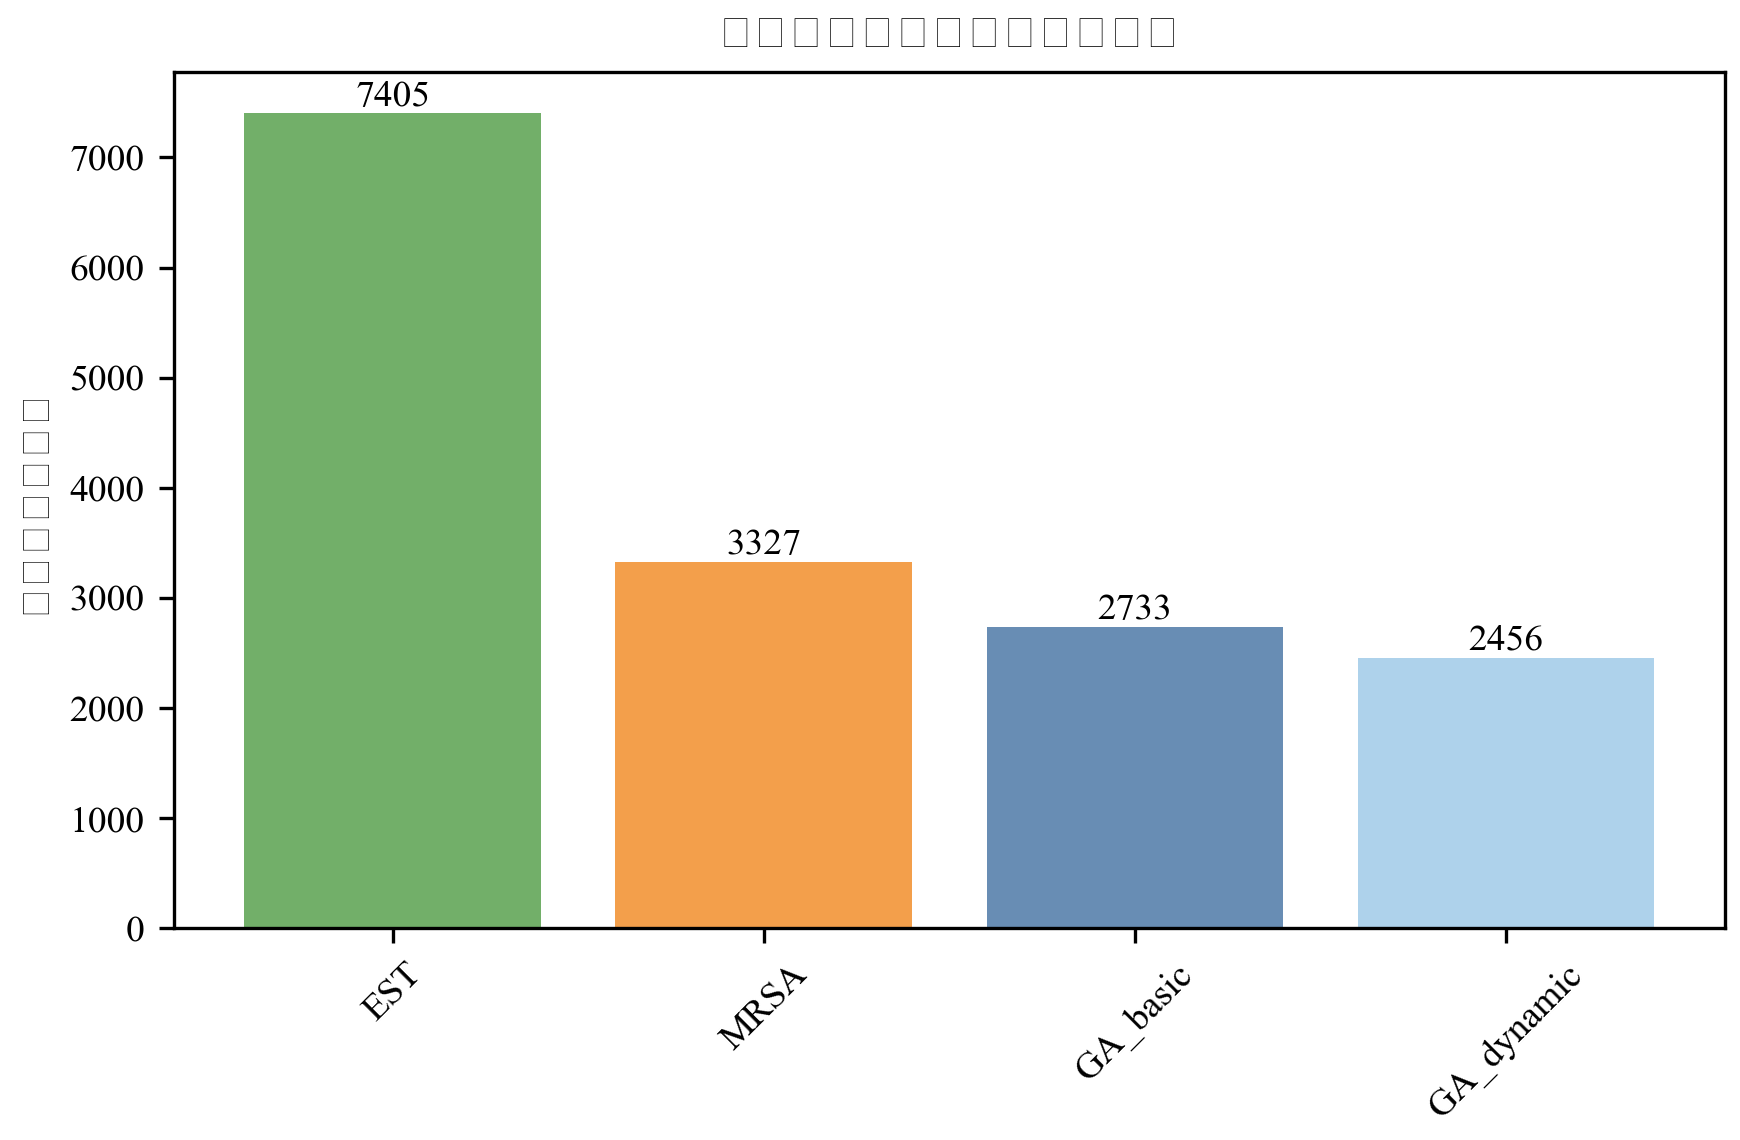

/tmp/ipykernel_1410559/1219954423.py:94: UserWarning: Glyph 21033 (\N{CJK UNIFIED IDEOGRAPH-5229}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:94: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:94: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:94: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:94: UserWarning: Glyph 35843 (\N{CJK UNIFIED IDEOGRAPH-8C03}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:94: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:94: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from curren

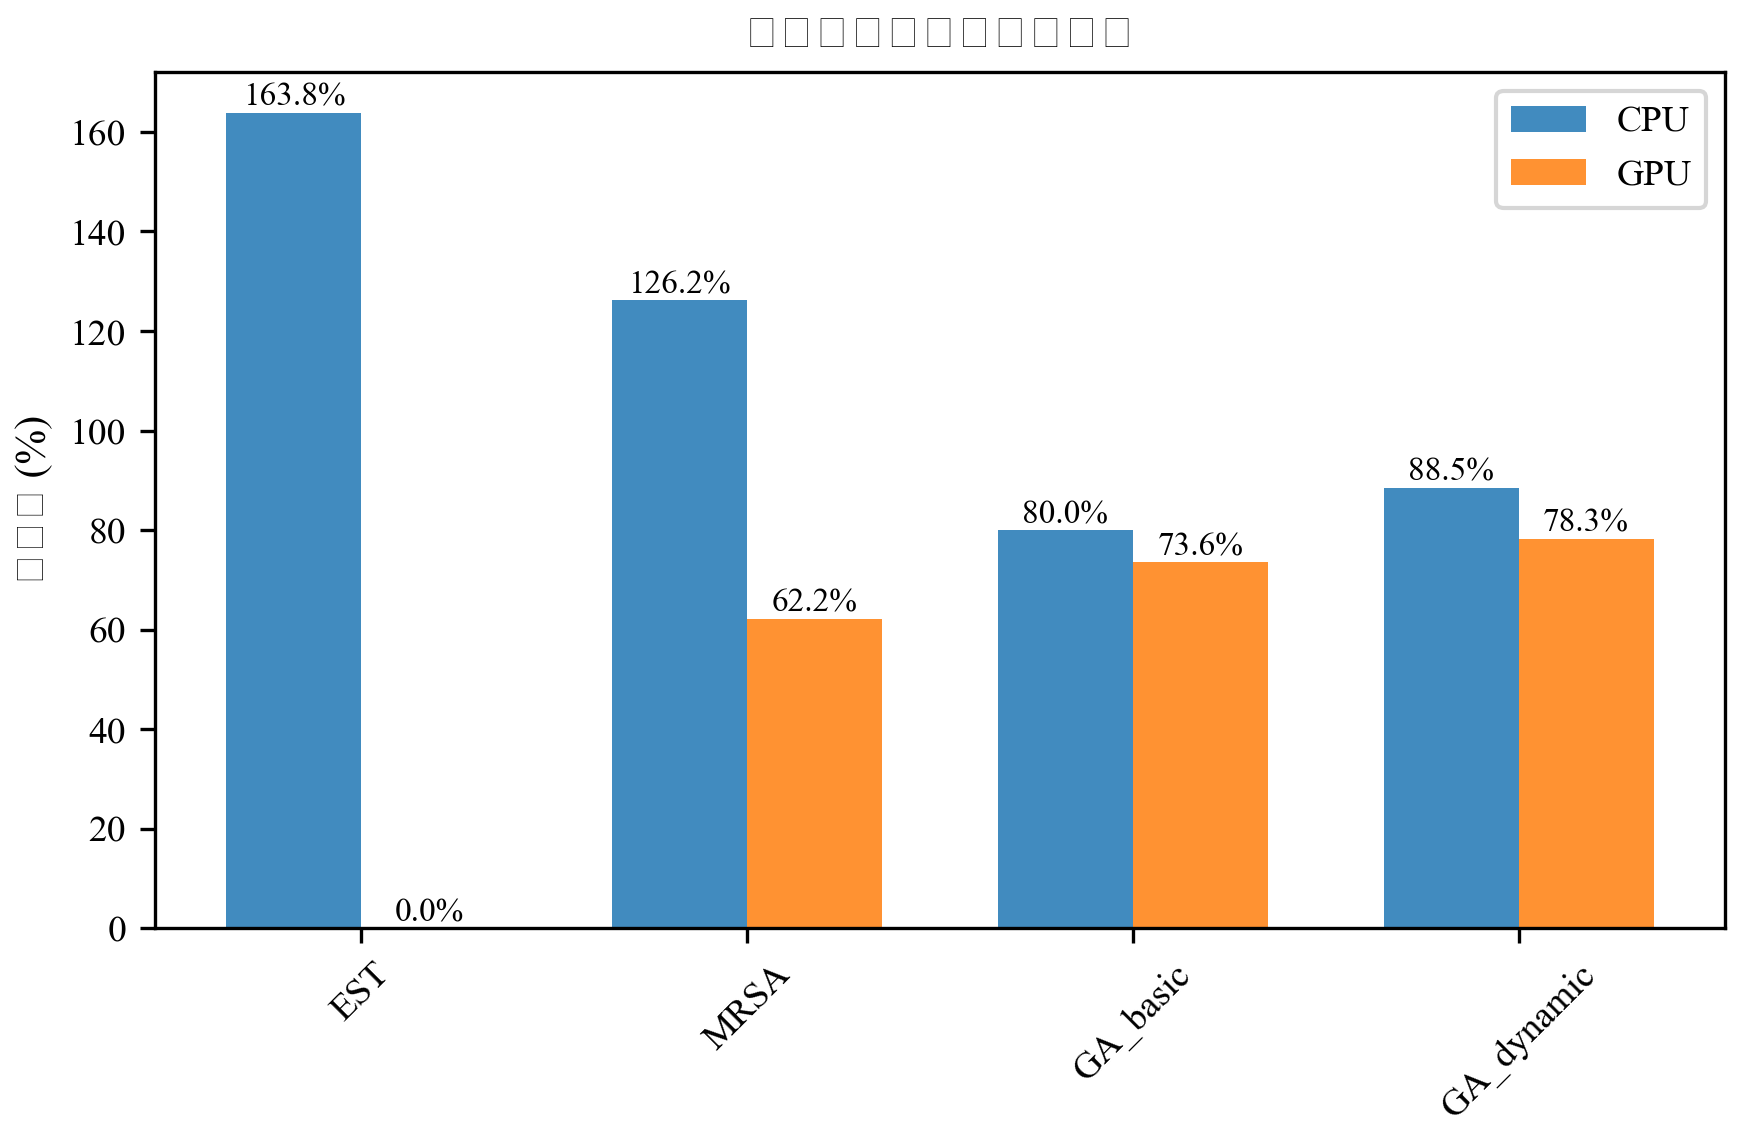

/tmp/ipykernel_1410559/1219954423.py:139: UserWarning: Glyph 35843 (\N{CJK UNIFIED IDEOGRAPH-8C03}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:139: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:139: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:139: UserWarning: Glyph 20219 (\N{CJK UNIFIED IDEOGRAPH-4EFB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:139: UserWarning: Glyph 21153 (\N{CJK UNIFIED IDEOGRAPH-52A1}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:139: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1219954423.py:139: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from

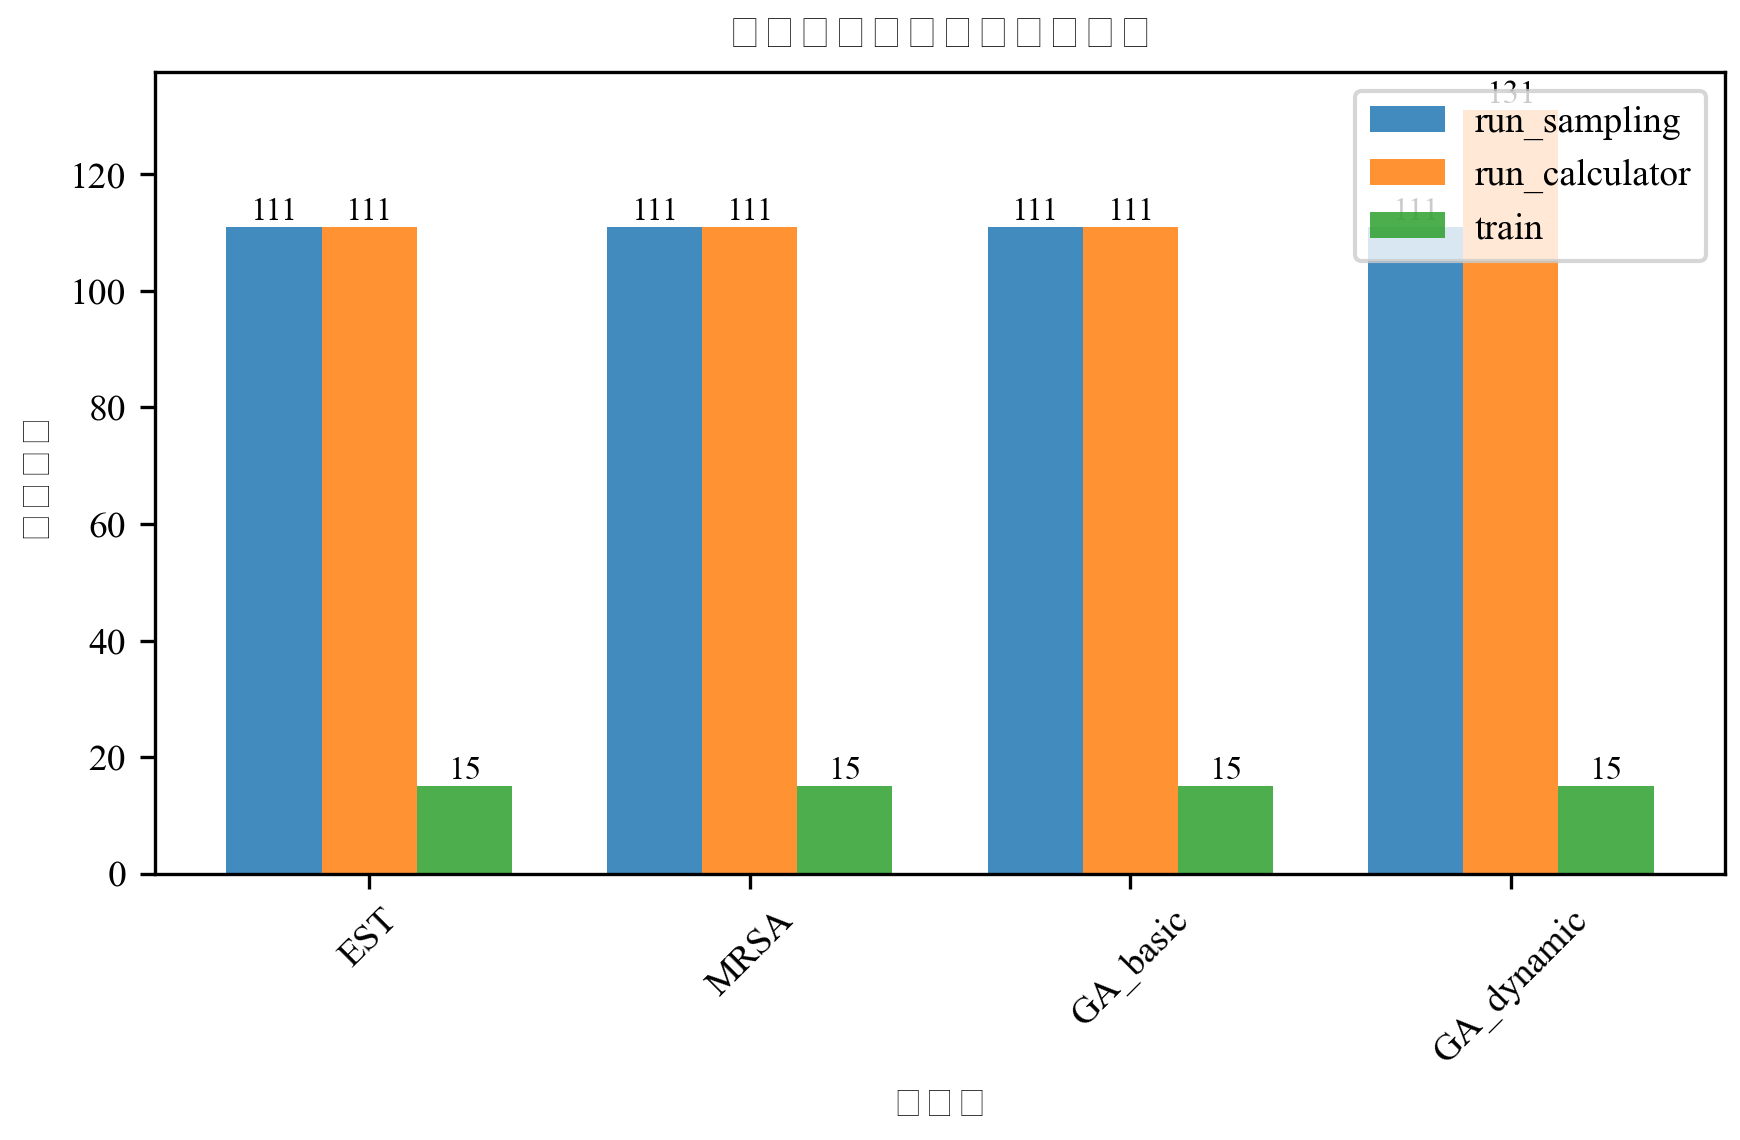

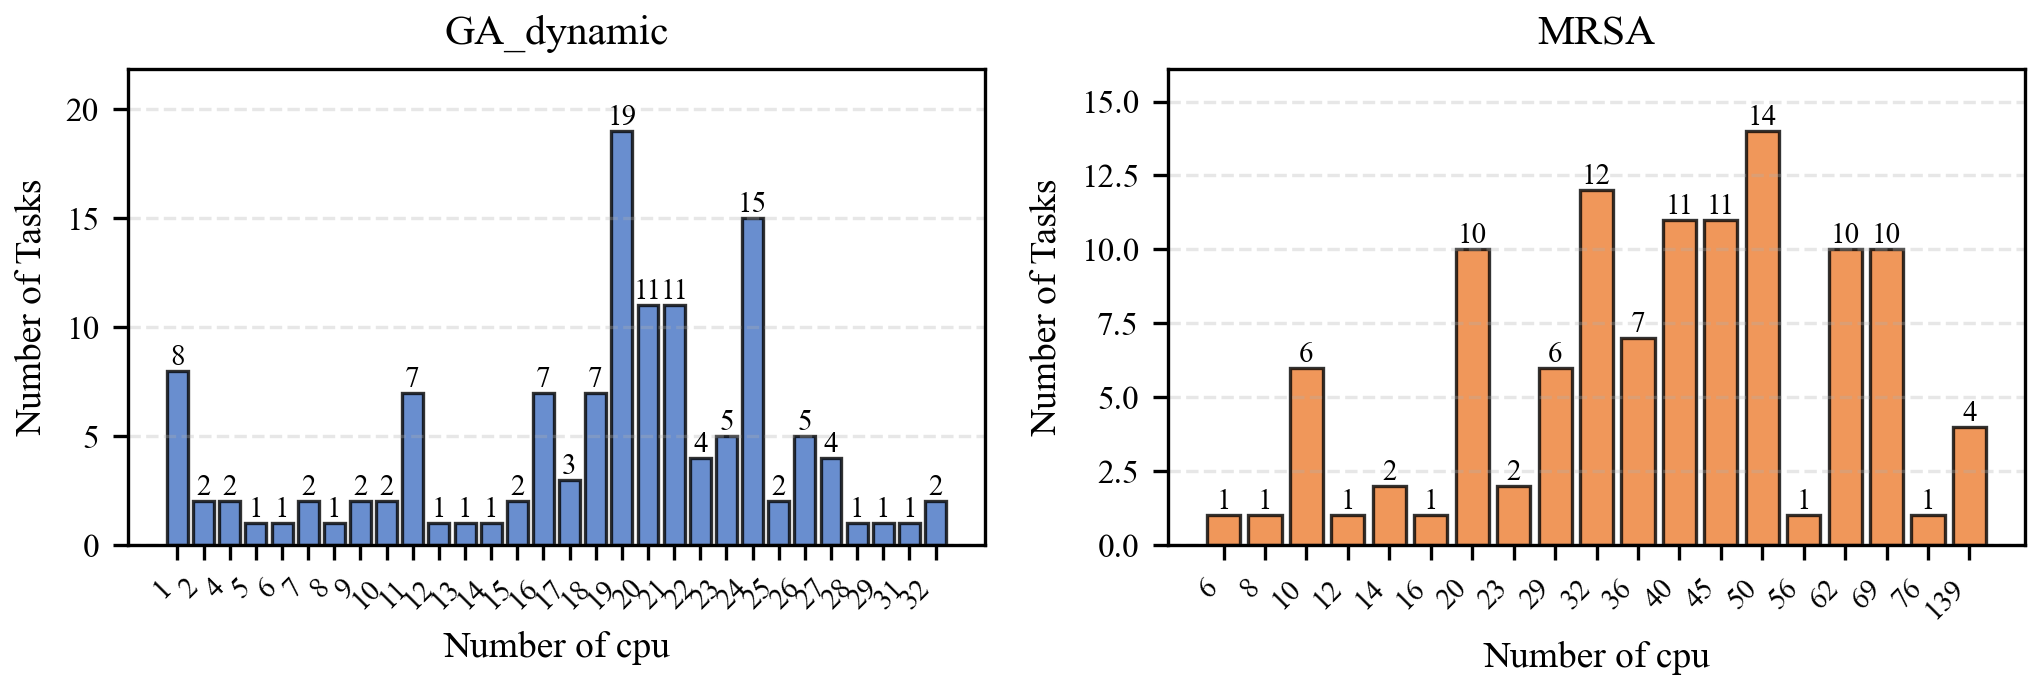

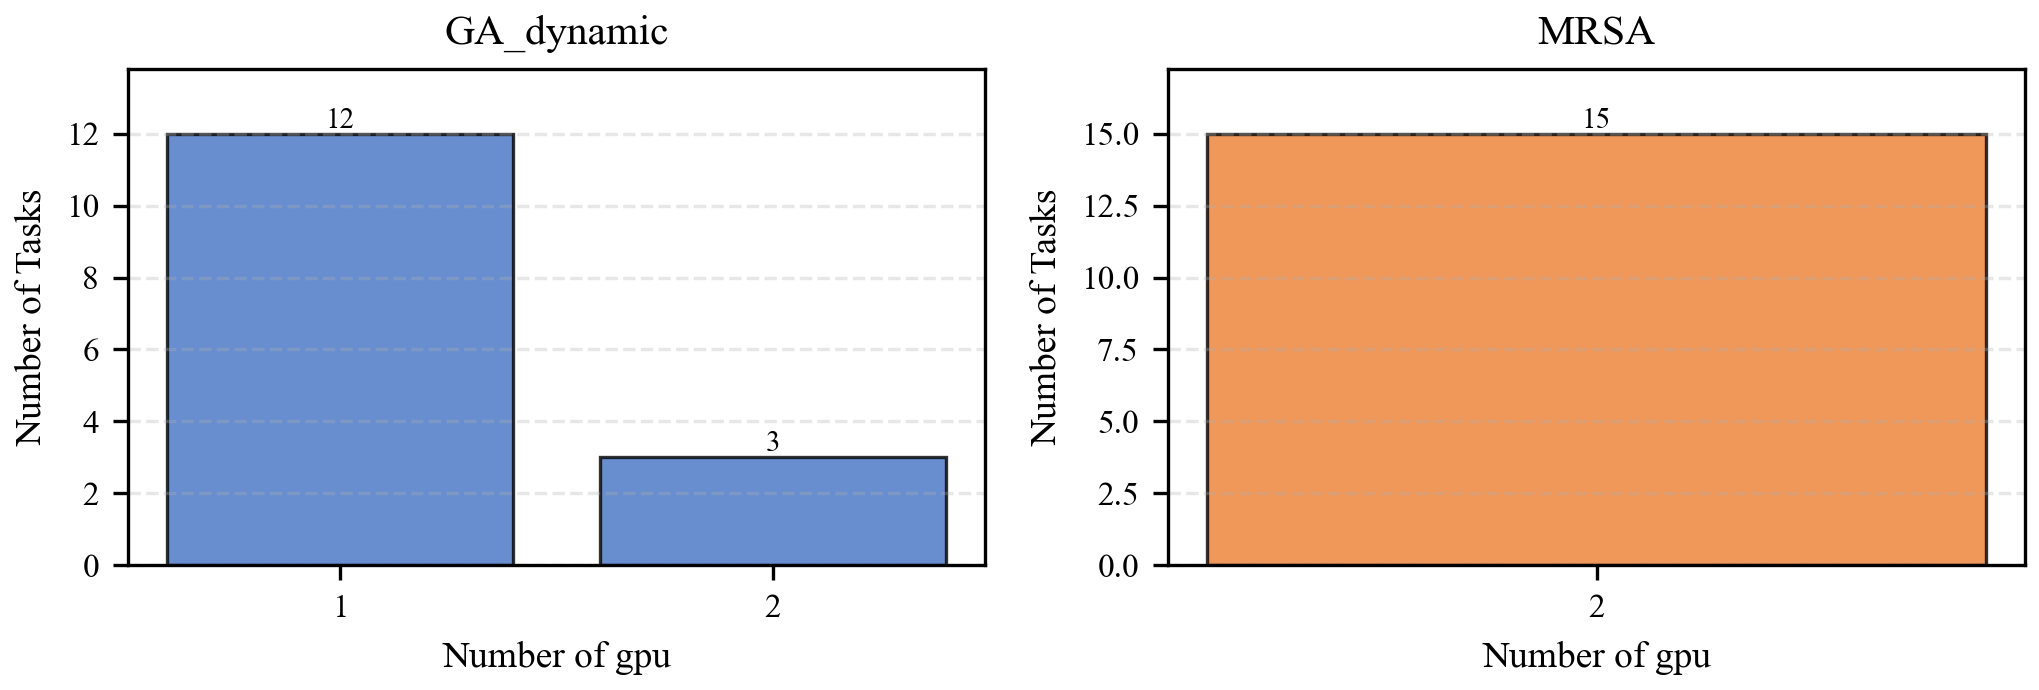

In [11]:
import matplotlib.pyplot as plt
import numpy as np

## 可视化
# ================== 参数配置 ==================
# 1. 调度器配色方案（降低饱和度）
scheduler_colors = {
    'GA_basic': '#4E79A7',    # 柔和的蓝色
    'GA_dynamic': '#A0CBE8',  # 更浅的蓝色
    'EST': '#59A14F',    # 柔和的绿色
    'MRSA': '#F28E2B',        # 橙色
    'MRSA_dynamic': '#FFBE7D' # 浅橙色
}

# 2. 全局样式参数
bar_alpha = 0.85  # 柱状图透明度
plt.rcParams.update({
    'font.size': 10,           # 全局字体大小，与论文正文一致
    'axes.titlesize': 11,      # 标题字体大小
    'axes.labelsize': 10,      # 坐标轴标签字体大小
    'xtick.labelsize': 9,      # x轴刻度标签字体大小
    'ytick.labelsize': 9,      # y轴刻度标签字体大小
    'legend.fontsize': 9,      # 图例字体大小
    # 'font.family': 'serif',    # 使用衬线字体（与论文一致）
    # 'font.serif': ['Times New Roman'],  # 指定Times New Roman字体
    # 'mathtext.fontset': 'stix' # 数学公式字体
})

# ================== 修改后的可视化代码 ==================
# 1. 完成时间对比（改进版）
def plot_wct_comparison():
    plt.figure(figsize=(6,4))  # 调整为更适合论文的尺寸
    schedulers = list(scheduler_data.keys())
    wcts = [x['wct'] for x in scheduler_data.values()]
    colors = [scheduler_colors[s] for s in schedulers]
    
    bars = plt.bar(schedulers, wcts, color=colors, alpha=bar_alpha)
    
    # 添加数值标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom',
                fontsize=9)  # 数值标签字体大小
    
    plt.title("各调度器工作流完成时间对比")
    plt.ylabel("完成时间（秒）")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('1_wct_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# 2. 资源利用率对比（改进版）
def plot_utilization():
    x = np.arange(len(scheduler_data))
    width = 0.35  # 调整宽度
    
    plt.figure(figsize=(6,4))  # 调整为更适合论文的尺寸
    
    # CPU利用率（深蓝色）
    cpu_bars = plt.bar(x - width/2, 
                      [x['cpu_util'] for x in scheduler_data.values()],
                      width, 
                      color='#1f77b4', 
                      alpha=bar_alpha,
                      label='CPU')
    
    # GPU利用率（橙色）
    gpu_bars = plt.bar(x + width/2, 
                      [x['gpu_util'] for x in scheduler_data.values()],
                      width, 
                      color='#ff7f0e', 
                      alpha=bar_alpha,
                      label='GPU')
    
    # 添加数值标签
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', 
                    fontsize=8)
    
    add_labels(cpu_bars)
    add_labels(gpu_bars)
    
    plt.xticks(x, scheduler_data.keys(), rotation=45)
    plt.title("各调度器资源利用率对比")
    plt.ylabel("利用率 (%)")
    plt.legend()
    plt.tight_layout()
    plt.savefig('2_utilization_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# 3. 任务特征分析（改进版）
def plot_task_features():
    task_types = ['run_sampling', 'run_calculator', 'train']
    fig = plt.figure(figsize=(6, 4))  # 调整为更适合论文的尺寸
    
    # 创建一个子图
    ax = fig.add_subplot(111)
    
    schedulers = list(scheduler_data.keys())
    x = np.arange(len(schedulers))  # 调度器位置
    width = 0.25  # 柱的宽度
    
    # 为每种任务类型绘制一组柱
    for i, task in enumerate(task_types):
        counts = [data['task_counts'][task] for data in scheduler_data.values()]
        bars = ax.bar(x + (i - 1) * width, counts, width, 
                     label=task, 
                     color=plt.cm.tab10(i),  # 使用不同颜色区分任务类型
                     alpha=bar_alpha)
        
        # 添加数值标签
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height}',
                   ha='center', va='bottom',
                   fontsize=8)
    
    # 设置图表标题和标签
    ax.set_title("各调度器不同任务数量对比")
    ax.set_ylabel("任务数量")
    ax.set_xlabel("调度器")
    
    # 设置x轴刻度标签
    ax.set_xticks(x)
    ax.set_xticklabels(schedulers, rotation=45)
    
    # 添加图例
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('3_task_features.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# 4.资源分布和可视化
# def plot_resource_distribution(schedulers=None, task_types=None, resource_type='cpu'):
#     """独立展示各调度器的CPU资源分布"""
#     # 获取调度器数量
#     if schedulers == None:
#         schedulers = list(scheduler_data.keys())
#     if task_types == None:
#         task_types = list(scheduler_data[schedulers[0]]['resource_distribution'].keys())
#     n_schedulers = len(schedulers)
    
#     for task_type in task_types:
#         # 计算子图布局 - 尝试保持更方形的布局
#         if n_schedulers <= 3:
#             nrows, ncols = 1, n_schedulers
#         else:
#             nrows = int(np.ceil(np.sqrt(n_schedulers)))
#             ncols = int(np.ceil(n_schedulers / nrows))
        
#         # 创建图形和子图（调整尺寸）
#         fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
#                                figsize=(4*ncols, 3*nrows))  # 更紧凑的尺寸
        
#         # 确保axes是一个数组
#         if n_schedulers == 1 or (nrows == 1 and ncols == 1):
#             axes = np.array([axes])
        
#         # 将axes转换为一维数组以便迭代
#         axes = axes.flatten()
        
#         # 为每个调度器创建一个子图
#         for i, scheduler in enumerate(schedulers):
#             ax = axes[i]
            
#             # 获取该调度器的资源分布
#             dist = scheduler_data[scheduler]['resource_distribution'][task_type][resource_type]
            
#             if not dist:  # 如果分布为空
#                 ax.text(0.5, 0.5, '无数据', 
#                     horizontalalignment='center', verticalalignment='center', 
#                     transform=ax.transAxes, fontsize=16)
#                 ax.set_title(f"{scheduler}", fontsize=16)
#                 continue
            
#             # 处理键的类型 - 确保可以排序
#             alloc_items = []
#             for k, v in dist.items():
#                 try:
#                     # 尝试将键转换为浮点数进行排序
#                     key = float(k)
#                     alloc_items.append((key, v, str(k)))  # 保存原始键以便显示
#                 except (ValueError, TypeError):
#                     # 如果不能转换，则保持原样
#                     alloc_items.append((k, v, str(k)))
            
#             # 排序
#             alloc_items.sort(key=lambda x: x[0])
            
#             # 分离排序后的数据
#             allocs_display = [item[2] for item in alloc_items]  # 显示用的标签
#             counts = [item[1] for item in alloc_items]
            
#             # 创建条形图
#             bars = ax.bar(allocs_display, counts, color='skyblue', alpha=0.7)
            
#             max_heights = 0
#             # 添加数据标签
#             for bar, count in zip(bars, counts):
#                 height = bar.get_height()
#                 max_heights = max(max_heights, height)
#                 if height > 0:  # 只在非零值上添加标签
#                     ax.text(bar.get_x() + bar.get_width()/2., height,
#                         f'{count}',
#                         ha='center', va='bottom',
#                         fontsize=8)
            
#             # 设置子图标题和标签
#             ax.set_title(f"{scheduler}", fontsize=10)
#             ax.set_xlabel(f"{resource_type}数", fontsize=9)
#             ax.set_ylabel("任务数量", fontsize=9)
#             ax.grid(axis='y', alpha=0.3)
#             ax.set_ylim(top=int(max_heights) * 1.15)
            
#             # 如果x轴项太多，旋转标签
#             if len(allocs_display) > 5:
#                 plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        
#         # 隐藏多余的子图
#         for j in range(i+1, len(axes)):
#             axes[j].set_visible(False)
        
#         # plt.suptitle(f"各调度器{task_type}任务{resource_type}分配分布", fontsize=11)
#         plt.tight_layout()
#         plt.savefig(f'5_{task_type}_{resource_type}_distribution.pdf', dpi=300, bbox_inches='tight')
#         plt.show()
#         plt.close()

def plot_resource_distribution(schedulers=None, task_types=None, resource_type='cpu'):
    """Display resource distribution for different schedulers"""
    # Get the number of schedulers
    if schedulers == None:
        schedulers = list(scheduler_data.keys())
    if task_types == None:
        task_types = list(scheduler_data[schedulers[0]]['resource_distribution'].keys())
    n_schedulers = len(schedulers)
    
    # Set the font to comply with ACM template
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['axes.labelsize'] = 9
    plt.rcParams['axes.titlesize'] = 10
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['legend.fontsize'] = 8
    
    # Professional color palette suitable for academic publications
    colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47', '#264478', '#9E480E']
    
    for task_type in task_types:
        # Calculate subplot layout - try to maintain a more square layout
        if n_schedulers <= 3:
            nrows, ncols = 1, n_schedulers
        else:
            nrows = int(np.ceil(np.sqrt(n_schedulers)))
            ncols = int(np.ceil(n_schedulers / nrows))
        
        # Create figure and subplots (adjust dimensions)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, 
                               figsize=(3.5*ncols, 2.5*nrows))  # More compact size for ACM
        
        # Ensure axes is an array
        if n_schedulers == 1 or (nrows == 1 and ncols == 1):
            axes = np.array([axes])
        
        # Convert axes to a flattened array for iteration
        axes = axes.flatten()
        
        # Create a subplot for each scheduler
        for i, scheduler in enumerate(schedulers):
            ax = axes[i]
            
            # Get resource distribution for this scheduler
            dist = scheduler_data[scheduler]['resource_distribution'][task_type][resource_type]
            
            if not dist:  # If distribution is empty
                ax.text(0.5, 0.5, 'No data', 
                    horizontalalignment='center', verticalalignment='center', 
                    transform=ax.transAxes, fontsize=10)
                ax.set_title(f"{scheduler}", fontsize=10)
                continue
            
            # Process key types - ensure they can be sorted
            alloc_items = []
            for k, v in dist.items():
                try:
                    # Try to convert key to float for sorting
                    key = float(k)
                    alloc_items.append((key, v, str(k)))  # Save original key for display
                except (ValueError, TypeError):
                    # If conversion fails, keep as is
                    alloc_items.append((k, v, str(k)))
            
            # Sort
            alloc_items.sort(key=lambda x: x[0])
            
            # Separate sorted data
            allocs_display = [item[2] for item in alloc_items]  # Labels for display
            counts = [item[1] for item in alloc_items]
            
            # Create bar chart with colors suitable for ACM
            bars = ax.bar(allocs_display, counts, color=colors[i % len(colors)], edgecolor='black', 
                         linewidth=0.8, alpha=0.8)
            
            max_heights = 0
            # Add data labels
            for bar, count in zip(bars, counts):
                height = bar.get_height()
                max_heights = max(max_heights, height)
                if height > 0:  # Only add labels on non-zero values
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{count}',
                        ha='center', va='bottom',
                        fontsize=7)
            
            # Set subplot title and labels
            ax.set_title(f"{scheduler}", fontsize=10)
            ax.set_xlabel(f"Number of {resource_type}", fontsize=9)
            ax.set_ylabel("Number of Tasks", fontsize=9)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(top=int(max_heights) * 1.15)
            
            # If there are too many x-axis items, rotate labels
            if len(allocs_display) > 5:
                plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
            
            # Set spines (borders) to be thinner
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)
        
        # Hide excess subplots
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.savefig(f'5_{task_type}_{resource_type}_distribution.pdf', dpi=600, format='pdf', 
                   bbox_inches='tight')
        plt.show()
        plt.close()
# 执行绘图函数
schedulers = ["GA_dynamic", "MRSA"]
plot_wct_comparison()
plot_utilization()
plot_task_features()
plot_resource_distribution(schedulers=schedulers, task_types=["run_calculator"])
plot_resource_distribution(schedulers=schedulers, task_types=["train"], resource_type='gpu')

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from collections import defaultdict
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Set publication-quality plot parameters for ACM paper format
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Color scheme for ACM paper
scheduler_colors = {
    'GA_basic': '#4E79A7',
    'GA_dynamic': '#A0CBE8',
    'EST': '#59A14F',
    'MRSA': '#F28E2B',
    'MRSA_dynamic': '#FFBE7D'
}

# Using your provided data loading function
def load_results(path: Path, task_type) -> pd.DataFrame:
    """Load the results from a run.
    
    Args:
        path: Path to the run directory.
    Returns:
        Dataframe of all results
    """
    
    # Loop over inference, training, and simulation results
    output = []
    for task in task_type:
        # Load the results
        data = path / f'{task}.json'
        assert data.is_file(), f'Could not find {data}'
        results = pd.read_json(data, lines=True)
        output.append(results)
    output = pd.concat(output)
    return output

# Function to process data into the format needed for visualization
def process_data(results_df, resources_path):
    """Process the results DataFrame to extract metrics for visualization.
    
    Args:
        results_df: DataFrame containing task execution data
        resources_path: Path to resources.ini file
    
    Returns:
        Dict containing processed metrics
    """
    # Extract available resources (assuming this can be parsed from resources.ini)
    # This is a placeholder - adjust based on how you actually read resources
    total_resources = {'cpu': 144, 'gpu': 2}  # Example values
    
    # Initialize metrics dictionary
    metrics = {
        'task_counts': defaultdict(int),
        'resource_distribution': defaultdict(lambda: {'cpu': defaultdict(int), 'gpu': defaultdict(int)}),
        'task_stats': defaultdict(lambda: {'execution_time': [], 'wait_time': []}),
        'task_timing': defaultdict(lambda: {'start_times': [], 'wait_times': []})
    }
    
    # Calculate workflow completion time (WCT)
    if not results_df.empty:
        start_time = results_df['time_created'].min()
        end_time = results_df['time_result_received'].max()
        metrics['wct'] = end_time - start_time
    else:
        metrics['wct'] = 0
    
    # Initialize for utilization calculations
    total_cpu_time = 0
    total_gpu_time = 0
    
    # Group by task type (method)
    for method, group in results_df.groupby('method'):
        # Count tasks per type
        metrics['task_counts'][method] = len(group)
        
        # Process each task
        for _, task in group.iterrows():
            # Resource distribution
            cpu_count = len(task['resources']['cpu']) if isinstance(task['resources']['cpu'], list) else task['resources']['cpu']
            gpu_count = len(task['resources']['gpu']) if isinstance(task['resources']['gpu'], list) else 0
            
            metrics['resource_distribution'][method]['cpu'][str(cpu_count)] += 1
            metrics['resource_distribution'][method]['gpu'][str(gpu_count)] += 1
            
            # Execution time
            execution_time = task['time_compute_ended'] - task['time_compute_started']
            metrics['task_stats'][method]['execution_time'].append(execution_time)
            
            # Wait time
            wait_time = task['time_compute_started'] - task['time_created']
            metrics['task_stats'][method]['wait_time'].append(wait_time)
            
            # Add to task timing
            metrics['task_timing'][method]['start_times'].append(task['time_compute_started'] - start_time)
            metrics['task_timing'][method]['wait_times'].append(wait_time)
            
            # Accumulate resource usage time
            total_cpu_time += execution_time * cpu_count
            total_gpu_time += execution_time * gpu_count
    
    # Calculate average CPU/GPU allocation per task type
    metrics['avg_cpu_alloc'] = {}
    metrics['avg_gpu_alloc'] = {}
    
    for method in metrics['resource_distribution'].keys():
        # CPU allocation
        cpu_dist = metrics['resource_distribution'][method]['cpu']
        total_tasks = sum(cpu_dist.values())
        if total_tasks > 0:
            avg_cpu = sum(float(k) * v for k, v in cpu_dist.items()) / total_tasks
            metrics['avg_cpu_alloc'][method] = avg_cpu
        else:
            metrics['avg_cpu_alloc'][method] = 0
        
        # GPU allocation
        gpu_dist = metrics['resource_distribution'][method]['gpu']
        total_tasks = sum(gpu_dist.values())
        if total_tasks > 0:
            avg_gpu = sum(float(k) * v for k, v in gpu_dist.items()) / total_tasks
            metrics['avg_gpu_alloc'][method] = avg_gpu
        else:
            metrics['avg_gpu_alloc'][method] = 0
    
    # Calculate average wait time per task type
    metrics['avg_wait_time'] = {}
    for method in metrics['task_stats'].keys():
        if metrics['task_stats'][method]['wait_time']:
            metrics['avg_wait_time'][method] = np.mean(metrics['task_stats'][method]['wait_time'])
        else:
            metrics['avg_wait_time'][method] = 0
    
    # Calculate overall average wait time
    all_wait_times = [wait for method_stats in metrics['task_stats'].values() 
                     for wait in method_stats['wait_time']]
    metrics['avg_wait_time']['overall'] = np.mean(all_wait_times) if all_wait_times else 0
    
    # Calculate resource utilization
    if metrics['wct'] > 0:
        # Assuming total_resources contains the total available CPU and GPU counts
        metrics['cluster_utilization'] = {
            'cpu_utilization': total_cpu_time / (metrics['wct'] * total_resources['cpu']),
            'gpu_utilization': total_gpu_time / (metrics['wct'] * total_resources['gpu']) if total_resources['gpu'] > 0 else 0
        }
    else:
        metrics['cluster_utilization'] = {'cpu_utilization': 0, 'gpu_utilization': 0}
    
    return metrics

# Generate workflow report from results
def generate_workflow_report(results_df, resources_path=None):
    """Generate a comprehensive workflow report from task results."""
    return process_data(results_df, resources_path)

# Collect data for all schedulers
def collect_scheduler_data(scheduler_paths, resources_path, task_type):
    scheduler_data = {}
    
    for scheduler_type, path in scheduler_paths.items():
        results = load_results(path, task_type)
        report = generate_workflow_report(results, resources_path=resources_path)
        
        scheduler_data[scheduler_type] = {
            'wct': report['wct'],
            'cpu_util': report['cluster_utilization']['cpu_utilization'] * 100,
            'gpu_util': report['cluster_utilization']['gpu_utilization'] * 100,
            'task_counts': report['task_counts'],
            'avg_cpu_alloc': report['avg_cpu_alloc'],
            'avg_gpu_alloc': report['avg_gpu_alloc'],
            'task_stats': report['task_stats'],
            'resource_distribution': report['resource_distribution'],
            'task_timing': report['task_timing'],
            'avg_wait_time': report['avg_wait_time']
        }
    
    return scheduler_data

# 1. Plot resource distribution with average indicators
def plot_resource_distribution_with_avg(scheduler_data, schedulers, task_type, resource_type='cpu', filename=None):
    """Plot resource distribution with average indicators for ACM paper"""
    fig, axes = plt.subplots(1, len(schedulers), figsize=(7, 3), sharey=True)
    
    if len(schedulers) == 1:
        axes = [axes]  # Handle single scheduler case
    
    max_y = 0
    for i, scheduler in enumerate(schedulers):
        ax = axes[i]
        
        # Get resource distribution
        dist = scheduler_data[scheduler]['resource_distribution'][task_type][resource_type]
        
        if not dist:
            ax.text(0.5, 0.5, 'No data available', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{scheduler}", fontsize=9)
            continue
        
        # Sort keys numerically
        sorted_items = sorted([(int(k) if k.isdigit() else k, v) for k, v in dist.items()])
        x_vals = [str(k) for k, v in sorted_items]
        y_vals = [v for k, v in sorted_items]
        
        # Plot bars
        bars = ax.bar(x_vals, y_vals, color=scheduler_colors[scheduler], alpha=0.8)
        
        # Find maximum y value for consistent scaling
        max_y = max(max_y, max(y_vals) * 1.2)
        
        # Add value labels above bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{int(height)}', ha='center', va='bottom', fontsize=7)
        
        # Plot average allocation line
        if task_type in scheduler_data[scheduler]['avg_' + resource_type + '_alloc']:
            avg_val = scheduler_data[scheduler]['avg_' + resource_type + '_alloc'][task_type]
            ax.axvline(avg_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
            
            # Add average value annotation
            ax.text(avg_val, max_y * 0.9, f'Avg: {avg_val:.1f}', 
                    color='red', ha='center', va='top', fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            
            # Add resource area annotation
            if task_type in scheduler_data[scheduler]['task_counts']:
                resource_area = avg_val * scheduler_data[scheduler]['task_counts'][task_type]
                ax.text(0.5, max_y * 0.8, f'Area: {resource_area:.0f}', 
                        ha='center', va='top', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
                        transform=ax.transAxes)
        
        # Customize subplot
        ax.set_title(f"{scheduler}", fontsize=9)
        ax.set_xlabel(f"{resource_type.upper()} Allocation", fontsize=8)
        if i == 0:
            ax.set_ylabel("Number of Tasks", fontsize=8)
        ax.grid(axis='y', alpha=0.3)
    
    # Set common y limit
    for ax in axes:
        ax.set_ylim(0, max_y)
    
    task_name = task_type.replace('_', ' ').title() if isinstance(task_type, str) else task_type
    plt.suptitle(f"{task_name} {resource_type.upper()} Resource Distribution", fontsize=10)
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
    else:
        plt.show()
    plt.close()

# 2. Plot task timing analysis with start and wait times
def plot_task_timing(scheduler_data, schedulers, task_type='run_calculator', filename=None):
    """Plot task timing analysis showing start times and wait times for ACM paper"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))
    
    # Plot 1: Cumulative task start times
    for scheduler in schedulers:
        if task_type in scheduler_data[scheduler]['task_timing'] and scheduler_data[scheduler]['task_timing'][task_type]['start_times']:
            start_times = sorted(scheduler_data[scheduler]['task_timing'][task_type]['start_times'])
            cumulative_tasks = np.arange(1, len(start_times) + 1)
            
            ax1.plot(start_times, cumulative_tasks, 
                    marker='o', markersize=4, markevery=max(1, len(start_times)//10),
                    label=scheduler, color=scheduler_colors[scheduler], alpha=0.8)
    
    # Add completion time markers
    for scheduler in schedulers:
        wct = scheduler_data[scheduler]['wct']
        if task_type in scheduler_data[scheduler]['task_timing'] and scheduler_data[scheduler]['task_timing'][task_type]['start_times']:
            max_tasks = len(scheduler_data[scheduler]['task_timing'][task_type]['start_times'])
            ax1.plot([wct, wct], [0, max_tasks], linestyle='--', color=scheduler_colors[scheduler], alpha=0.5)
            ax1.text(wct, max_tasks * 0.5, f'{scheduler}\n{wct:.0f}s', 
                    rotation=90, ha='right', va='center', fontsize=7,
                    color=scheduler_colors[scheduler])
    
    ax1.set_xlabel('Time (seconds)', fontsize=9)
    ax1.set_ylabel('Cumulative Tasks Started', fontsize=9)
    ax1.set_title('Task Start Time Progression', fontsize=10)
    ax1.grid(alpha=0.3)
    ax1.legend(loc='best', fontsize=7)
    
    # Plot 2: Average wait times
    wait_times = []
    labels = []
    colors = []
    
    for scheduler in schedulers:
        if 'overall' in scheduler_data[scheduler]['avg_wait_time']:
            wait_times.append(scheduler_data[scheduler]['avg_wait_time']['overall'])
            labels.append(scheduler)
            colors.append(scheduler_colors[scheduler])
        elif task_type in scheduler_data[scheduler]['avg_wait_time']:
            wait_times.append(scheduler_data[scheduler]['avg_wait_time'][task_type])
            labels.append(scheduler)
            colors.append(scheduler_colors[scheduler])
    
    if wait_times:
        bars = ax2.bar(labels, wait_times, color=colors, alpha=0.8)
        
        # Add value labels above bars
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}s', ha='center', va='bottom', fontsize=8)
        
        ax2.set_xlabel('Scheduler', fontsize=9)
        ax2.set_ylabel('Average Wait Time (seconds)', fontsize=9)
        ax2.set_title('Task Wait Time Comparison', fontsize=10)
        ax2.grid(axis='y', alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No wait time data available', 
               ha='center', va='center', transform=ax2.transAxes)
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
    else:
        plt.show()
    plt.close()

# 3. Plot resource area comparison
def plot_resource_area_comparison(scheduler_data, schedulers=None, filename=None):
    """Plot resource allocation area by task type for ACM paper"""
    if schedulers is None:
        schedulers = list(scheduler_data.keys())
    
    # Calculate resource area for each scheduler and task type
    resource_area = {}
    
    # Find all task types across all schedulers
    all_task_types = set()
    for scheduler in schedulers:
        for task_type in scheduler_data[scheduler]['task_counts'].keys():
            all_task_types.add(task_type)
    
    for scheduler in schedulers:
        resource_area[scheduler] = {}
        for task_type in all_task_types:
            if task_type in scheduler_data[scheduler]['avg_cpu_alloc'] and task_type in scheduler_data[scheduler]['task_counts']:
                cpu_alloc = scheduler_data[scheduler]['avg_cpu_alloc'][task_type]
                gpu_alloc = scheduler_data[scheduler]['avg_gpu_alloc'].get(task_type, 0)
                task_count = scheduler_data[scheduler]['task_counts'][task_type]
                
                # Calculate area (CPU + GPU * weight)
                gpu_weight = 10  # GPU resources are weighted more heavily
                resource_area[scheduler][task_type] = (cpu_alloc + gpu_alloc * gpu_weight) * task_count
            else:
                resource_area[scheduler][task_type] = 0
    
    # Prepare data for stacked bar chart
    task_types = list(all_task_types)
    
    # Define task color mapping
    task_colors = {
        'run_sampling': '#8dd3c7',
        'run_calculator': '#bebada',
        'train': '#fb8072'
    }
    
    # Add colors for any additional task types
    default_colors = ['#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd', '#ccebc5', '#ffed6f']
    for i, task in enumerate([t for t in task_types if t not in task_colors]):
        task_colors[task] = default_colors[i % len(default_colors)]
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    bottom = np.zeros(len(schedulers))
    for task in task_types:
        values = [resource_area[s].get(task, 0) for s in schedulers]
        p = ax.bar(schedulers, values, bottom=bottom, label=task.replace('_', ' ').title(),
                  color=task_colors[task], alpha=0.8)
        
        # Add value labels for significant segments
        for i, v in enumerate(values):
            if v > 200:  # Only label segments that are large enough
                task_name = task.split('_')[-1] if '_' in task else task
                ax.text(i, bottom[i] + v/2, f'{task_name}\n{int(v)}',
                      ha='center', va='center', fontsize=7, color='black')
        
        bottom += values
    
    # Add total resource area labels on top
    for i, s in enumerate(schedulers):
        total = sum(resource_area[s].values())
        ax.text(i, bottom[i] + 20, f'Total: {int(total)}',
              ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax.set_title('Resource Allocation Area by Task Type and Scheduler', fontsize=10)
    ax.set_ylabel('Resource Area (CPU + GPU×10 × Tasks)', fontsize=9)
    ax.set_xlabel('Scheduler', fontsize=9)
    ax.legend(title='Task Type', loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
    else:
        plt.show()
    plt.close()

# 4. Plot combined performance metrics
def plot_performance_comparison(scheduler_data, schedulers=None, filename=None):
    """Plot combined performance metrics for ACM paper"""
    if schedulers is None:
        schedulers = list(scheduler_data.keys())
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    x = np.arange(len(schedulers))
    width = 0.2
    
    # Normalize metrics relative to best performer
    wct_values = [scheduler_data[s]['wct'] for s in schedulers]
    norm_wct = [min(wct_values) / v for v in wct_values]
    
    cpu_util = [scheduler_data[s]['cpu_util'] / 100 for s in schedulers]
    norm_cpu = [v / max(cpu_util) for v in cpu_util]
    
    gpu_util = [scheduler_data[s]['gpu_util'] / 100 for s in schedulers]
    if max(gpu_util) > 0:
        norm_gpu = [v / max(gpu_util) for v in gpu_util]
    else:
        norm_gpu = [0] * len(schedulers)
    
    # Get wait time data
    wait_time = []
    for s in schedulers:
        if 'overall' in scheduler_data[s]['avg_wait_time']:
            wait_time.append(scheduler_data[s]['avg_wait_time']['overall'])
        else:
            # Use average of available task-specific wait times
            task_wait_times = [v for k, v in scheduler_data[s]['avg_wait_time'].items() if k != 'overall']
            wait_time.append(np.mean(task_wait_times) if task_wait_times else 0)
    
    if any(wait_time) and min(wait_time) > 0:
        norm_wait = [min(wait_time) / v if v > 0 else 0 for v in wait_time]
    else:
        norm_wait = [0] * len(schedulers)
    
    # Plot normalized metrics
    ax.bar(x - 1.5*width, norm_wct, width, label='Speedup (WCT⁻¹)', color='#4c78a8')
    ax.bar(x - 0.5*width, norm_cpu, width, label='CPU Utilization', color='#72b7b2')
    ax.bar(x + 0.5*width, norm_gpu, width, label='GPU Utilization', color='#f58518')
    ax.bar(x + 1.5*width, norm_wait, width, label='Wait Time Efficiency', color='#e45756')
    
    # Add numeric labels
    for i, v in enumerate(norm_wct):
        ax.text(i - 1.5*width, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    for i, v in enumerate(norm_cpu):
        ax.text(i - 0.5*width, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    for i, v in enumerate(norm_gpu):
        ax.text(i + 0.5*width, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    for i, v in enumerate(norm_wait):
        ax.text(i + 1.5*width, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(schedulers)
    ax.set_ylim(0, 1.2)
    ax.set_title('Normalized Performance Metrics Comparison', fontsize=10)
    ax.set_ylabel('Normalized Value (higher is better)', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
    else:
        plt.show()
    plt.close()

# 5. Plot workflow completion time comparison
def plot_wct_comparison(scheduler_data, schedulers=None, filename=None):
    """Plot workflow completion time comparison"""
    if schedulers is None:
        schedulers = list(scheduler_data.keys())
    
    plt.figure(figsize=(7, 4))
    
    wcts = [scheduler_data[s]['wct'] for s in schedulers]
    colors = [scheduler_colors[s] for s in schedulers]
    
    bars = plt.bar(schedulers, wcts, color=colors, alpha=0.8)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}',
                ha='center', va='bottom',
                fontsize=9)
    
    plt.title("Workflow Completion Time Comparison", fontsize=10)
    plt.ylabel("Completion Time (seconds)", fontsize=9)
    plt.xlabel("Scheduler", fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
    else:
        plt.show()
    plt.close()

# 6. Plot resource utilization comparison
def plot_utilization(scheduler_data, schedulers=None, filename=None):
    """Plot resource utilization comparison"""
    if schedulers is None:
        schedulers = list(scheduler_data.keys())
    
    x = np.arange(len(schedulers))
    width = 0.35
    
    plt.figure(figsize=(7, 4))
    
    # CPU utilization
    cpu_values = [scheduler_data[s]['cpu_util'] for s in schedulers]
    cpu_bars = plt.bar(x - width/2, cpu_values, width, 
                       color='#1f77b4', alpha=0.8, label='CPU')
    
    # GPU utilization
    gpu_values = [scheduler_data[s]['gpu_util'] for s in schedulers]
    gpu_bars = plt.bar(x + width/2, gpu_values, width, 
                       color='#ff7f0e', alpha=0.8, label='GPU')
    
    # Add value labels
    for i, bar in enumerate(cpu_bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', 
                fontsize=8)
    
    for i, bar in enumerate(gpu_bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', 
                fontsize=8)
    
    plt.xticks(x, schedulers)
    plt.title("Resource Utilization Comparison", fontsize=10)
    plt.ylabel("Utilization (%)", fontsize=9)
    plt.xlabel("Scheduler", fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
    else:
        plt.show()
    plt.close()

# 7. Plot task distribution by type
def plot_task_distribution(scheduler_data, schedulers=None, filename=None):
    """Plot task count distribution by type"""
    if schedulers is None:
        schedulers = list(scheduler_data.keys())
    
    # Find all task types
    task_types = set()
    for s in schedulers:
        task_types.update(scheduler_data[s]['task_counts'].keys())
    task_types = sorted(task_types)
    
    # Define task colors
    task_colors = {
        'run_sampling': '#8dd3c7',
        'run_calculator': '#bebada',
        'train': '#fb8072'
    }
    # Add colors for any additional task types
    default_colors = ['#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd']
    for i, task in enumerate([t for t in task_types if t not in task_colors]):
        task_colors[task] = default_colors[i % len(default_colors)]
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    x = np.arange(len(schedulers))
    width = 0.8 / len(task_types)
    
    for i, task_type in enumerate(task_types):
        values = [scheduler_data[s]['task_counts'].get(task_type, 0) for s in schedulers]
        offset = (i - len(task_types)/2 + 0.5) * width
        bars = ax.bar(x + offset, values, width, label=task_type.replace('_', ' ').title(),
                      color=task_colors.get(task_type, default_colors[i % len(default_colors)]))
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', 
                       fontsize=7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(schedulers)
    ax.set_title("Task Distribution by Type and Scheduler", fontsize=10)
    ax.set_ylabel("Number of Tasks", fontsize=9)
    ax.set_xlabel("Scheduler", fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title="Task Type", fontsize=8)
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
    else:
        plt.show()
    plt.close()

# Example usage with data collection from your system
task_type = ['sampling-results', 'training-results', 'simulation-results']

# Configuration 2 - Load 1
resources_path = Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/resources.ini'))
scheduler_paths = {
    'EST': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/dft-md-25Mar31-010700-2d4692')),
    'MRSA': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250328_032817_mrsa3_2gpu_3416/dft-md-25Mar28-032901-55b3ea')),
    'GA_basic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250401_181152_ga_basic_2gpu_2733/dft-md-25Apr01-181247-968e04')),
    'GA_dynamic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_224203_ga_dynamic_2gpu_2455/dft-md-25Mar30-224253-3f6843')),
}

# Collect data for all schedulers
scheduler_data = collect_scheduler_data(scheduler_paths, resources_path, task_type)

# Plot visualizations specifically comparing GA_dynamic and MRSA
selected_schedulers = ["GA_dynamic", "MRSA"]

# Generate all plots
plot_wct_comparison(scheduler_data, filename='fig1_wct_comparison.pdf')
plot_utilization(scheduler_data, filename='fig2_utilization_comparison.pdf')
plot_task_distribution(scheduler_data, filename='fig3_task_distribution.pdf')
plot_resource_distribution_with_avg(scheduler_data, selected_schedulers, "run_calculator", 'cpu', filename='fig4_calculator_cpu_distribution.pdf')
plot_resource_distribution_with_avg(scheduler_data, selected_schedulers, "train", 'gpu', filename='fig5_train_gpu_distribution.pdf')
plot_task_timing(scheduler_data, selected_schedulers, 'run_calculator', filename='fig6_task_timing.pdf')
plot_resource_area_comparison(scheduler_data, filename='fig7_resource_area.pdf')
plot_performance_comparison(scheduler_data, filename='fig8_performance_metrics.pdf')

/tmp/ipykernel_1410559/1824298648.py:270: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1410559/1824298648.py:270: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/tmp/ipykernel_1410559/1824298648.py:493: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1410559/1824298648.py:496: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.savefig(filename)
/tmp/ipykernel_1410559/1824298648.py:496: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from current font.
  plt.savefig(filename)


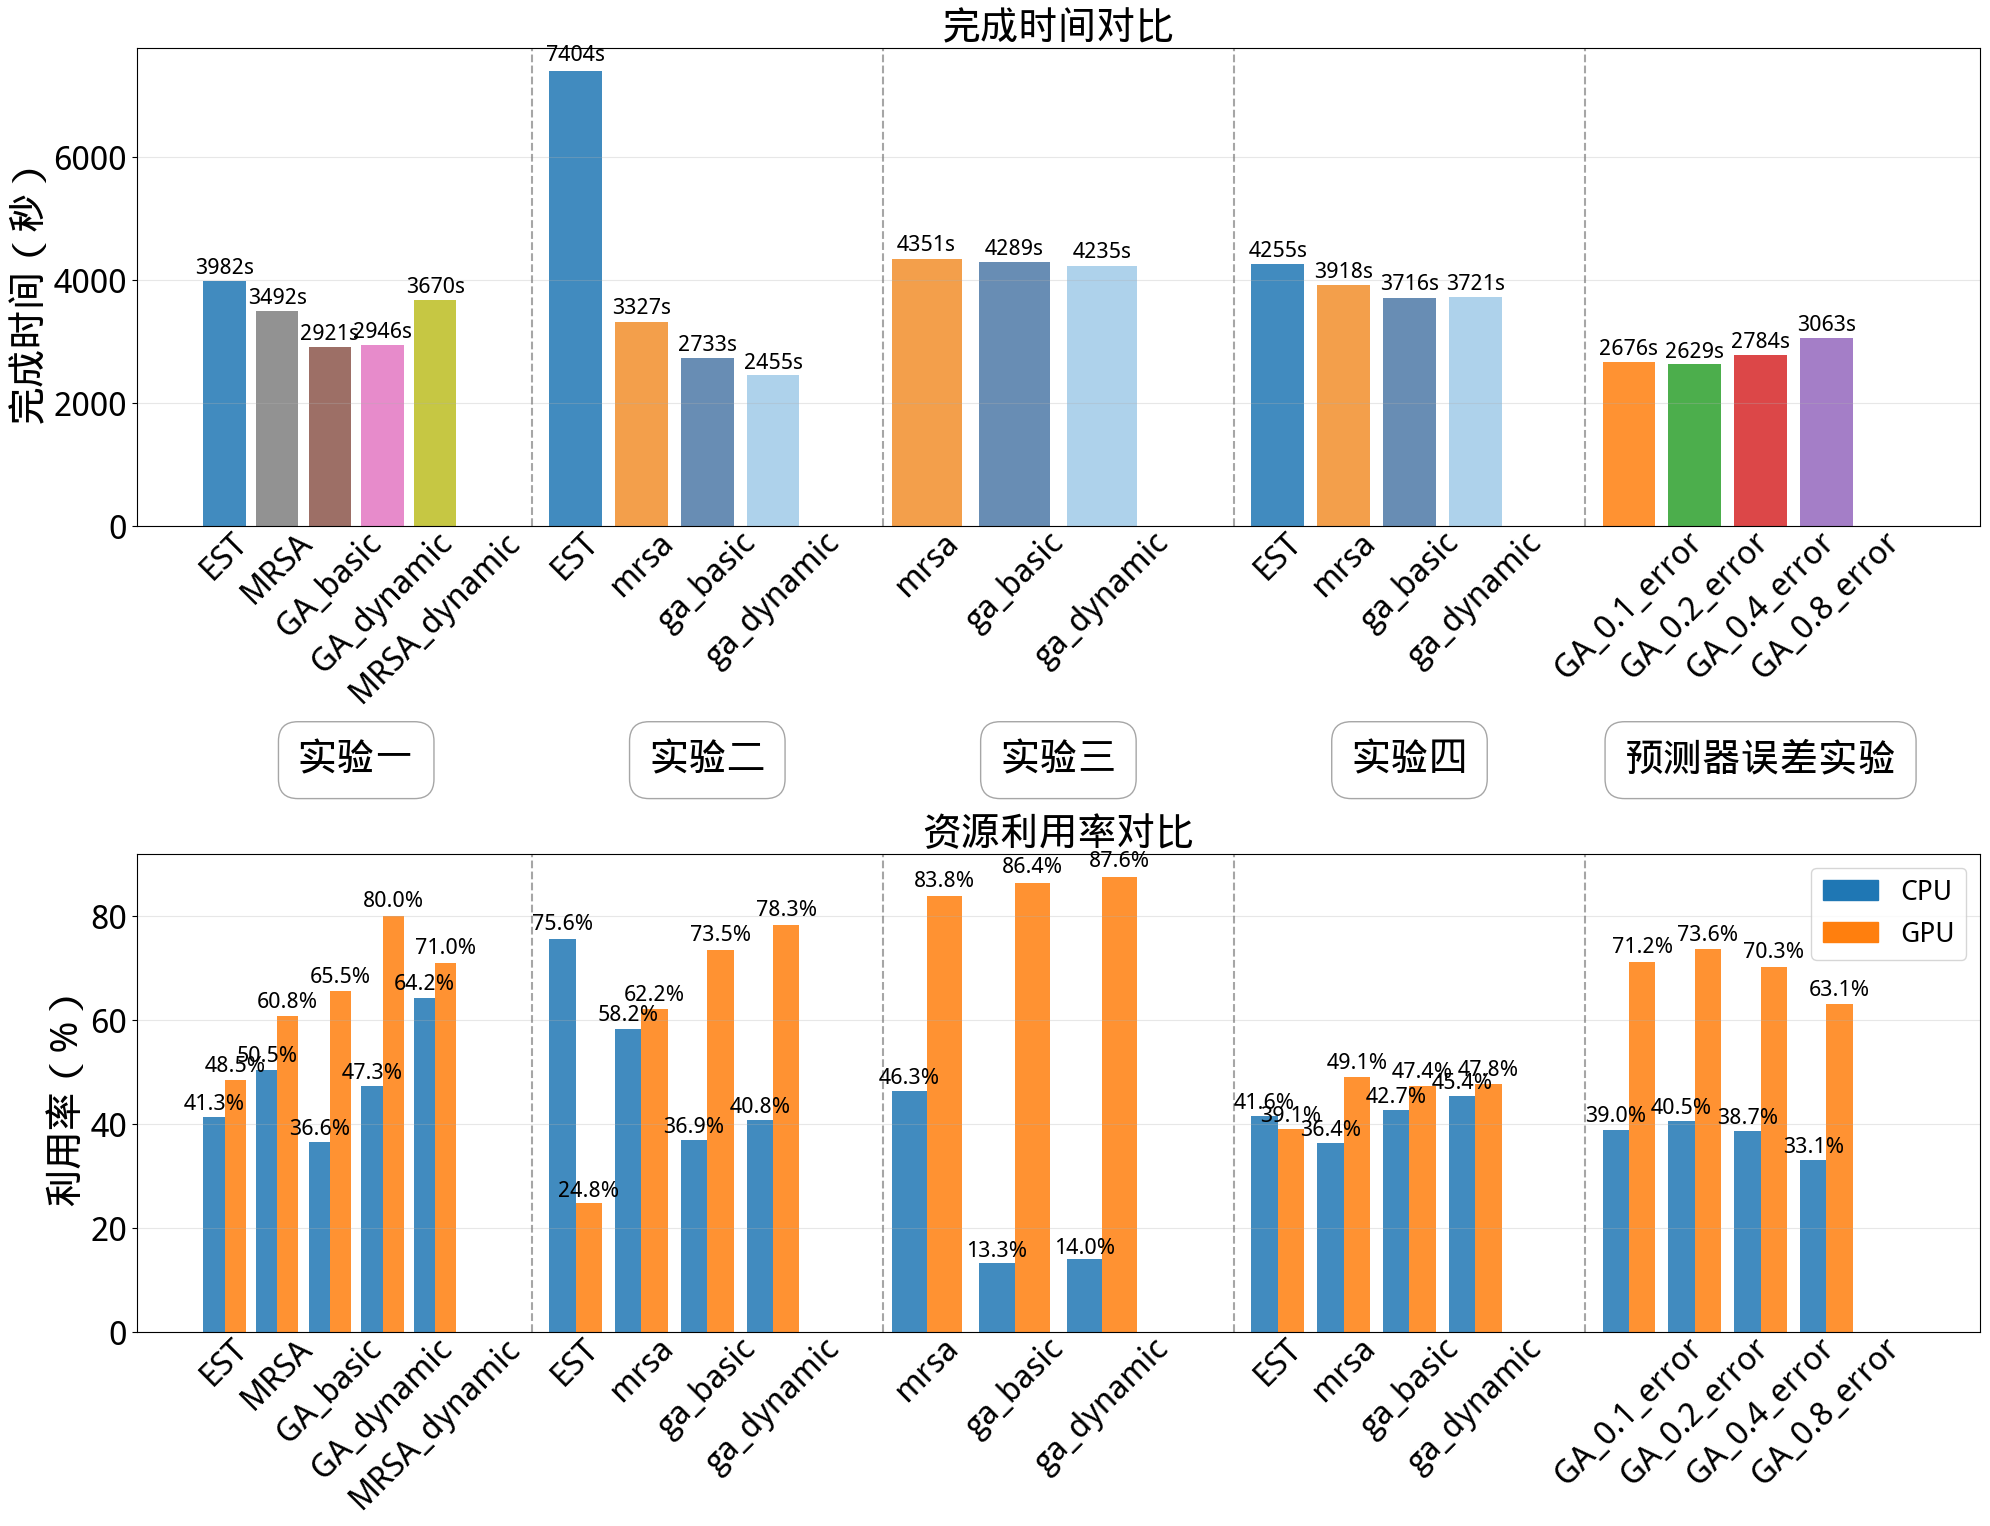

In [27]:
def plot_multi_experiment_comparison(all_experiment_data, title="五组实验对比"):
    """
    创建上下双面板布局，比较多组实验的完成时间和资源利用率。
    
    Args:
        all_experiment_data: 包含多组实验数据的字典，格式为：
                            {实验名称: {调度器名称: 数据}}
        title: 图表标题
    """
    # 准备数据
    experiment_groups = list(all_experiment_data.keys())
    all_schedulers = set()
    for group in experiment_groups:
        all_schedulers.update(all_experiment_data[group].keys())
    all_schedulers = sorted(list(all_schedulers))
    
    # 调度器颜色映射（保持一致性）
    scheduler_colors = {
        'ga_basic': '#4E79A7',      # 蓝色
        'ga_dynamic': '#A0CBE8',    # 浅蓝色
        'best_fit': '#59A14F',      # 绿色
        'mrsa': '#F28E2B',          # 橙色
        'mrsa_dynamic': '#FFBE7D',  # 浅橙色
        'ga_0.1_error': '#B07AA1',  # 紫色
        'ga_0.2_error': '#D4A6C8',  # 浅紫色
        'ga_0.4_error': '#9D7660',  # 棕色
        'ga_0.8_error': '#D7B5A6'   # 浅棕色
    }
    
    # 为未定义颜色的调度器创建默认颜色
    for i, scheduler in enumerate(all_schedulers):
        if scheduler not in scheduler_colors:
            scheduler_colors[scheduler] = f'C{i}'
    
    # 创建上下双面板布局
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 16))
    
    # 设置实验组位置参数
    n_groups = len(experiment_groups)
    group_width = 3  # 每组实验的宽度
    group_gap = 1    # 组间间隔
    total_plot_width = n_groups * (group_width + group_gap) - group_gap  # 总宽度
    
    # 计算最大柱状图数量（用于调整标签）
    max_bars_per_group = max(len(all_experiment_data[group]) for group in experiment_groups)
    
    y2_min, y2_max = ax2.get_ylim()
    
    # 绘制每个实验组
    for g_idx, experiment in enumerate(experiment_groups):
        scheduler_data = all_experiment_data[experiment]
        schedulers = list(scheduler_data.keys())
        
        # 计算当前实验组的起始位置
        group_start = g_idx * (group_width + group_gap)
        
        # 在第一个面板绘制完成时间
        # 找出最大完成时间，用于放置实验名称
        max_wct = max(scheduler_data[s]['wct'] for s in schedulers) * 1.05
        
        for s_idx, scheduler in enumerate(schedulers):
            x_pos = group_start + s_idx * (group_width / len(schedulers))
            wct = scheduler_data[scheduler]['wct']
            
            # 绘制柱状图
            bar = ax1.bar(x_pos, wct, width=group_width/len(schedulers)*0.8, 
                         color=scheduler_colors[scheduler], alpha=0.85)
            
            # 添加数值标签
            ax1.text(x_pos, wct * 1.01, f'{wct:.0f}s', ha='center', va='bottom', fontsize=16)
            
            # 在柱状图下方添加调度器名称
            if max_bars_per_group > 3:  # 如果每组有很多柱子，旋转标签
                ax1.text(x_pos, 0, scheduler, ha='center', va='top', fontsize=24, rotation=45)
            else:
                ax1.text(x_pos, 0, scheduler, ha='center', va='top', fontsize=24)
        
        # 在第二个面板绘制资源利用率
        # 找出最大利用率，用于放置实验名称
        max_util = max(max(scheduler_data[s]['cpu_util'], scheduler_data[s]['gpu_util']) for s in schedulers) * 1.05
        
        for s_idx, scheduler in enumerate(schedulers):
            x_pos = group_start + s_idx * (group_width / len(schedulers))
            width = (group_width / len(schedulers)) * 0.4
            
            cpu_util = scheduler_data[scheduler]['cpu_util']
            gpu_util = scheduler_data[scheduler]['gpu_util']
            
            # CPU柱状图
            cpu_bar = ax2.bar(x_pos - width/2, cpu_util, width=width, 
                             color='#1f77b4', alpha=0.85)
            ax2.text(x_pos - width/2, cpu_util * 1.01, f'{cpu_util:.1f}%', 
                    ha='center', va='bottom', fontsize=16)
            
            # GPU柱状图
            gpu_bar = ax2.bar(x_pos + width/2, gpu_util, width=width, 
                             color='#ff7f0e', alpha=0.85)
            ax2.text(x_pos + width/2, gpu_util * 1.01, f'{gpu_util:.1f}%', 
                    ha='center', va='bottom', fontsize=16)
            
            # 在柱状图下方添加调度器名称
            if max_bars_per_group > 3:  # 如果每组有很多柱子，旋转标签
                ax2.text(x_pos, 0, scheduler, ha='center', va='top', fontsize=24, rotation=45)
            else:
                ax2.text(x_pos, 0, scheduler, ha='center', va='top', fontsize=24)
        
        # 在每簇实验中间添加实验名称
        group_middle = group_start + group_width/2
        
        # 完成时间子图中添加实验名称
        # ax1.text(group_middle, max_wct * 1.1, experiment, 
        #         ha='center', va='center', fontsize=20, weight='bold',
        #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.5'))
        
        # 资源利用率子图中添加实验名称
        ax2.text(group_middle, 110, experiment, 
                ha='center', va='center', fontsize=28, weight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.5'))
        
        # 添加分隔虚线（最后一组除外）
        if g_idx < n_groups - 1:
            sep_pos = group_start + group_width + group_gap/2
            ax1.axvline(x=sep_pos, linestyle='--', color='gray', alpha=0.7)
            ax2.axvline(x=sep_pos, linestyle='--', color='gray', alpha=0.7)
    
    # 设置x轴范围，给两端留一些空间
    x_margin = group_gap
    ax1.set_xlim(-x_margin, total_plot_width + x_margin)
    ax2.set_xlim(-x_margin, total_plot_width + x_margin)
    
    # 设置y轴起点为0
    ax1.set_ylim(0, ax1.get_ylim()[1])
    ax2.set_ylim(0, ax2.get_ylim()[1])
    
    # 设置标题和标签
    ax1.set_title("完成时间对比", fontsize=28)
    ax1.set_ylabel("完成时间（秒）", fontsize=28)
    ax1.set_xticks([])  # 隐藏x轴刻度
    ax1.grid(axis='y', alpha=0.3)  # 添加水平网格线
    ax1.tick_params(axis='y', labelsize=24)
    
    ax2.set_title("资源利用率对比", fontsize=28)
    ax2.set_ylabel("利用率（%）", fontsize=28)
    ax2.set_xticks([])  # 隐藏x轴刻度
    ax2.grid(axis='y', alpha=0.3)  # 添加水平网格线
    ax2.tick_params(axis='y', labelsize=24)
    
    # 添加调度器图例
    handles = [plt.Rectangle((0,0),1,1, color=scheduler_colors[s]) 
              for s in all_schedulers if any(s in all_experiment_data[g] for g in experiment_groups)]
    labels = [s for s in all_schedulers if any(s in all_experiment_data[g] for g in experiment_groups)]
    # ncol_legend = len(labels)
    # ax1.legend(handles, labels, loc='upper right', fontsize=14, title="调度器", title_fontsize=20)
    
    # 添加CPU/GPU图例
    cpu_handle = plt.Rectangle((0,0),1,1, color='#1f77b4')
    gpu_handle = plt.Rectangle((0,0),1,1, color='#ff7f0e')
    ax2.legend([cpu_handle, gpu_handle], ['CPU', 'GPU'], loc='upper right', fontsize=20)
    
    # 设置总标题
    # fig.suptitle(title, fontsize=24, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # 为标题调整布局
    plt.savefig(f'{title.replace(" ", "_")}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# 使用示例：整合多组实验数据
def collect_experiment_data():
    """收集所有实验数据并整合"""
    all_experiment_data = {}
    
    # 定义所有实验配置
    experiment_configs = [
        {
            "name": "实验一", 
            "resources_path": Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250320_200632_ga_loadbalance_v1/resources.ini')),
            "scheduler_paths": {
                'EST': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_202640_fcfs_24core/dft-md-25Mar03-202722-6b6f06')),
                'MRSA': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_064208_mrsa_2_3492s/dft-md-25Mar21-064247-91d4cf')),
                'GA_basic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_004904_ga_basic_2912/dft-md-25Mar21-004943-05e295')),
                'GA_dynamic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250319_031644_test_v2_dynamic/dft-md-25Mar19-031753-d2ad2f')),
                'MRSA_dynamic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250324_013432_mrsa_dynamic_3670s/dft-md-25Mar24-013530-7a8325')),
            },
            "corrections": {
                'EST': {
                    'wct': 600,  # 增加600秒
                    'task_counts': {'run_calculator': 111, 'run_sampling': 111, 'train': 15}
                },
                'ga_dynamic': {'task_counts': {'run_calculator': 123}}
            }
        },
        {
            "name": "实验二",
            "resources_path": Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/resources.ini')),
            "scheduler_paths": {
                'EST': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/dft-md-25Mar31-010700-2d4692')),
                'mrsa': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250328_032817_mrsa3_2gpu_3416/dft-md-25Mar28-032901-55b3ea')),
                'ga_basic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250401_181152_ga_basic_2gpu_2733/dft-md-25Apr01-181247-968e04')),
                'ga_dynamic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_224203_ga_dynamic_2gpu_2455/dft-md-25Mar30-224253-3f6843')),
            }
        },
        {
            "name": "实验三",
            "resources_path": Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_190805_mrsa4_4315_1gpu/resources.ini')),
            "scheduler_paths": {
                'mrsa': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_190805_mrsa4_4315_1gpu/dft-md-25Mar30-190843-13a716')),
                'ga_basic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_234204_ga_basic_1gpu_4295/dft-md-25Mar30-234253-1d99f1')),
                'ga_dynamic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_233852_ga_dynamic_1gpu_4235/dft-md-25Mar30-233941-6e459b')),
            }
        },
        {
            "name": "实验四",
            "resources_path": Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250331_164425_fcfs_4255/resources.ini')),
            "scheduler_paths": {
                'EST': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250331_164425_fcfs_4255/dft-md-25Mar31-164521-c88a83')),
                'mrsa': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250331_182116__mrsa_3918/dft-md-25Mar31-182209-dc242f')),
                'ga_basic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250402_154156_ga_basic_3716/dft-md-25Apr02-154309-fa04cb')),
                'ga_dynamic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test3_20node/20250402_183522_ga_dynamic_3721/dft-md-25Apr02-183628-a4fefd')),
            }
        },
        {
            "name": "预测器误差实验",
            "resources_path": Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250331_010611_fcfs_144core_2gpu_7404/resources.ini')),
            "scheduler_paths": {
                'GA_0.1_error': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250401_223518_10%_error_2676/dft-md-25Apr01-223609-d4232b')),
                'GA_0.2_error': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250402_002228_20%_error_2629/dft-md-25Apr02-002322-f6bb7c')),
                'GA_0.4_error': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250402_023524_40%_error_2748/dft-md-25Apr02-023614-879926')),
                'GA_0.8_error': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test4_predict_error/20250402_040748_80%_error_3063/dft-md-25Apr02-040837-762e05')),
            }
        }
    ]
    
    # 收集每个实验配置的数据
    for config in experiment_configs:
        experiment_name = config["name"]
        experiment_data = {}
        
        for scheduler_type, path in config["scheduler_paths"].items():
            results = load_results(path, task_type)
            report = generate_workflow_report(results, resources_path=config["resources_path"])
            
            # 计算资源分配均值
            avg_cpu_alloc = {}
            avg_gpu_alloc = {}
            for task in report['task_counts']:
                # CPU分配均值
                cpu_dist = report['resource_distribution'][task]['cpu']
                total = sum(cpu_dist.values())
                avg_cpu = sum(k*v for k,v in cpu_dist.items())/total if total > 0 else 0
                
                # GPU分配均值
                gpu_dist = report['resource_distribution'][task]['gpu']
                total = sum(gpu_dist.values())
                avg_gpu = sum(k*v for k,v in gpu_dist.items())/total if total > 0 else 0
                
                avg_cpu_alloc[task] = avg_cpu
                avg_gpu_alloc[task] = avg_gpu
            
            # 存储数据
            experiment_data[scheduler_type] = {
                'wct': report['wct'],
                'cpu_util': report['cluster_utilization']['cpu_utilization']*100,
                'gpu_util': report['cluster_utilization']['gpu_utilization']*100,
                'task_counts': report['task_counts'],
                'avg_cpu_alloc': avg_cpu_alloc,
                'avg_gpu_alloc': avg_gpu_alloc,
                'task_stats': report['task_stats'],
                'resource_distribution': report['resource_distribution']
            }
        
        # 应用数据修正（如果有）
        if "corrections" in config:
            for scheduler, corrections in config["corrections"].items():
                if scheduler in experiment_data:
                    for key, value in corrections.items():
                        if key == 'wct':
                            experiment_data[scheduler][key] += value
                        elif isinstance(value, dict):
                            # 对嵌套字典进行更新
                            experiment_data[scheduler][key].update(value)
                        else:
                            experiment_data[scheduler][key] = value
        
        # 添加到总数据集
        all_experiment_data[experiment_name] = experiment_data
    
    return all_experiment_data

# 执行数据收集和可视化
all_experiment_data = collect_experiment_data()
plot_multi_experiment_comparison(all_experiment_data, "五组实验调度器性能对比")

Scheduler type: GA_basic


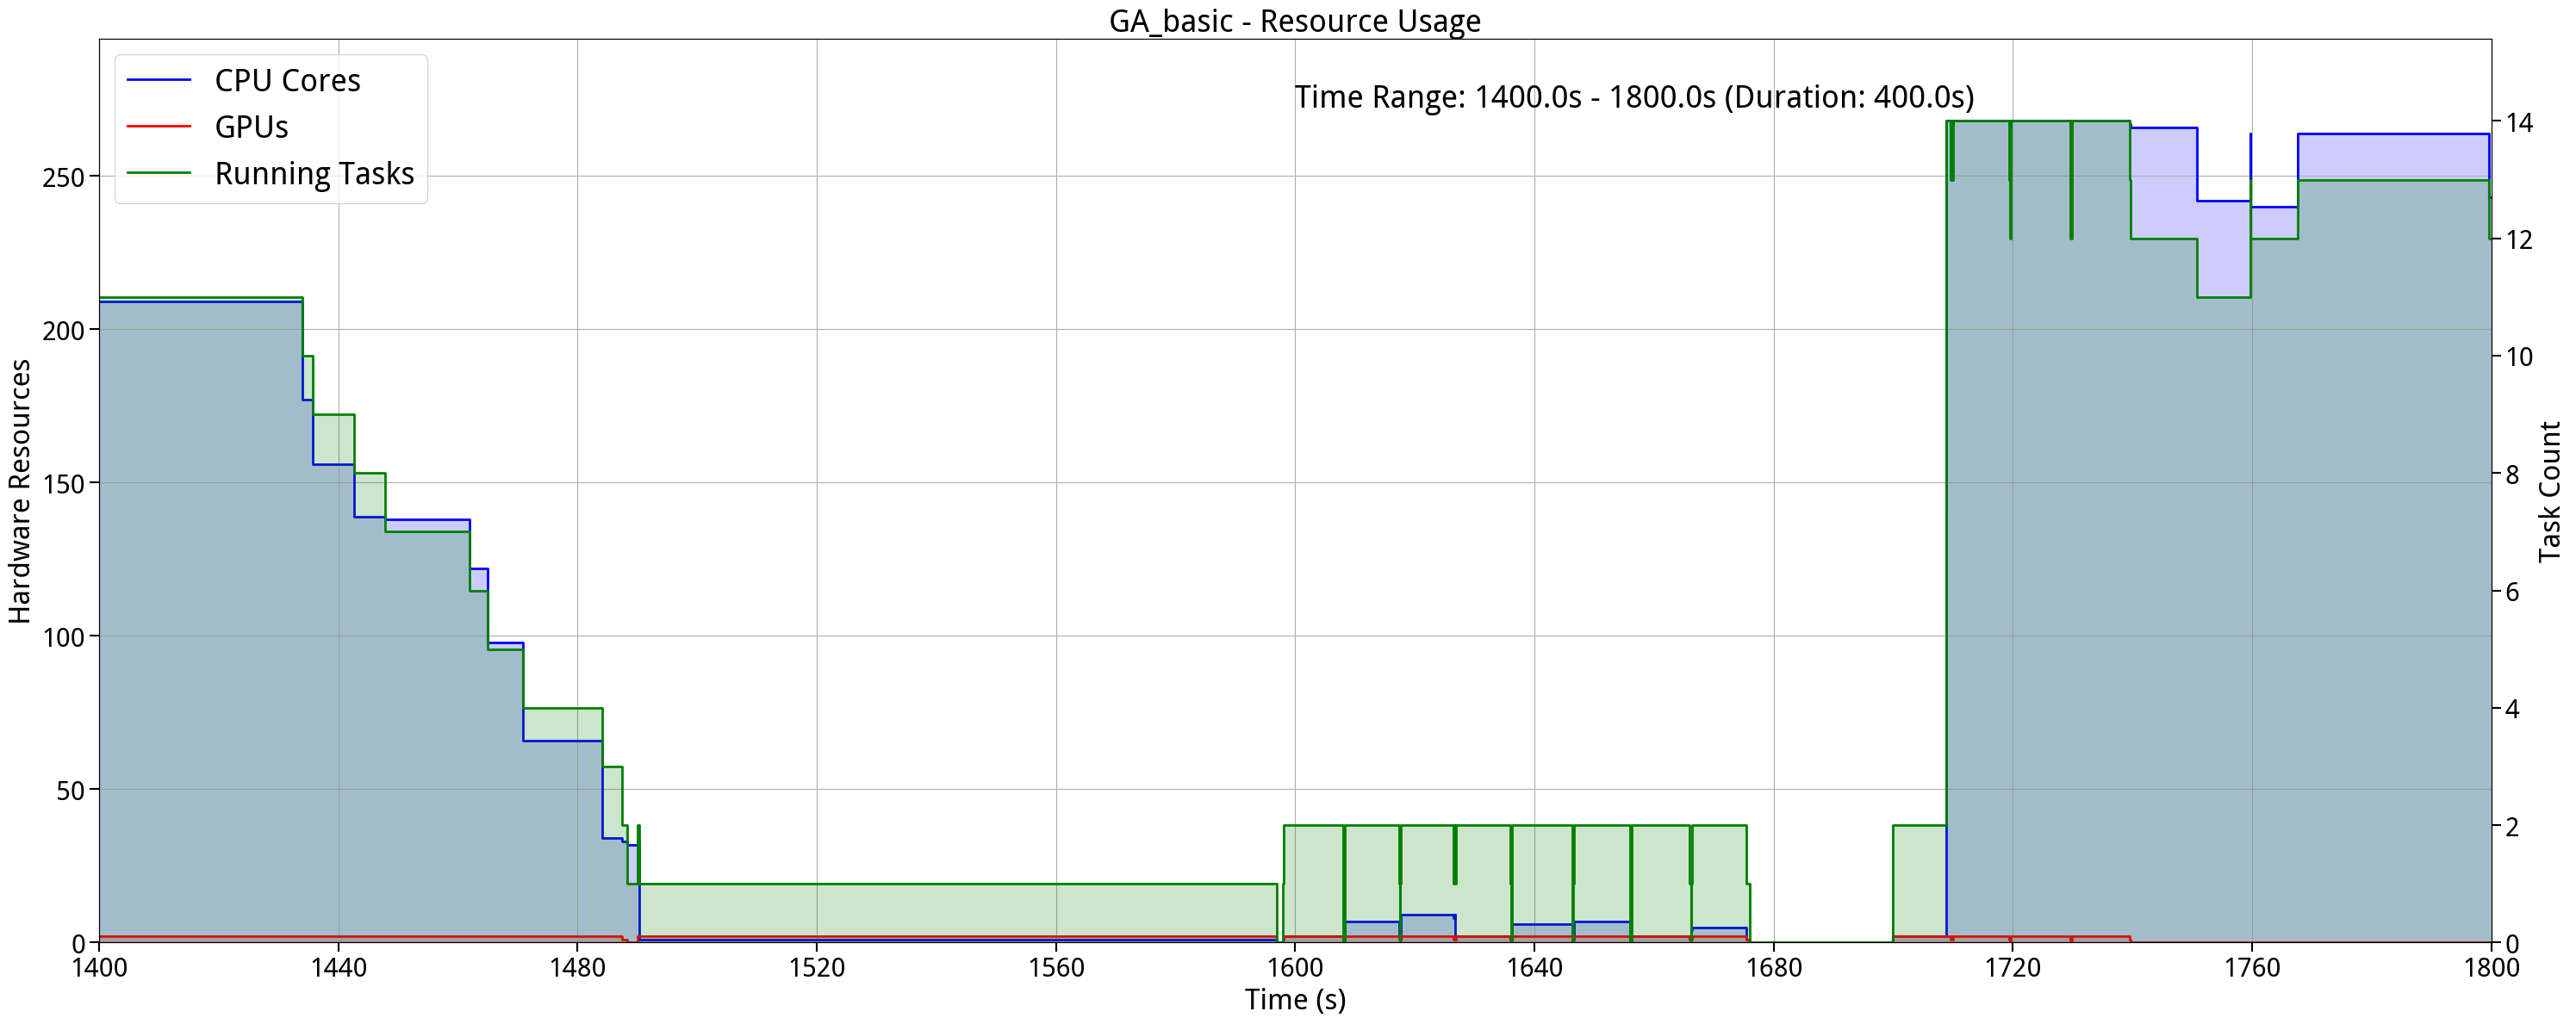

Scheduler type: GA_dynamic


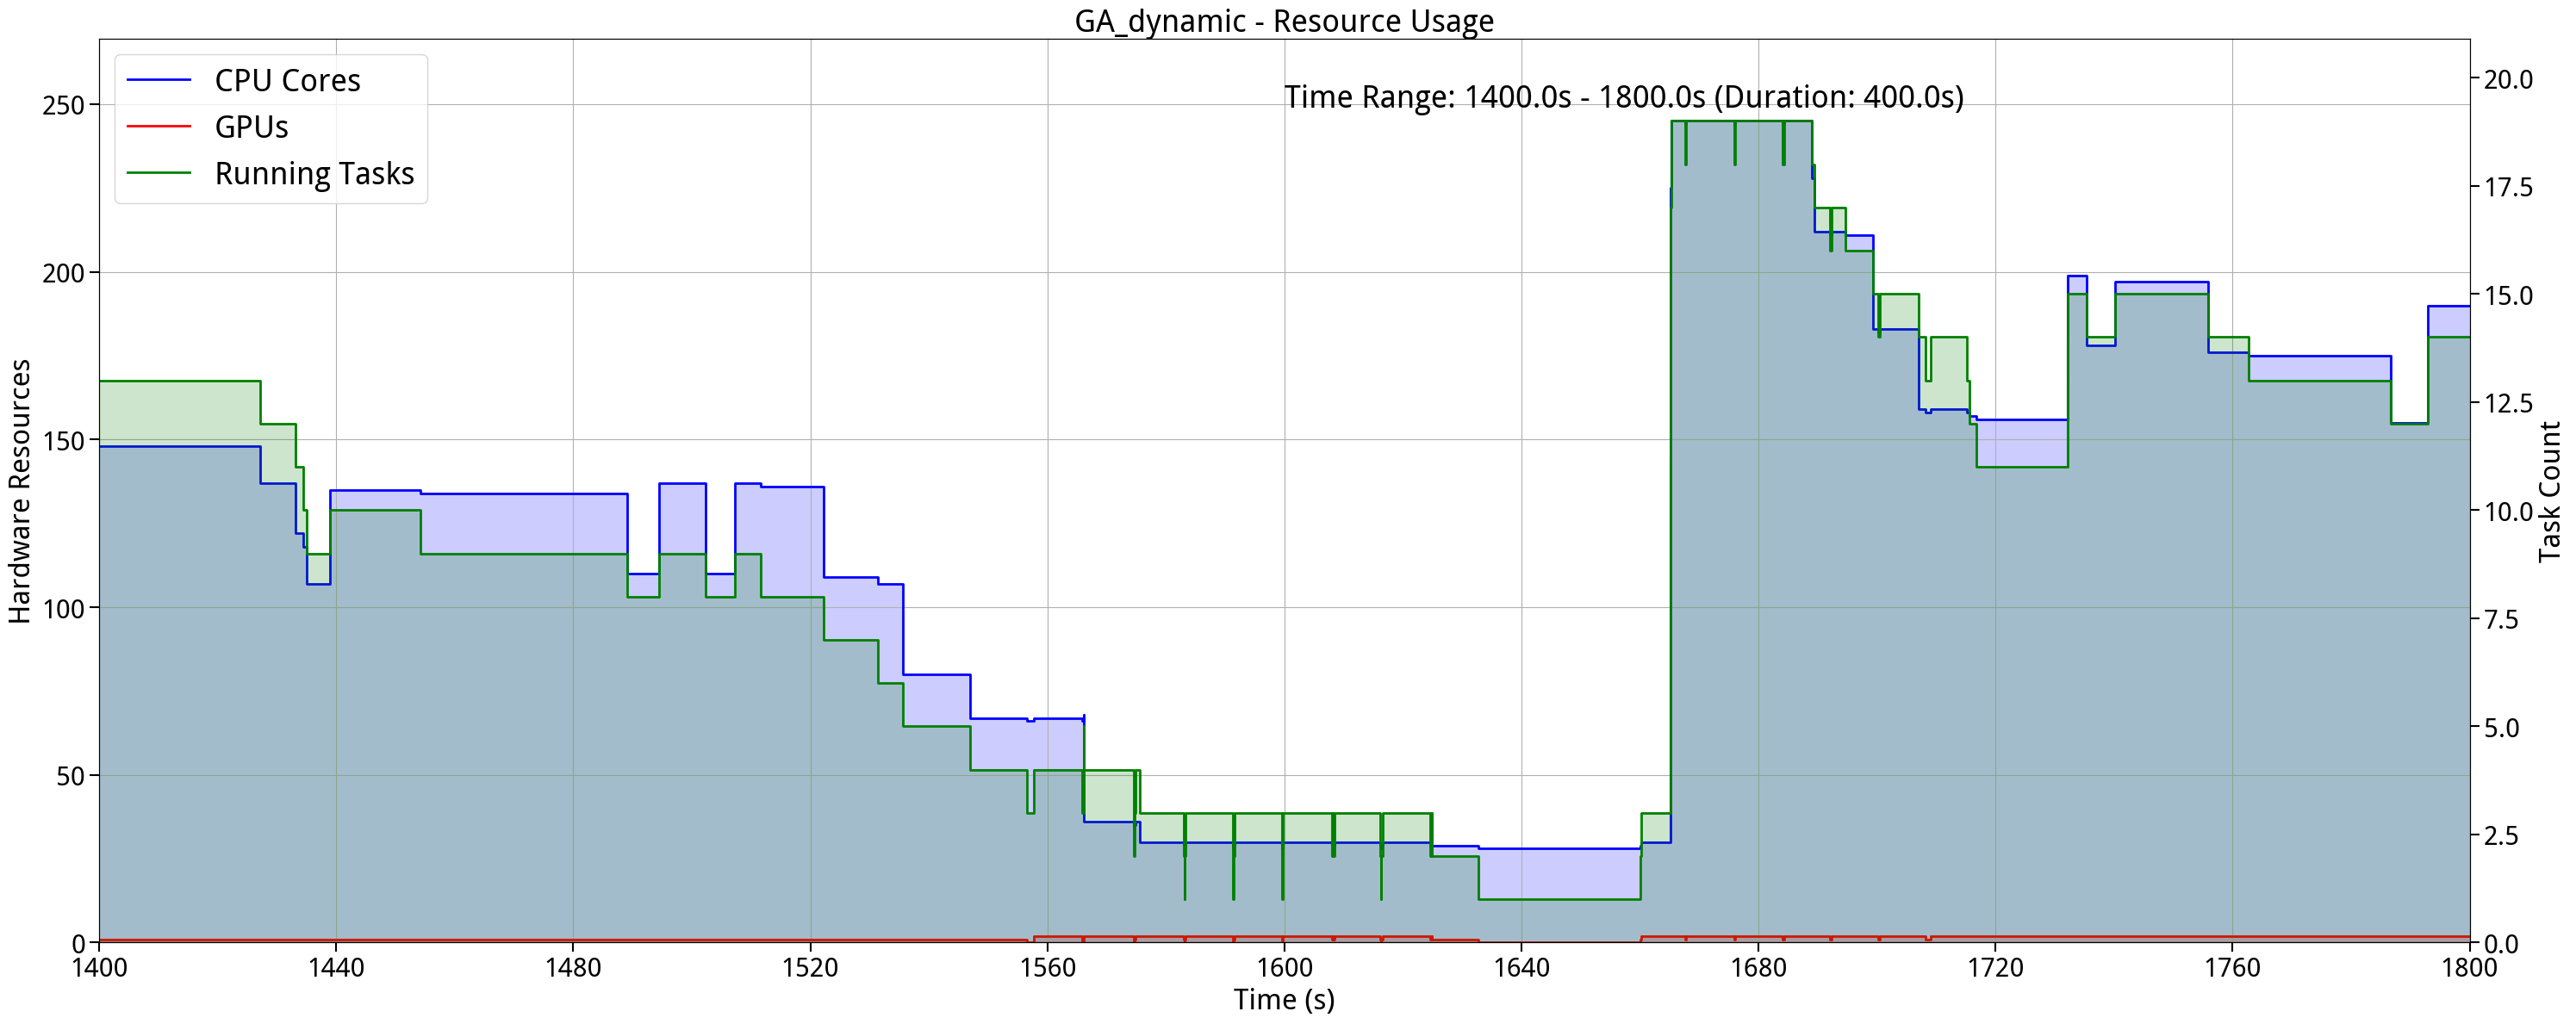

Scheduler type: EST


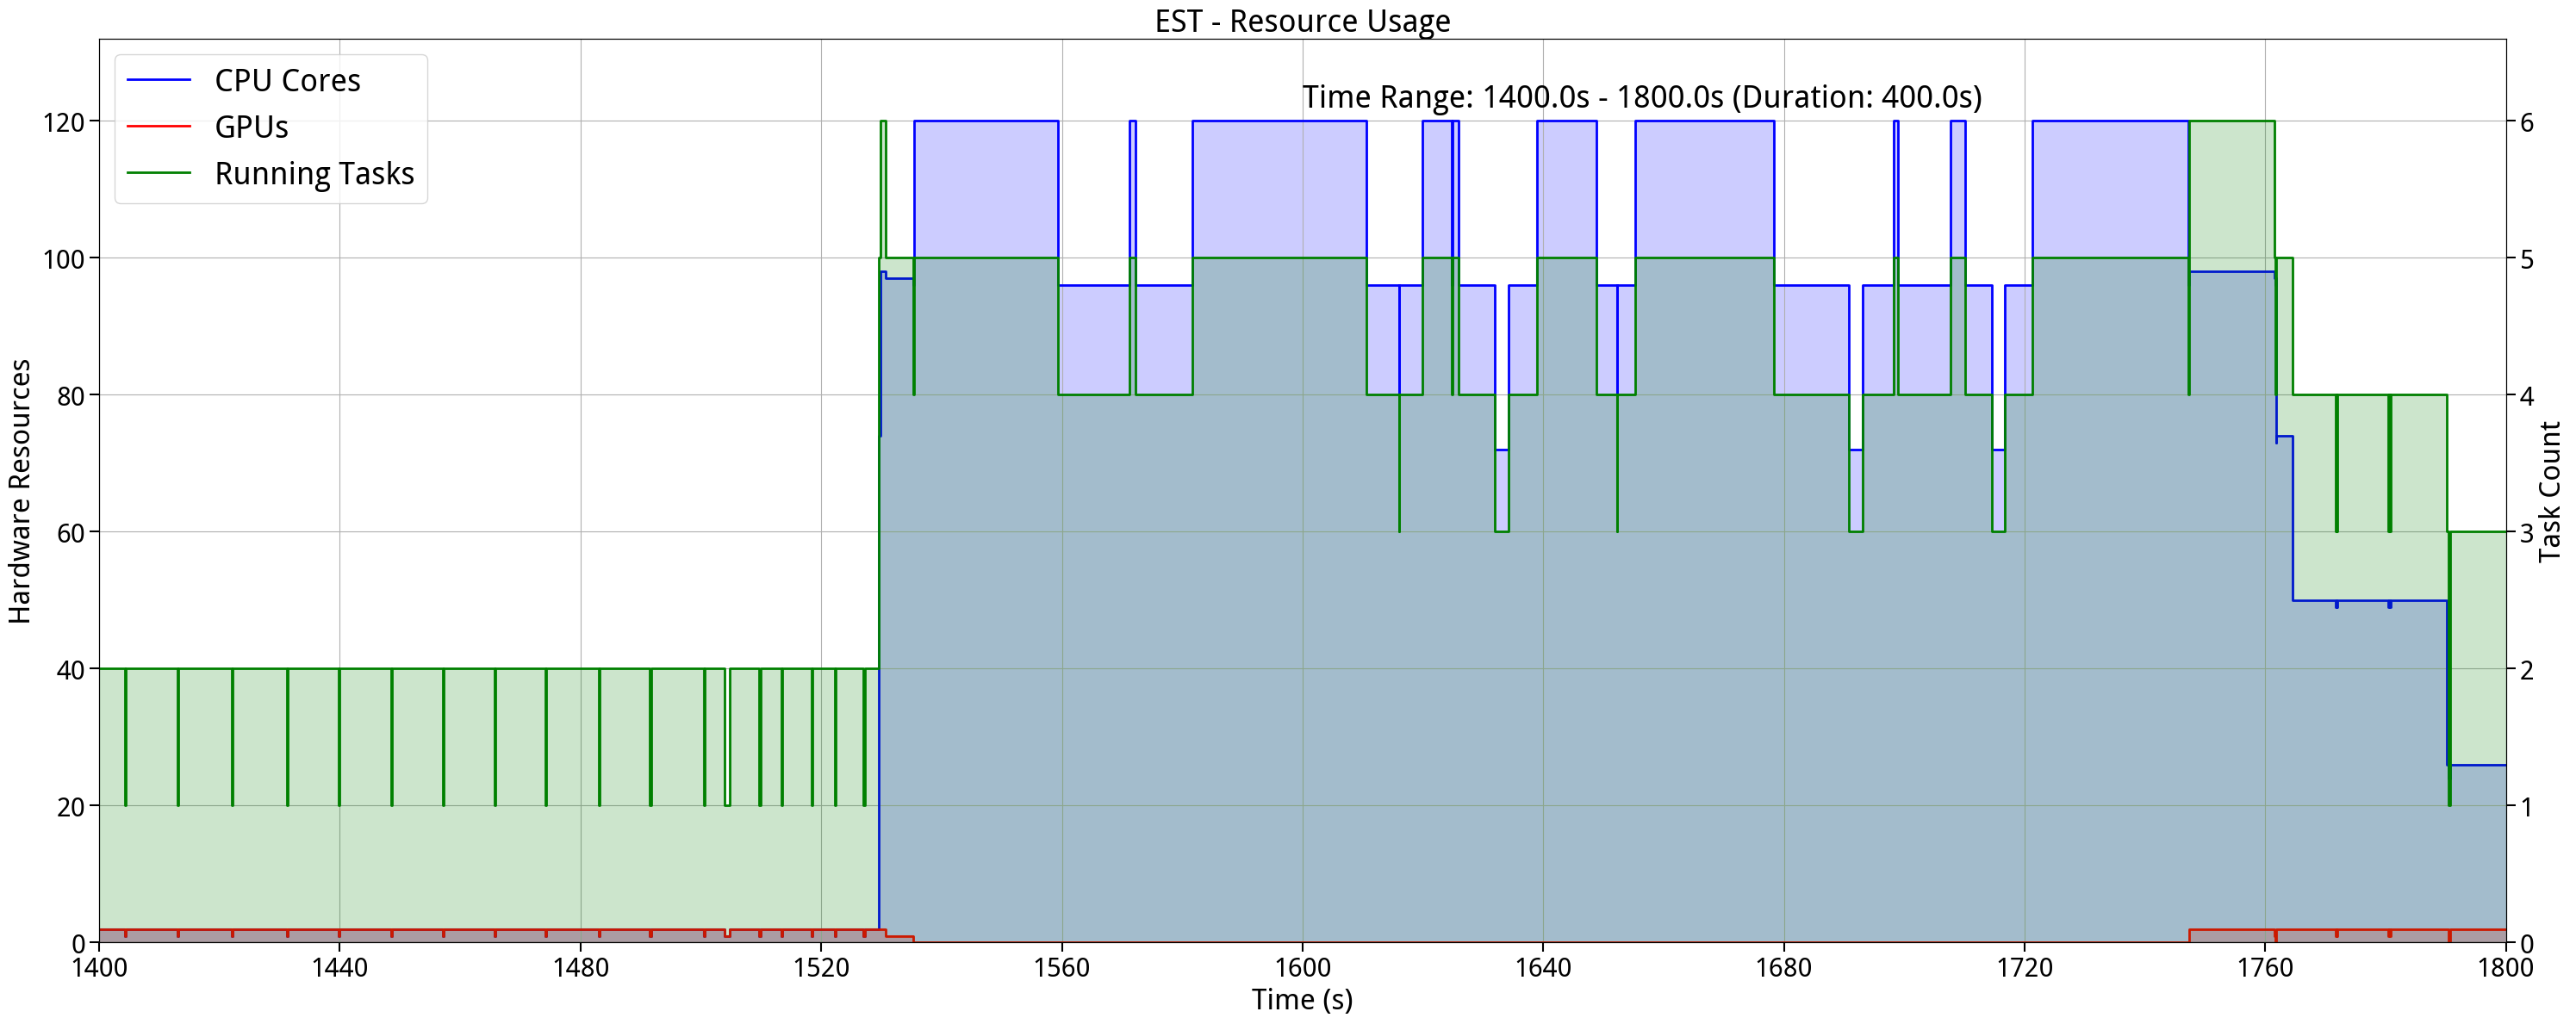

Scheduler type: MRSA


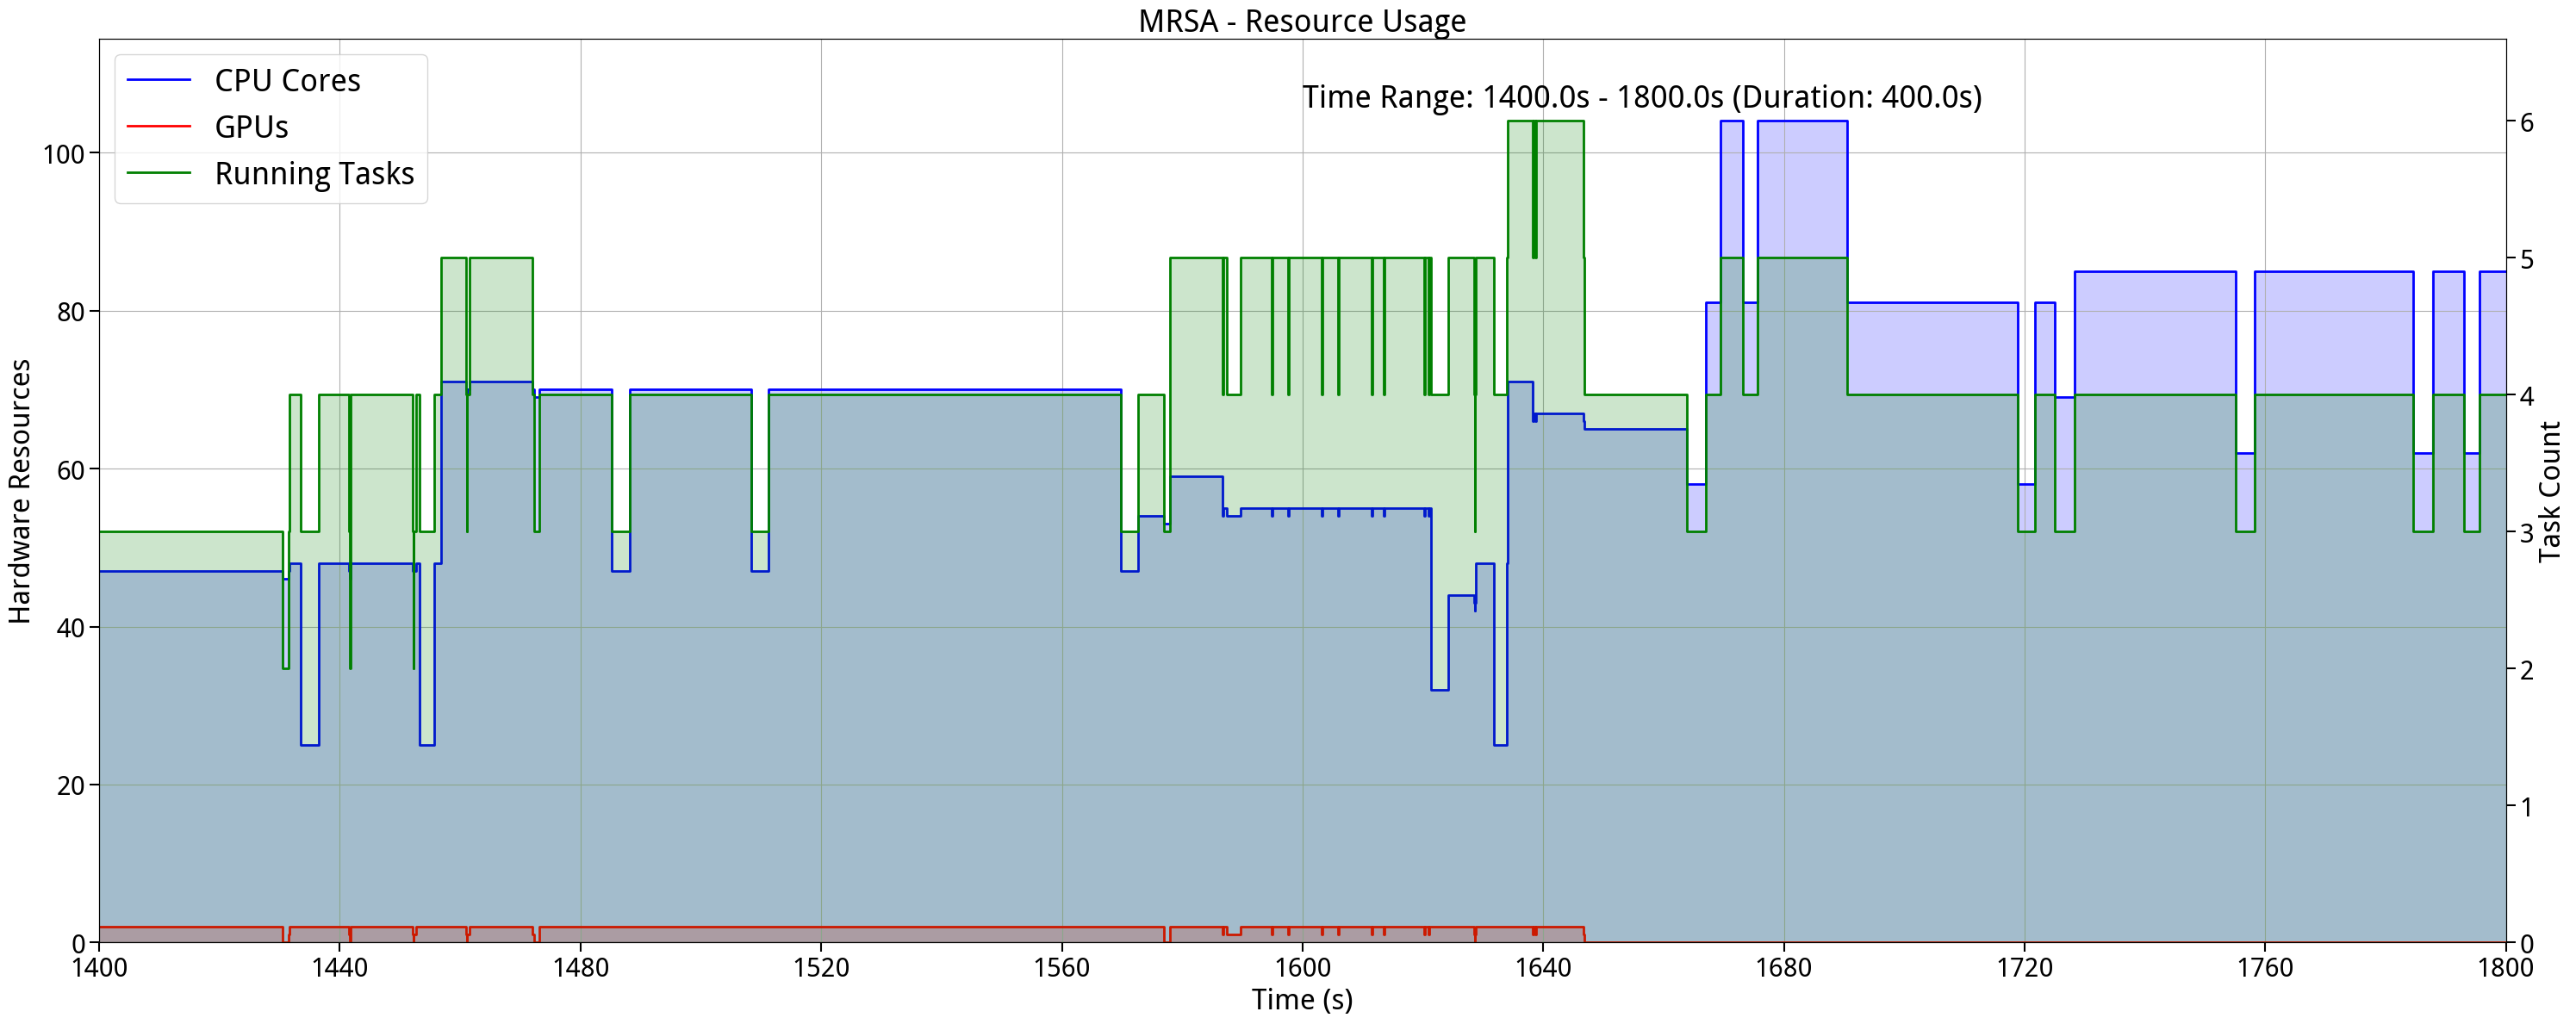

Scheduler type: MRSA_dynamic


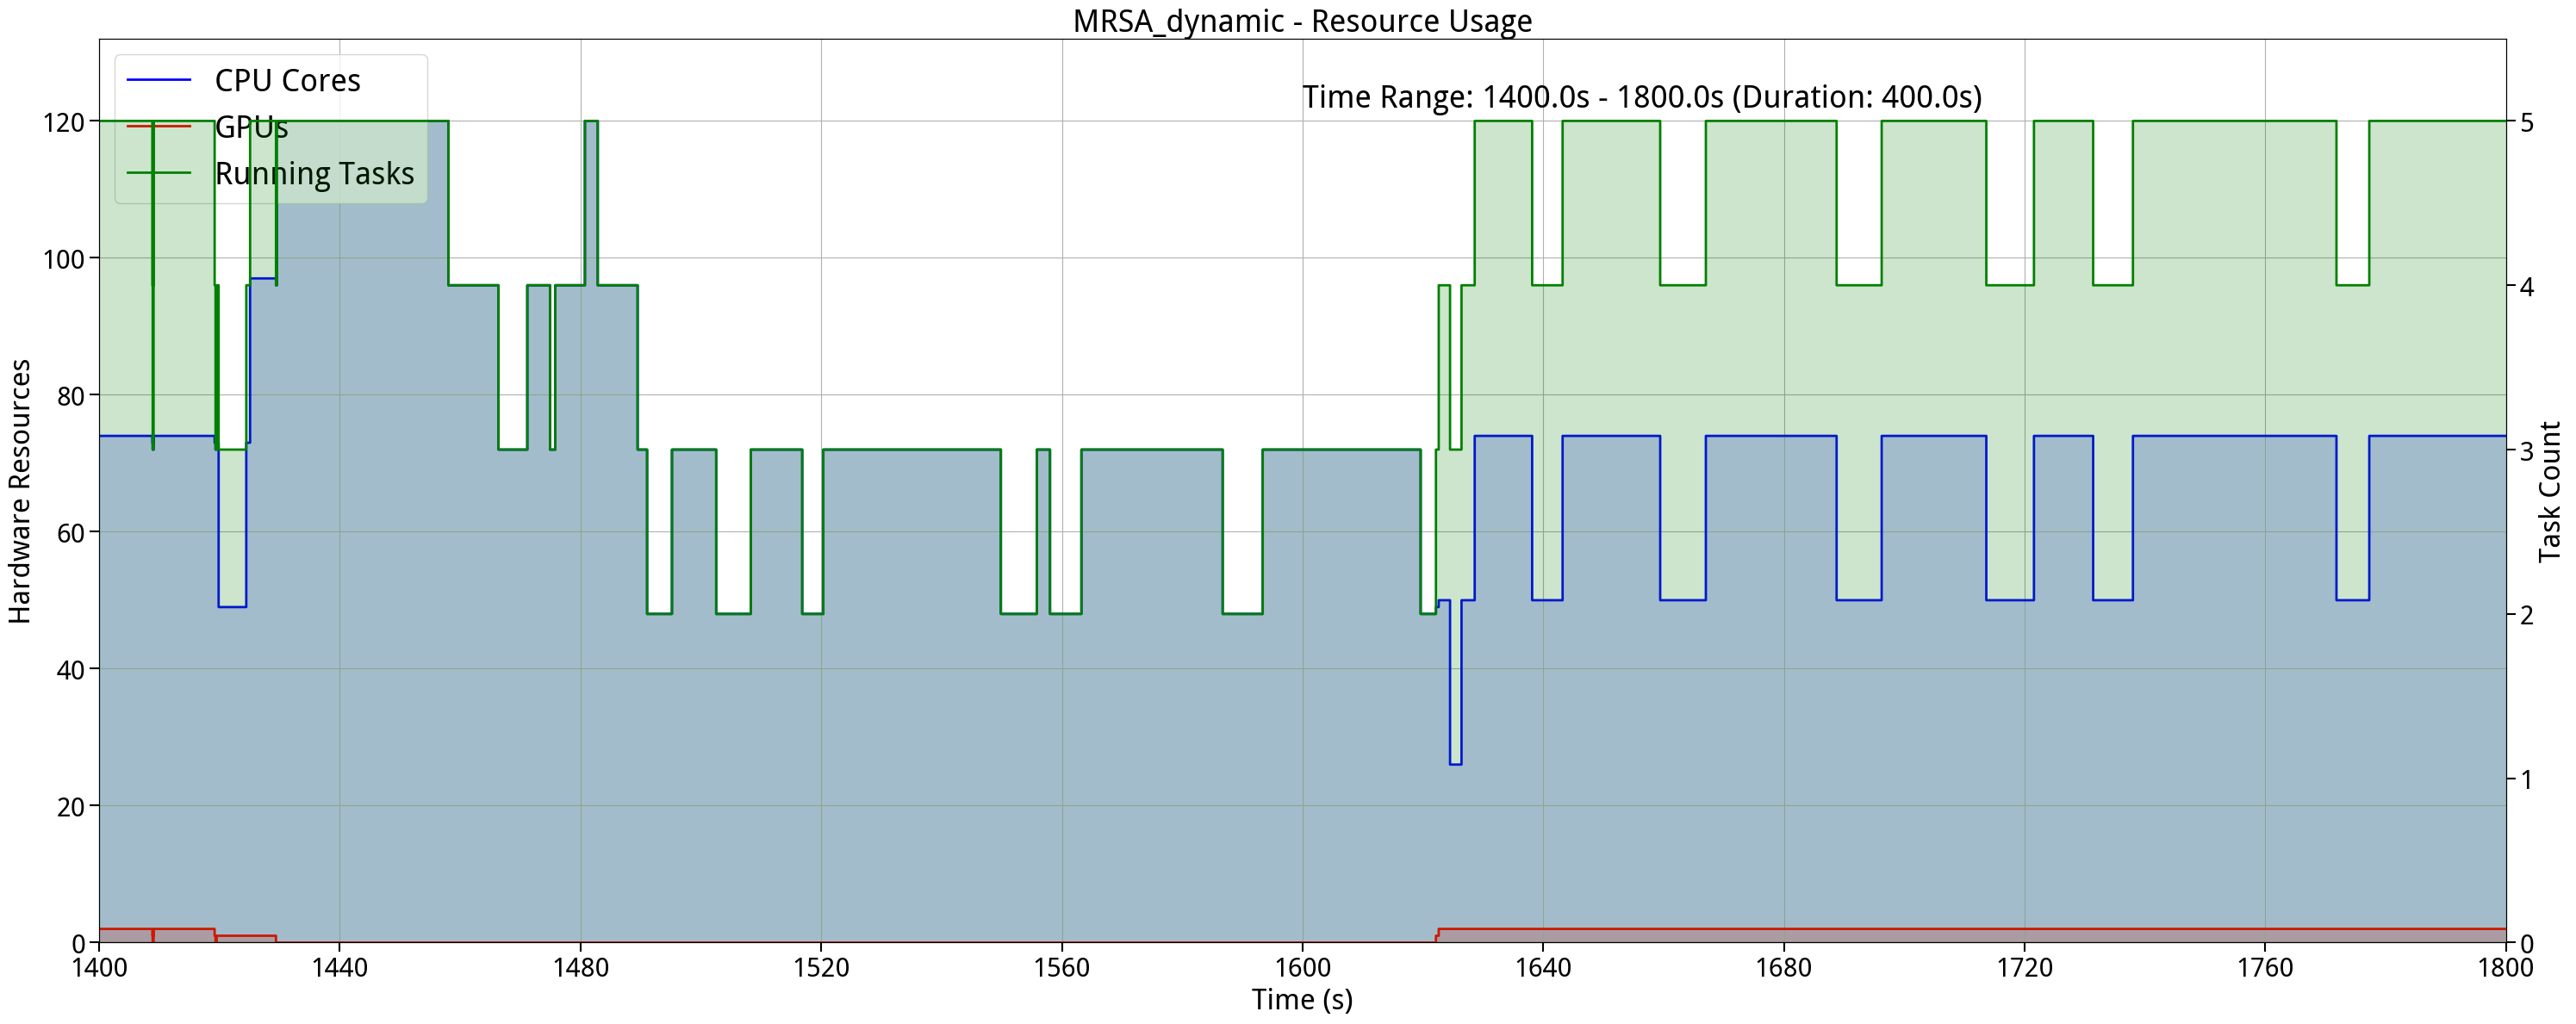

In [11]:
task_type = ['sampling-results', 'training-results', 'simulation-results']

resources_path=Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250320_200632_ga_loadbalance_v1/resources.ini'))
scheduler_paths = {
'GA_basic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250401_181152_ga_basic_2gpu_2733/dft-md-25Apr01-181247-968e04')),
'GA_dynamic': Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250330_224203_ga_dynamic_2gpu_2455/dft-md-25Mar30-224253-3f6843')),
'EST' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250303_202640_fcfs_24core/dft-md-25Mar03-202722-6b6f06')),
'MRSA' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_064208_mrsa_2_3492s/dft-md-25Mar21-064247-91d4cf')),
'MRSA_dynamic' : Path(os.path.expanduser('~/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250323_170502_mrsa_dynamic_3411/dft-md-25Mar23-170614-d1db82')),
}


for scheduler_type, path in scheduler_paths.items():
    print(f"Scheduler type: {scheduler_type}")
    results = load_results(path, task_type)

    report = generate_workflow_report(
    results, 
    resources_path=resources_path
    )
    # # 计算节点统计
    # node_stats = calculate_node_stats(results, path.parent / "resources.ini")
    # print("节点资源统计:")
    # print(node_stats)

    # # 计算任务统计
    # task_stats = calculate_task_stats(results)
    # print("\n任务资源统计:")
    # print(task_stats)

    # 计算吞吐量
    # throughput = calculate_throughput(results)
    # print("\n吞吐量统计:")
    # print(throughput)
    # print("===WCT===")
    # print(f"workflow completion time: {report['wct']}")
    
    # print("=== Cluster Utilization ===")
    # print(f"CPU: {report['cluster_utilization']['cpu_utilization']*100:.1f}%")
    # print(f"GPU: {report['cluster_utilization']['gpu_utilization']*100:.1f}%")
    
    # print("\n=== Task Counts ===")
    # for task, count in report['task_counts'].items():
    #     print(f"{task}: {count} tasks")
    
    # print("\n=== Resource Distribution ===")
    # for task, dist in report['resource_distribution'].items():
    #     print(f"{task} CPU分配: {dict(dist['cpu'])}")
    #     print(f"{task} GPU分配: {dict(dist['gpu'])}")
    
    # print("\n=== Task Statistics ===")
    # for task, stats in report['task_stats'].items():
    #     print(f"{task}:")
    #     print(f"  平均CPU面积: {stats['avg_cpu_area']:.1f} core·s")
    #     print(f"  平均GPU面积: {stats['avg_gpu_area']:.1f} gpu·s")
        
    plot_total_resource_usage(results, task_color,title=scheduler_type, start_time=1400, end_time=1800)

In [ ]:
def plot_total_resource_usage(results: pd.DataFrame, task_color: dict, title: str = "workflow analysis",
                              ax=None, global_start_time=None, global_end_time=None):
    """绘制单个调度器的资源利用率图（支持子图模式）"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 8))
    else:
        fig = ax.figure

    # 计算全局时间范围
    if global_start_time is None:
        global_start_time = results['time_created'].min()
    if global_end_time is None:
        global_end_time = results['time_result_received'].max()
    wct = int(global_end_time - global_start_time)
    
    # 收集所有任务事件
    events = []
    for _, row in results.iterrows():
        task_start = row['time_compute_started'] - global_start_time
        task_end = task_start + row['time_running']
        
        cpu = row['resources'].get('cpu', 0)
        gpu_info = row['resources'].get('gpu', [])
        gpu = len(gpu_info) if isinstance(gpu_info, list) else int(gpu_info)
        
        events.append((task_start, cpu, gpu, 1, 'start'))
        events.append((task_end, cpu, gpu, 1, 'end'))
    
    # 排序事件
    events.sort(key=lambda x: x[0])
    
    # 计算累积资源使用
    time_points, cpu_usage, gpu_usage, task_count = [0], [0], [0], [0]
    current_cpu = current_gpu = current_tasks = 0

    for time, cpu, gpu, delta, event_type in events:
        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)

        if event_type == 'start':
            current_cpu += cpu
            current_gpu += gpu
            current_tasks += delta
        else:
            current_cpu -= cpu
            current_gpu -= gpu
            current_tasks -= delta

        time_points.append(time)
        cpu_usage.append(current_cpu)
        gpu_usage.append(current_gpu)
        task_count.append(current_tasks)

    # 添加最终时间点
    time_points.append(wct)
    cpu_usage.extend([current_cpu]*2)
    gpu_usage.extend([current_gpu]*2)
    task_count.extend([current_tasks]*2)

    # 绘制资源曲线
    ax.plot(time_points, cpu_usage, 'b-', linewidth=2, label='CPU Cores')
    ax.fill_between(time_points, cpu_usage, alpha=0.2, color='blue')
    
    if max(gpu_usage) > 0:
        ax.plot(time_points, gpu_usage, 'r-', linewidth=2, label='GPUs')
        ax.fill_between(time_points, gpu_usage, alpha=0.2, color='red')

    # 绘制任务数曲线（次坐标轴）
    ax2 = ax.twinx()
    ax2.plot(time_points, task_count, 'g-', linewidth=2, label='Running Tasks')
    ax2.fill_between(time_points, task_count, alpha=0.2, color='green')

    # 设置坐标轴属性
    ax.set_xlim(0, wct)
    ax.set_ylabel('Hardware Resources', fontsize=14)
    ax2.set_ylabel('Task Count', fontsize=14)
    ax.set_title(title, fontsize=16)
    
    # 统一图例
    lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', fontsize=10)

    return ax


def compare_schedulers(results_list: list, scheduler_names: list, task_color: dict, 
                       figsize=(20, 12), title="Schedulers Comparison"):
    """对比多个调度器的资源利用率"""
    # 计算全局时间范围
    all_starts = [res['time_created'].min() for res in results_list]
    all_ends = [res['time_result_received'].max() for res in results_list]
    global_start = min(all_starts)
    global_end = max(all_ends)
    total_time = int(global_end - global_start)
    
    # 创建子图
    n = len(results_list)
    fig, axs = plt.subplots(n, 1, figsize=figsize, sharex=True)
    if n == 1:
        axs = [axs]  # 确保单个子图时也能迭代
    
    # 绘制每个调度器的子图
    for idx, (results, name, ax) in enumerate(zip(results_list, scheduler_names, axs)):
        plot_total_resource_usage(
            results, task_color, 
            title=name,
            ax=ax,
            global_start_time=global_start,
            global_end_time=global_end
        )
        
        # 仅最下方子图显示x轴标签
        if idx != n-1:
            ax.set_xlabel('')
    
    # 添加全局标签
    fig.suptitle(title, fontsize=20, y=1.02)
    fig.text(0.5, 0.01, 'Time (s)', ha='center', fontsize=16)
    plt.tight_layout()
    plt.show()

In [35]:
results = load_results(Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820'), task_type)
plot_total_resource_usage(results, task_color,title='GA Basic')

AssertionError: Could not find /work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820/sampling-results.json

In [ ]:
results = load_results(Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820'), task_type)
plot_total_resource_usage(results, task_color,title='GA Basic')

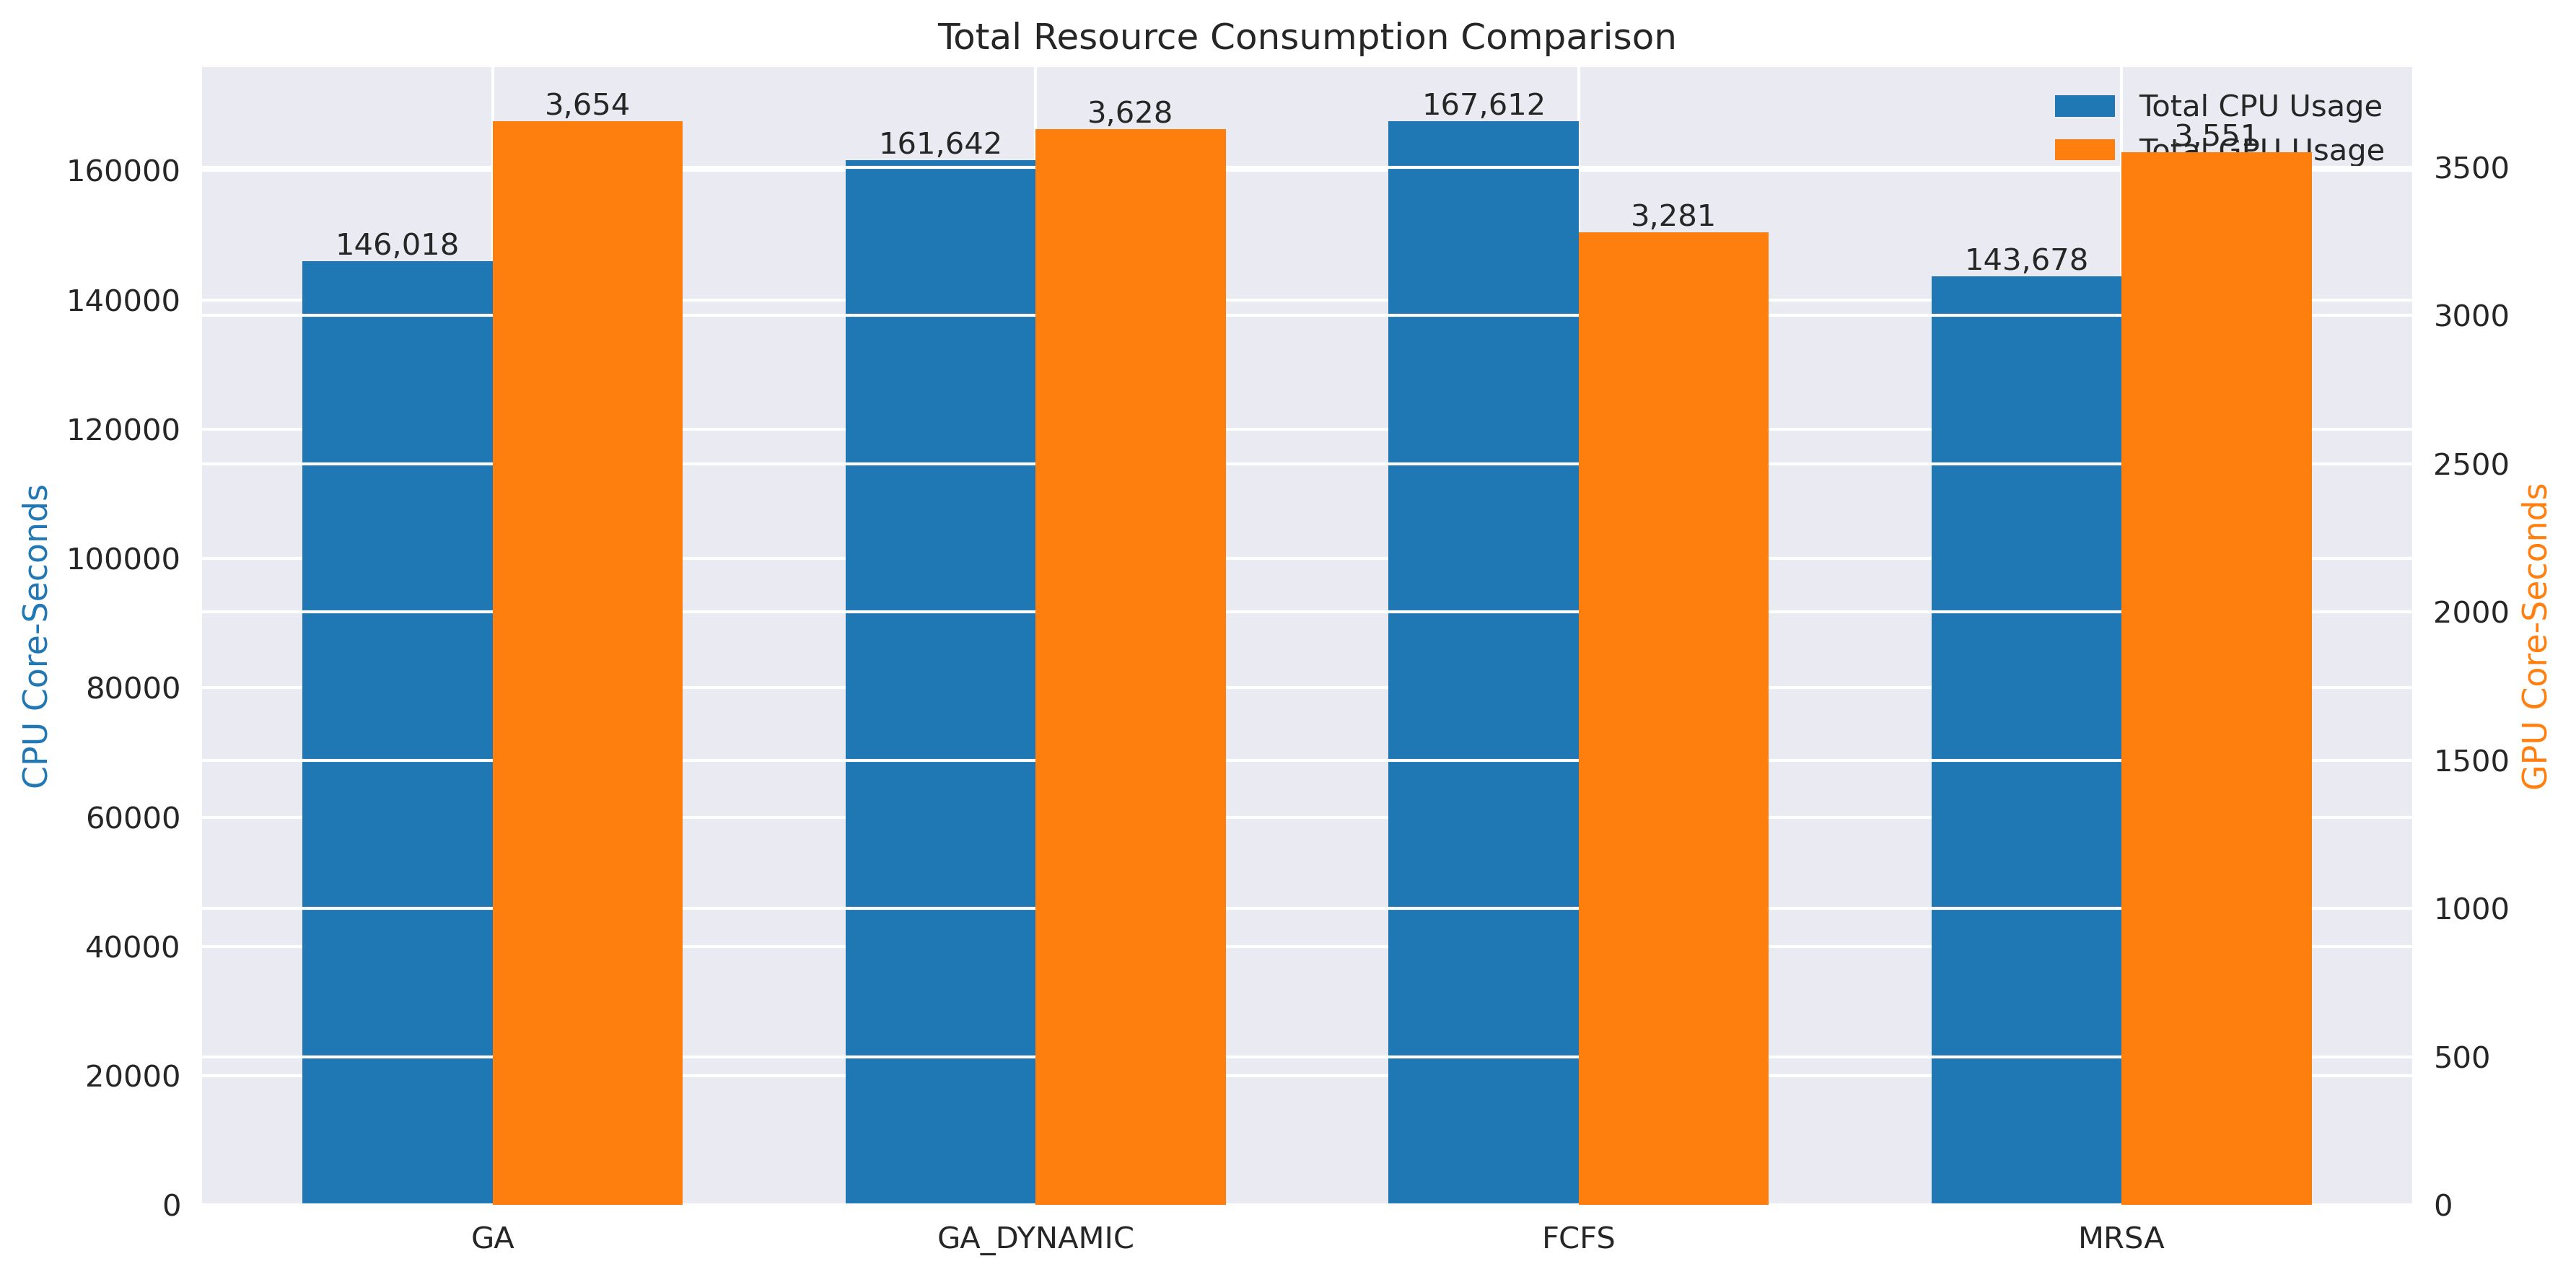

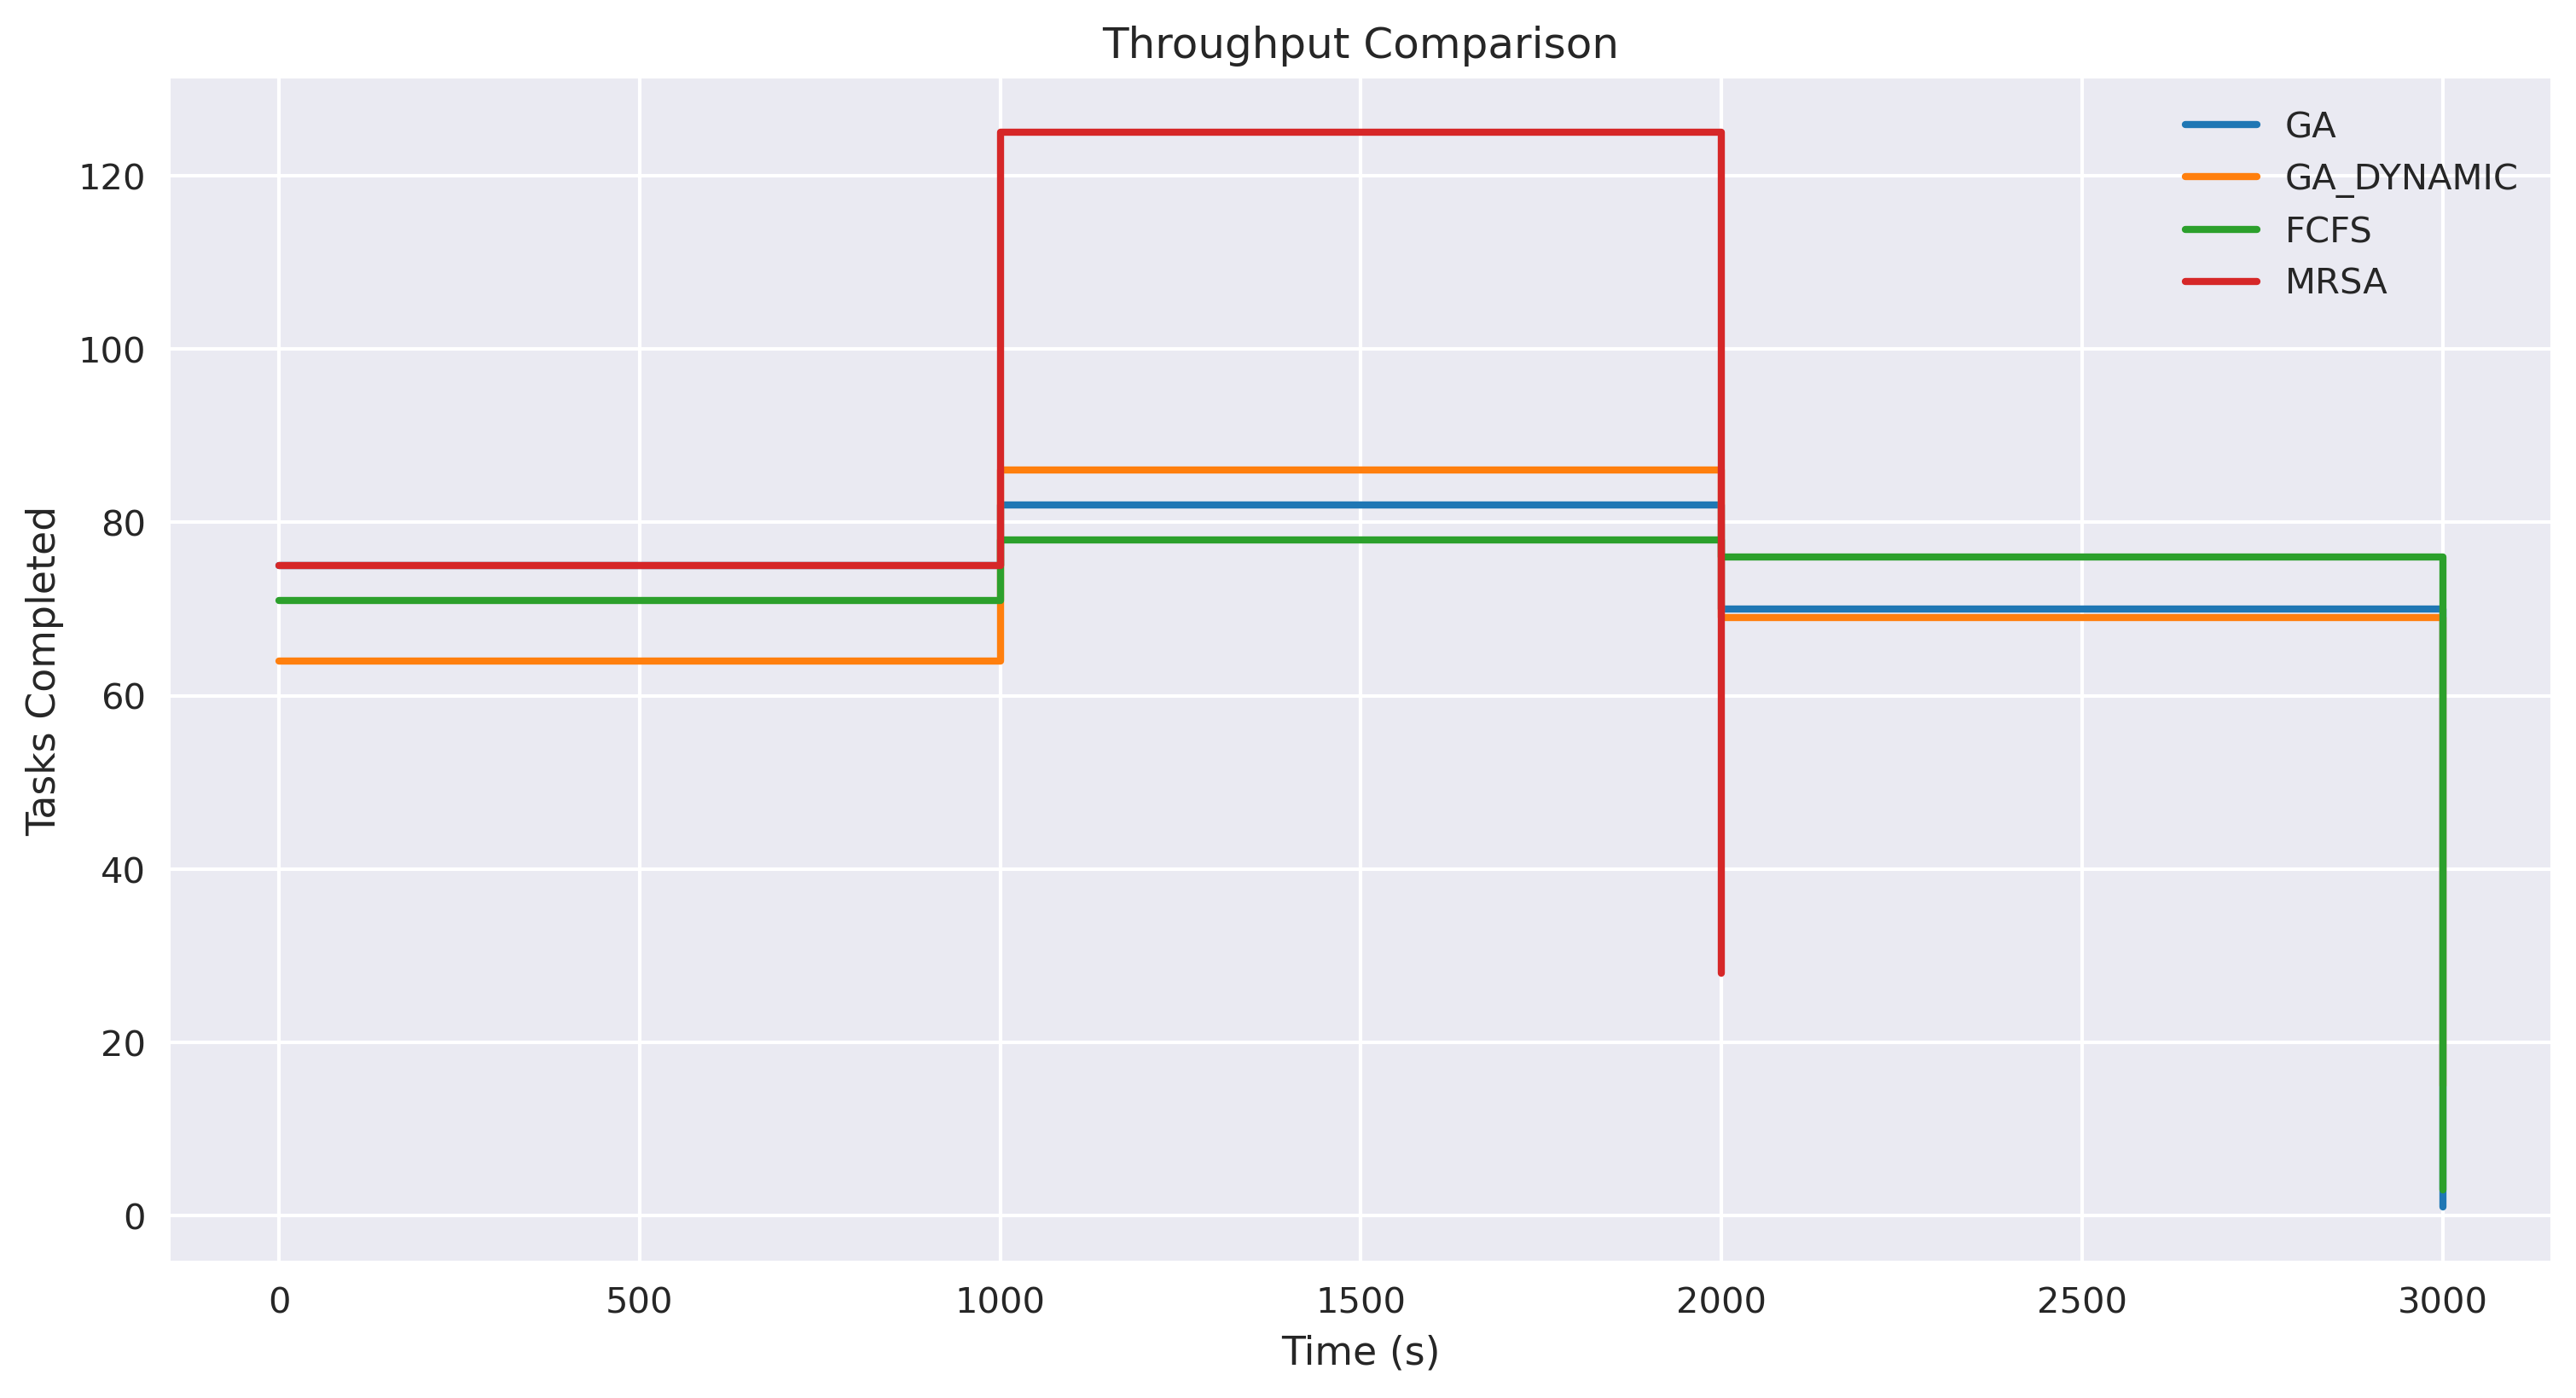

In [ ]:


import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# 先定义数据加载函数
def load_all_stats(scheduler_paths):
    """加载所有调度器的统计数据"""
    all_stats = {}
    
    for name, path in scheduler_paths.items():
        # 加载原始数据
        results = load_results(path, task_type)
        
        # 计算统计数据
        node_stats = calculate_node_stats(results, path.parent.parent / "resources.ini")
        task_stats = calculate_task_stats(results)
        throughput = calculate_throughput(results)
        
        all_stats[name] = {
            'node': node_stats,
            'task': task_stats,
            'throughput': throughput,
            'wct': get_wct(results)  # 获取工作流总时间
        }
    
    return all_stats

# 加载所有数据（示例）
all_stats = load_all_stats(scheduler_paths)

# 设置可视化样式
plt.style.use('seaborn')
scheduler_colors = {
    'ga': '#1f77b4',
    'ga_dynamic': '#ff7f0e',
    'fcfs': '#2ca02c',
    'mrsa': '#d62728'
}

# 1. 节点资源利用率对比
# def plot_node_utilization(all_stats):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

#     # CPU利用率对比（所有节点）
#     cpu_data = {}
#     gpu_data = {}
#     for scheduler, stats in all_stats.items():
#         # 合并所有CPU节点的利用率
#         cpu_util = np.mean([n['cpu_utilization'] for n in stats['node'].values()])
        
#         # 合并所有GPU节点的利用率（gpu_utilization > 0 的节点）
#         gpu_nodes = [n for n in stats['node'].values() if n['gpu_utilization'] > 0]
#         gpu_util = np.mean([n['gpu_utilization'] for n in gpu_nodes]) if gpu_nodes else 0
        
#         cpu_data[scheduler] = cpu_util * 100
#         gpu_data[scheduler] = gpu_util * 100

#     # 绘制柱状图
#     width = 0.35
#     x = np.arange(len(cpu_data))
    
#     ax1.bar(x - width/2, cpu_data.values(), width, label='CPU', color='#4c72b0')
#     ax1.bar(x + width/2, gpu_data.values(), width, label='GPU', color='#55a868')
#     ax1.set_xticks(x)
#     ax1.set_xticklabels([s.upper() for s in cpu_data.keys()])
#     ax1.set_ylabel('Utilization (%)')
#     ax1.set_title('Average Resource Utilization')
#     ax1.legend()

#     # 资源配置分布玫瑰图
#     node_types = defaultdict(int)
#     for stats in all_stats.values():
#         for node in stats['node'].values():
#             key = f"{node.get('gpu_utilization',0)*100:.0f}% GPU\n{node.get('cpu_utilization',0)*100:.0f}% CPU"
#             node_types[key] += 1

#     ax2.pie(node_types.values(), labels=node_types.keys(),
#            autopct='%1.1f%%', startangle=90,
#            colors=plt.cm.Paired(np.linspace(0, 1, len(node_types))),
#            wedgeprops=dict(width=0.5))
#     ax2.set_title('Resource Utilization Distribution')

#     plt.tight_layout()
def plot_total_utilization(all_stats, resources_path):
    # 加载节点资源配置
    node_config = parse_resources_ini(resources_path)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 准备数据
    schedulers = list(all_stats.keys())
    cpu_utils = []
    gpu_utils = []
    
    for scheduler, stats in all_stats.items():
        total_cpu_util = 0
        total_gpu_util = 0
        
        # 计算加权平均值
        for node_name, node_stats in stats['node'].items():
            # 获取节点配置
            config = node_config.get(node_name, {'cpus': 0, 'gpus': 0})
            
            # CPU加权计算
            cpu_weight = config['cpus']
            total_cpu_util += node_stats['cpu_utilization'] * cpu_weight
            
            # GPU加权计算
            if config['gpus'] > 0:
                gpu_weight = config['gpus']
                total_gpu_util += node_stats['gpu_utilization'] * gpu_weight
        
        # 计算总权重
        total_cpu_cores = sum(n['cpus'] for n in node_config.values())
        total_gpu_units = sum(n['gpus'] for n in node_config.values())
        
        cpu_utils.append(total_cpu_util / total_cpu_cores * 100 if total_cpu_cores >0 else 0)
        gpu_utils.append(total_gpu_util / total_gpu_units * 100 if total_gpu_units >0 else 0)

    # 绘制柱状图
    x = np.arange(len(schedulers))
    width = 0.35
    
    rects1 = ax.bar(x - width/2, cpu_utils, width, label='CPU Utilization', color='#1f77b4')
    rects2 = ax.bar(x + width/2, gpu_utils, width, label='GPU Utilization', color='#ff7f0e')
    
    # 添加标签和样式
    ax.set_ylabel('Utilization Rate (%)')
    ax.set_title('Total Resource Utilization by Scheduler')
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in schedulers])
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    # 添加数据标签
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    autolabel(rects1)
    autolabel(rects2)
    
    plt.ylim(0, max(max(cpu_utils), max(gpu_utils)) * 1.2)
    plt.tight_layout()

# 使用示例（需要传入resources.ini路径）
# plot_total_utilization(all_stats, Path('/path/to/resources.ini'))

# 2. 任务资源消耗对比
def plot_resource_usage(all_stats):
    """统一呈现CPU/GPU总利用率"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 准备数据
    schedulers = list(all_stats.keys())
    cpu_totals = []
    gpu_totals = []
    
    for scheduler in schedulers:
        # 计算总CPU利用率（所有任务类型的总和）
        cpu_total = sum(
            t_stats['total_cpu_area'] 
            for t_stats in all_stats[scheduler]['task'].values()
        )
        cpu_totals.append(cpu_total)
        
        # 计算总GPU利用率
        gpu_total = sum(
            t_stats['total_gpu_area'] 
            for t_stats in all_stats[scheduler]['task'].values()
        )
        gpu_totals.append(gpu_total)

    # 标准化处理（可选）
    max_cpu = max(cpu_totals)
    max_gpu = max(gpu_totals)
    cpu_norm = [x/max_cpu*100 for x in cpu_totals]
    gpu_norm = [x/max_gpu*100 for x in gpu_totals] if max_gpu > 0 else [0]*len(gpu_totals)

    # 绘制双轴柱状图
    ax1 = ax
    ax2 = ax1.twinx()
    
    width = 0.35
    x = np.arange(len(schedulers))
    
    # CPU柱状图
    bars1 = ax1.bar(x - width/2, cpu_totals, width, 
                   color='#1f77b4', label='Total CPU Usage')
    # GPU柱状图
    bars2 = ax2.bar(x + width/2, gpu_totals, width, 
                   color='#ff7f0e', label='Total GPU Usage')

    # 标签和样式设置
    ax1.set_ylabel('CPU Core-Seconds', color='#1f77b4')
    ax2.set_ylabel('GPU Core-Seconds', color='#ff7f0e')
    ax1.set_xticks(x)
    ax1.set_xticklabels([s.upper() for s in schedulers])
    ax1.set_title('Total Resource Consumption Comparison')
    
    # 添加数据标签
    def add_labels(bars, ax):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:,.0f}',
                    ha='center', va='bottom')
    
    add_labels(bars1, ax1)
    if max_gpu > 0:
        add_labels(bars2, ax2)

    # 合并图例
    lines = [bars1, bars2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    plt.tight_layout()

# 3. 吞吐量对比
def plot_throughput(all_stats):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    max_wct = max(s['wct'] for s in all_stats.values())
    time_bins = np.arange(0, max_wct+1000, 1000)
    
    for scheduler, stats in all_stats.items():
        total_counts = []
        for window in stats['throughput']:
            total_counts.append(sum(window['counts'].values()))
        
        # 对齐时间轴
        x = [w['window'][0] for w in stats['throughput']]
        ax.step(x, total_counts, where='post', 
               label=scheduler.upper(), 
               linewidth=2,
               color=scheduler_colors[scheduler])
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Tasks Completed')
    ax.set_title('Throughput Comparison')
    ax.legend()
    ax.grid(True)

# 执行所有绘图
# plot_node_utilization(all_stats)
plot_resource_usage(all_stats)
plot_throughput(all_stats)
plt.show()

NameError: name 'mpatches' is not defined

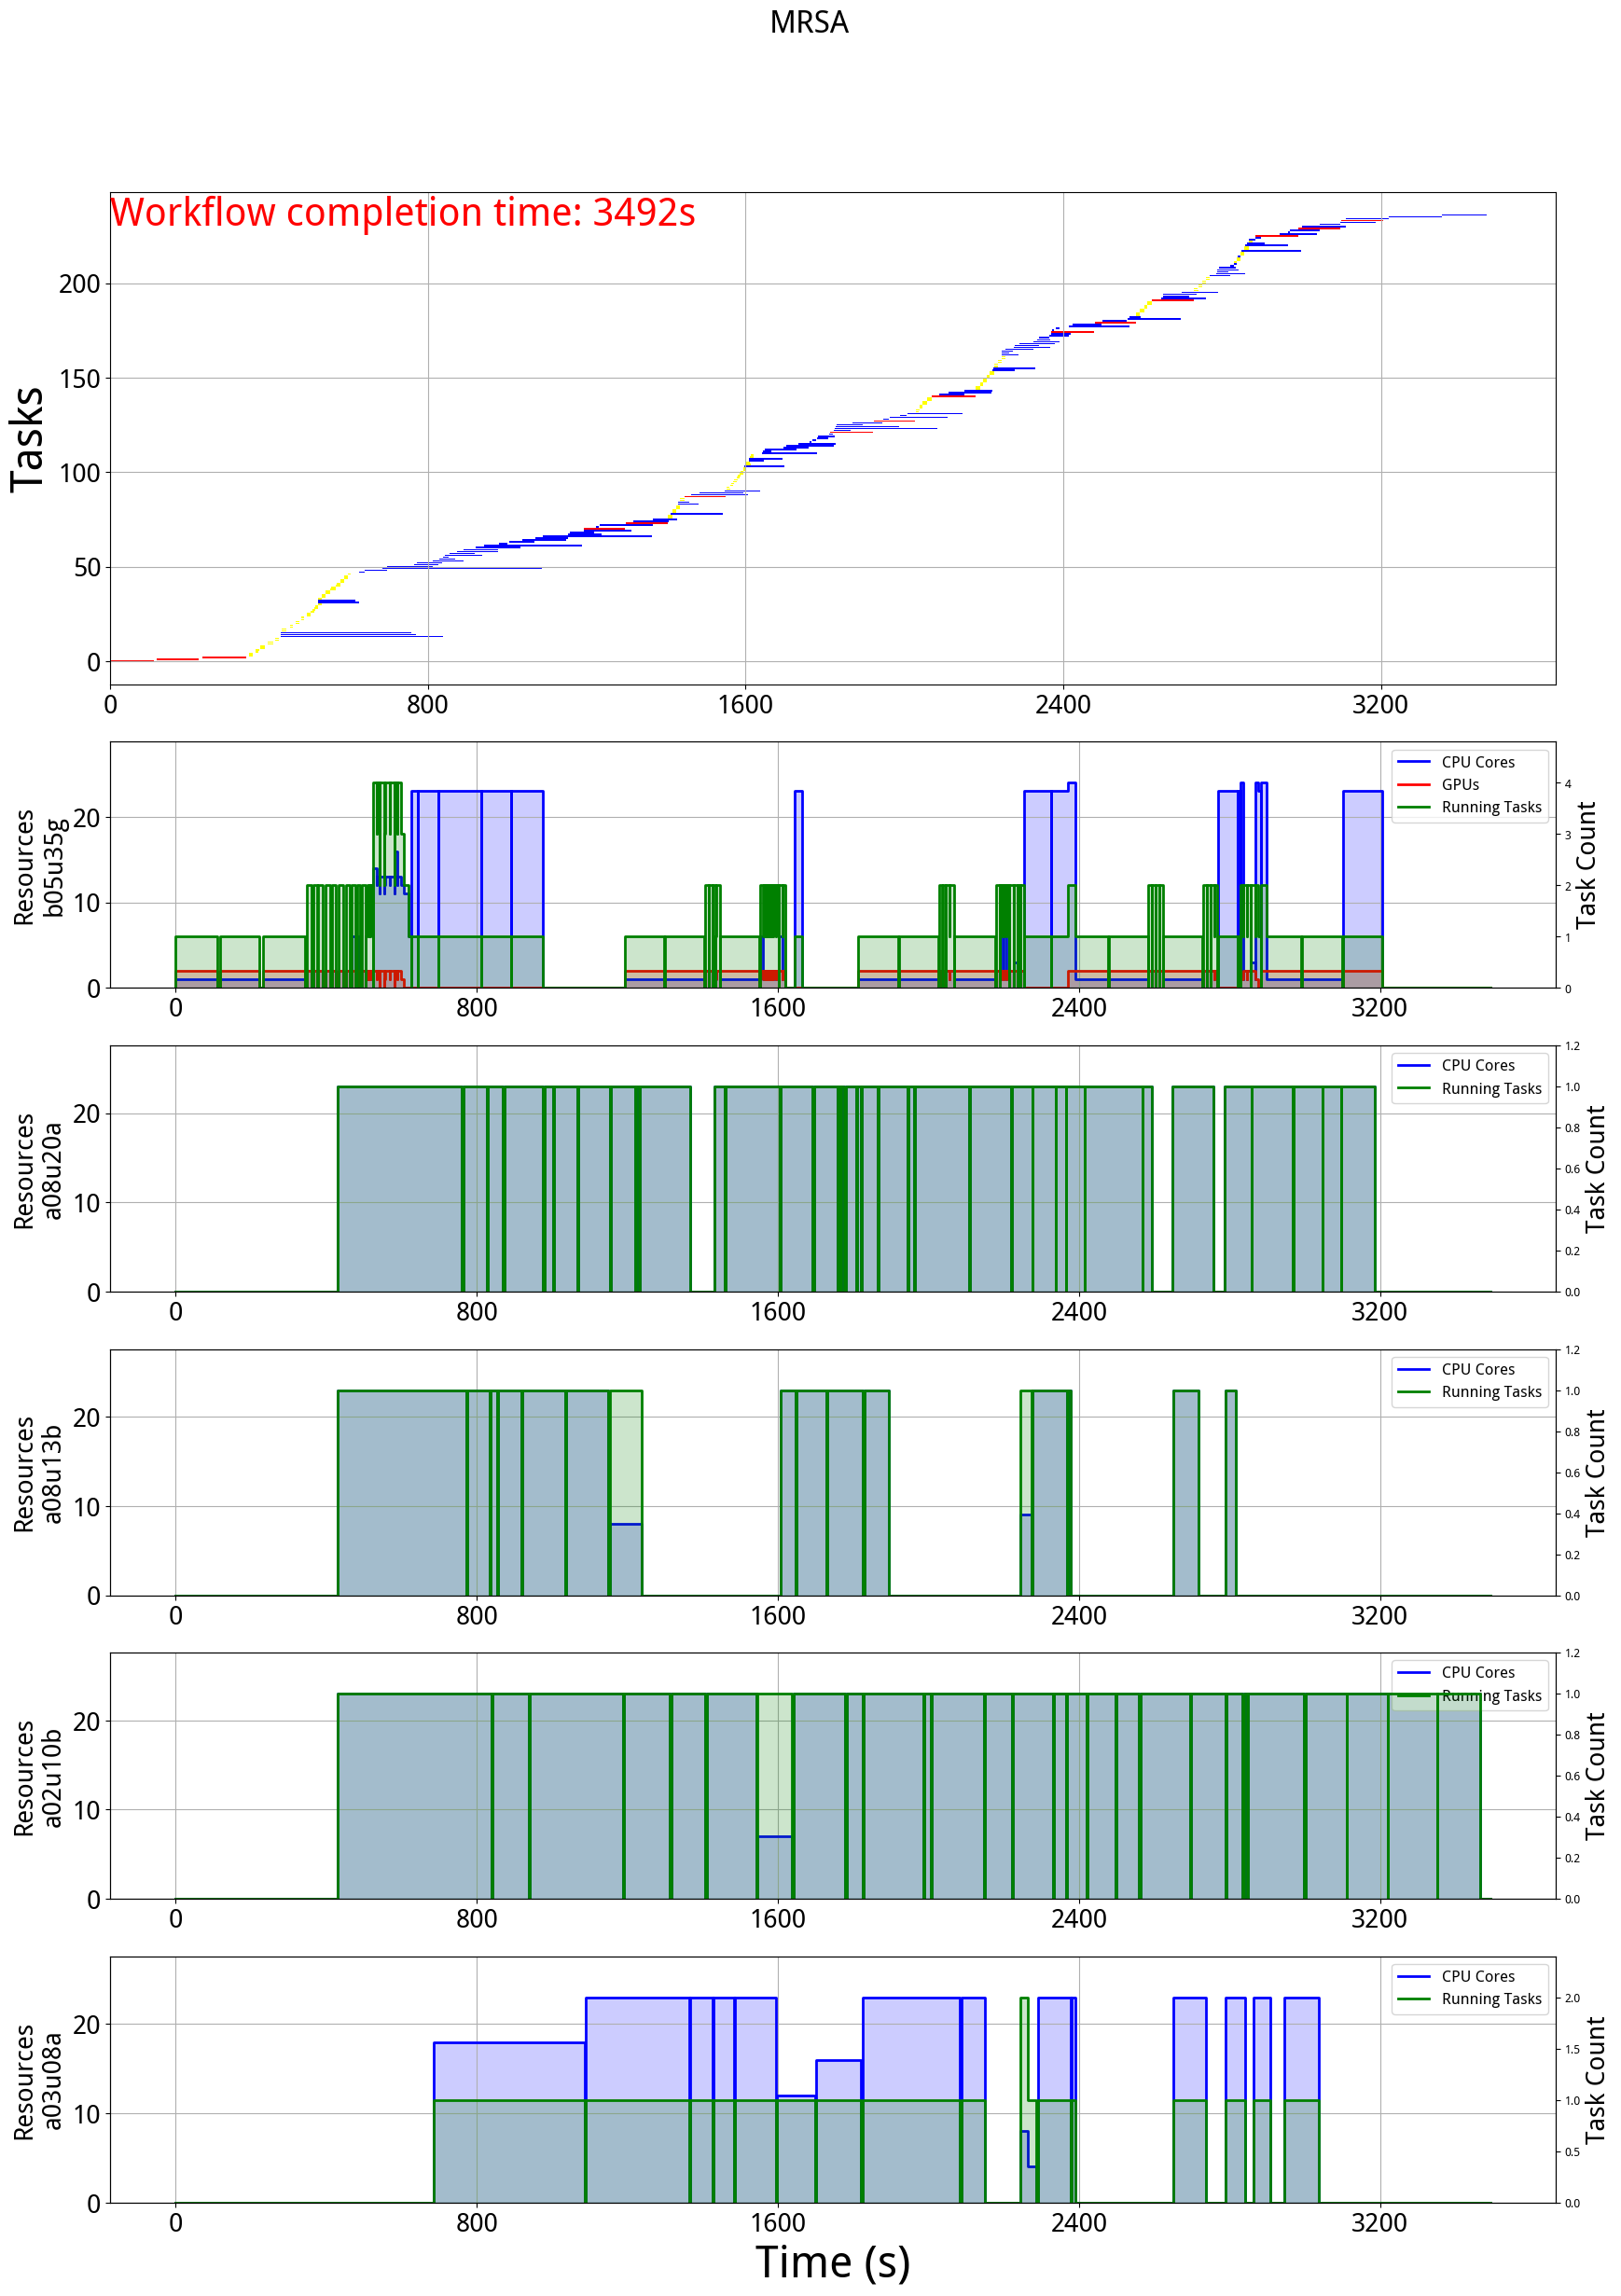

In [26]:
# mrsa
mrsa_test_path = Path('/home/yxx/project/colmena/multisite_/finetuning-surrogates/runs/test1_4c_1g/20250321_064208_mrsa_2_3492s/dft-md-25Mar21-064247-91d4cf')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="MRSA")

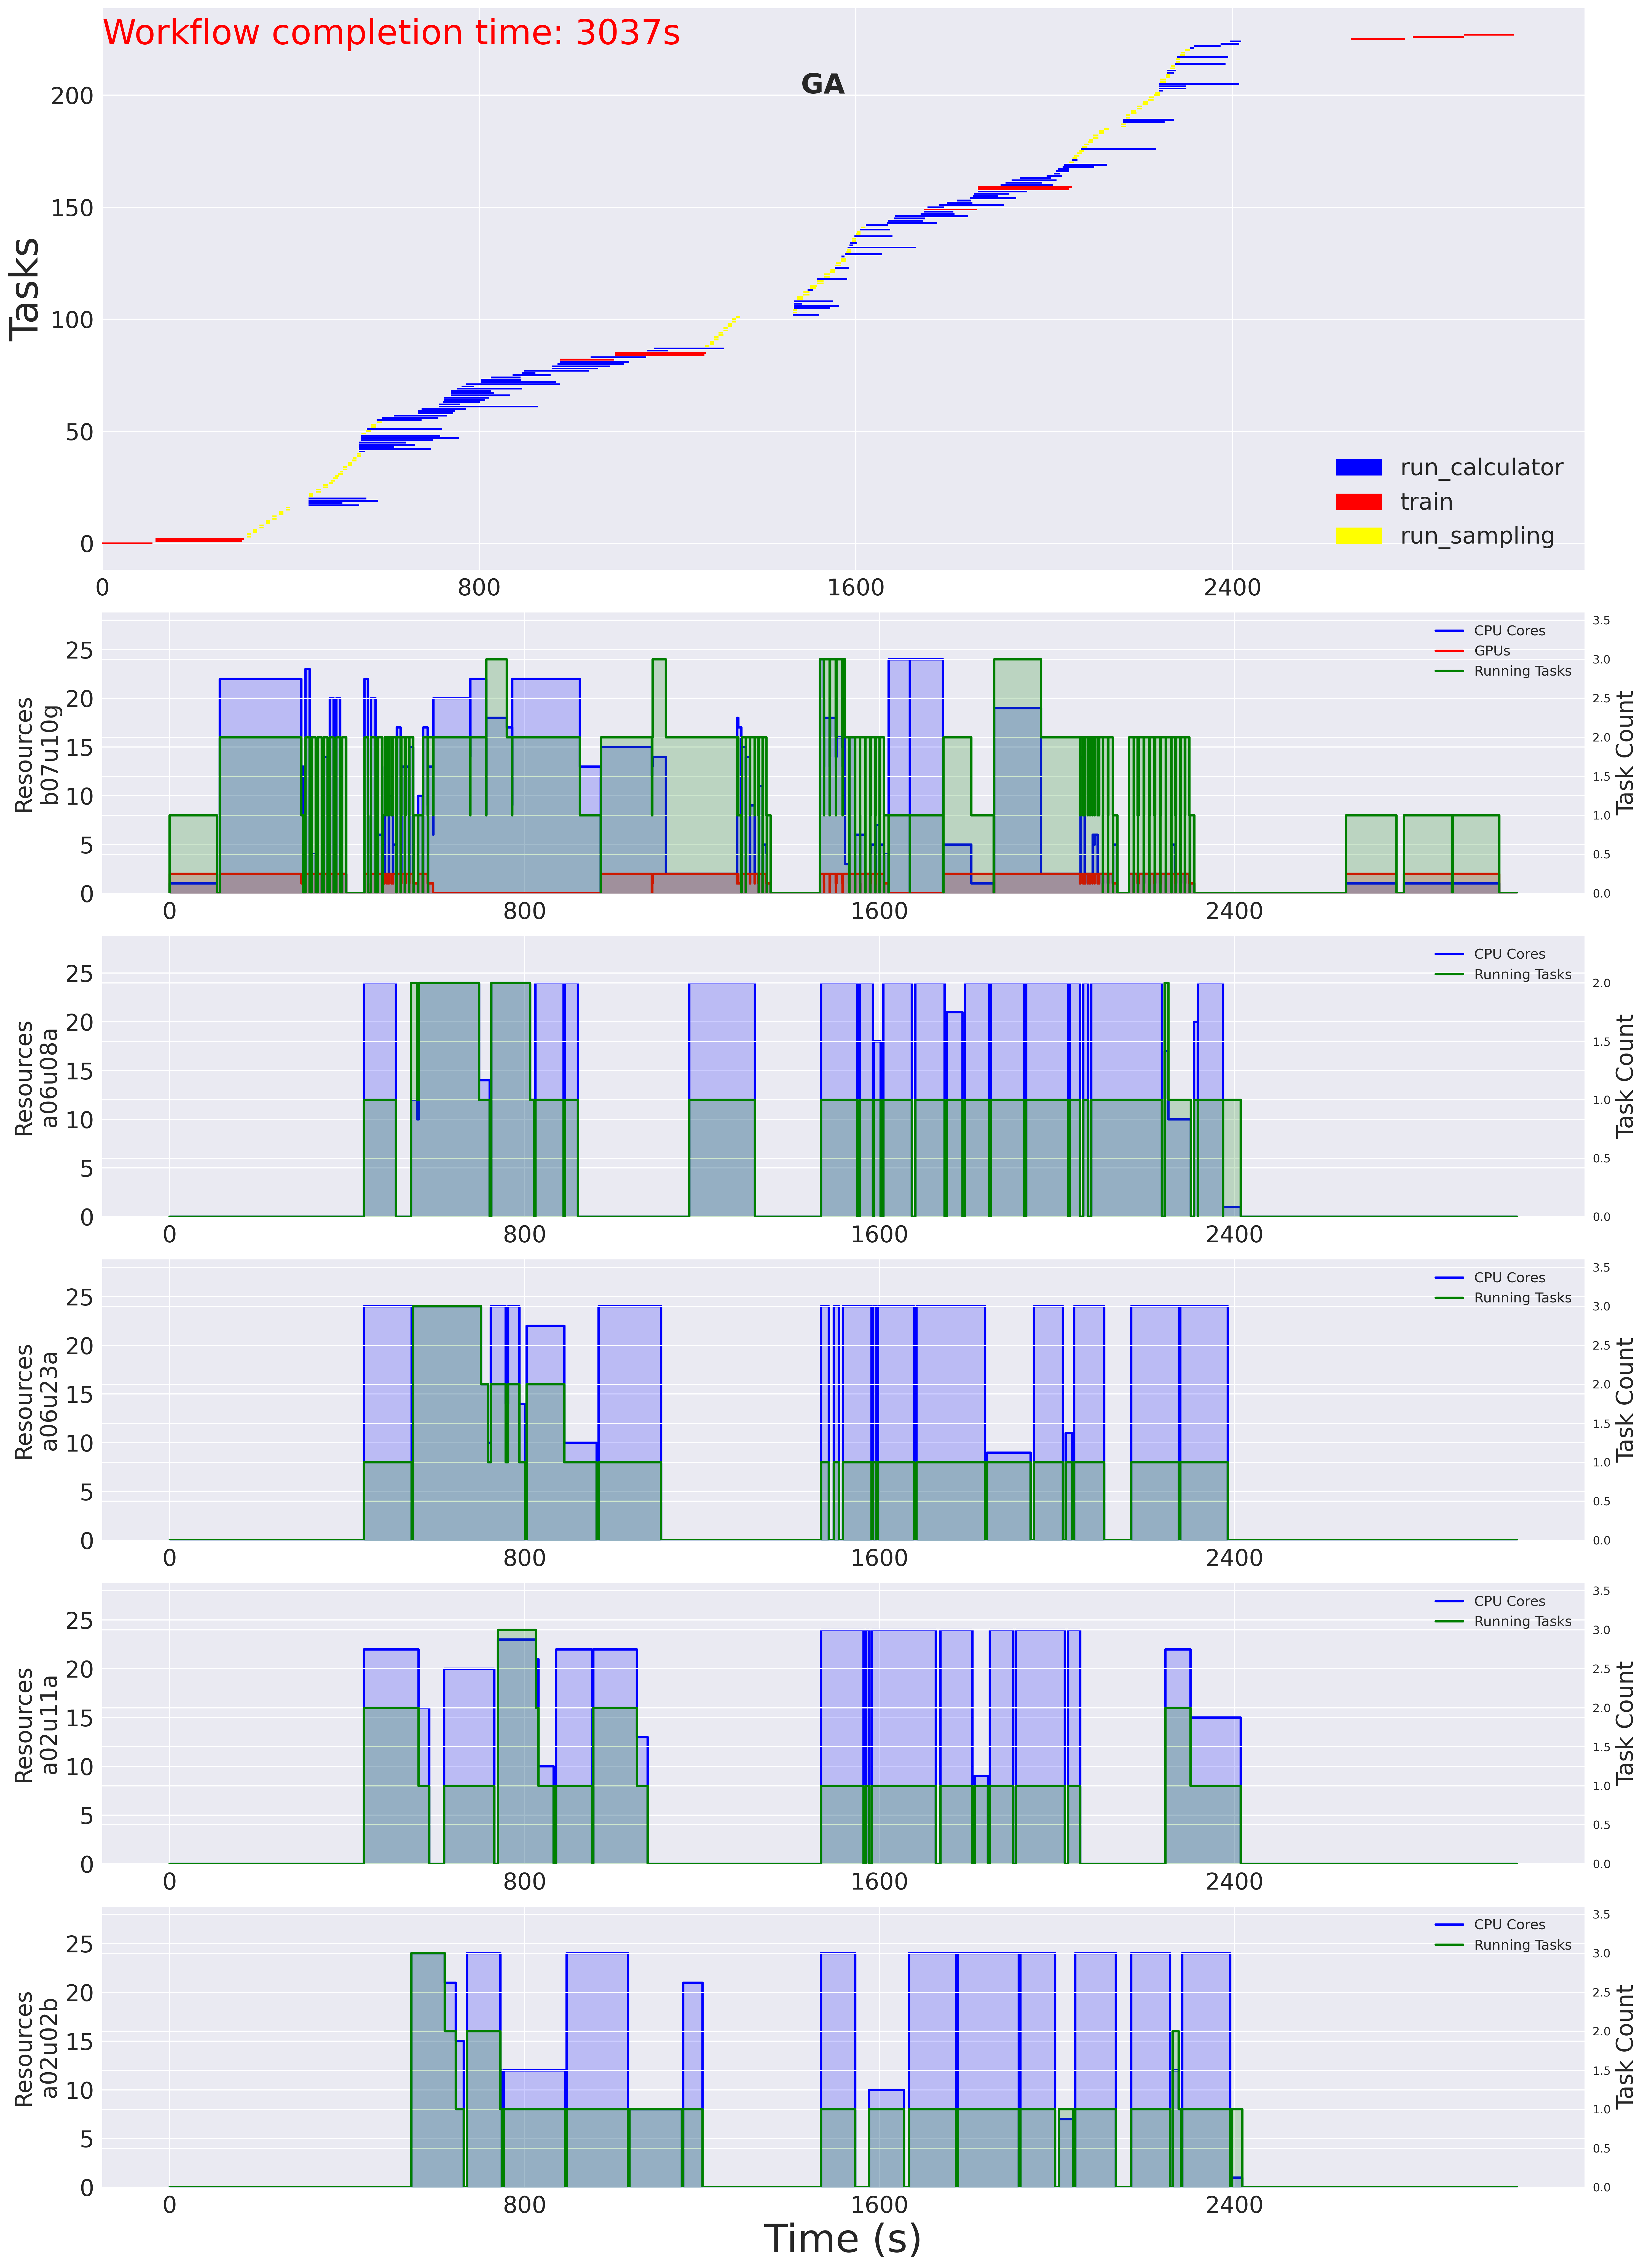

In [40]:
mrsa_test_path = Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/save_runs/20250228_082313_ga_basic/dft-md-25Feb28-082342-278820')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="GA")

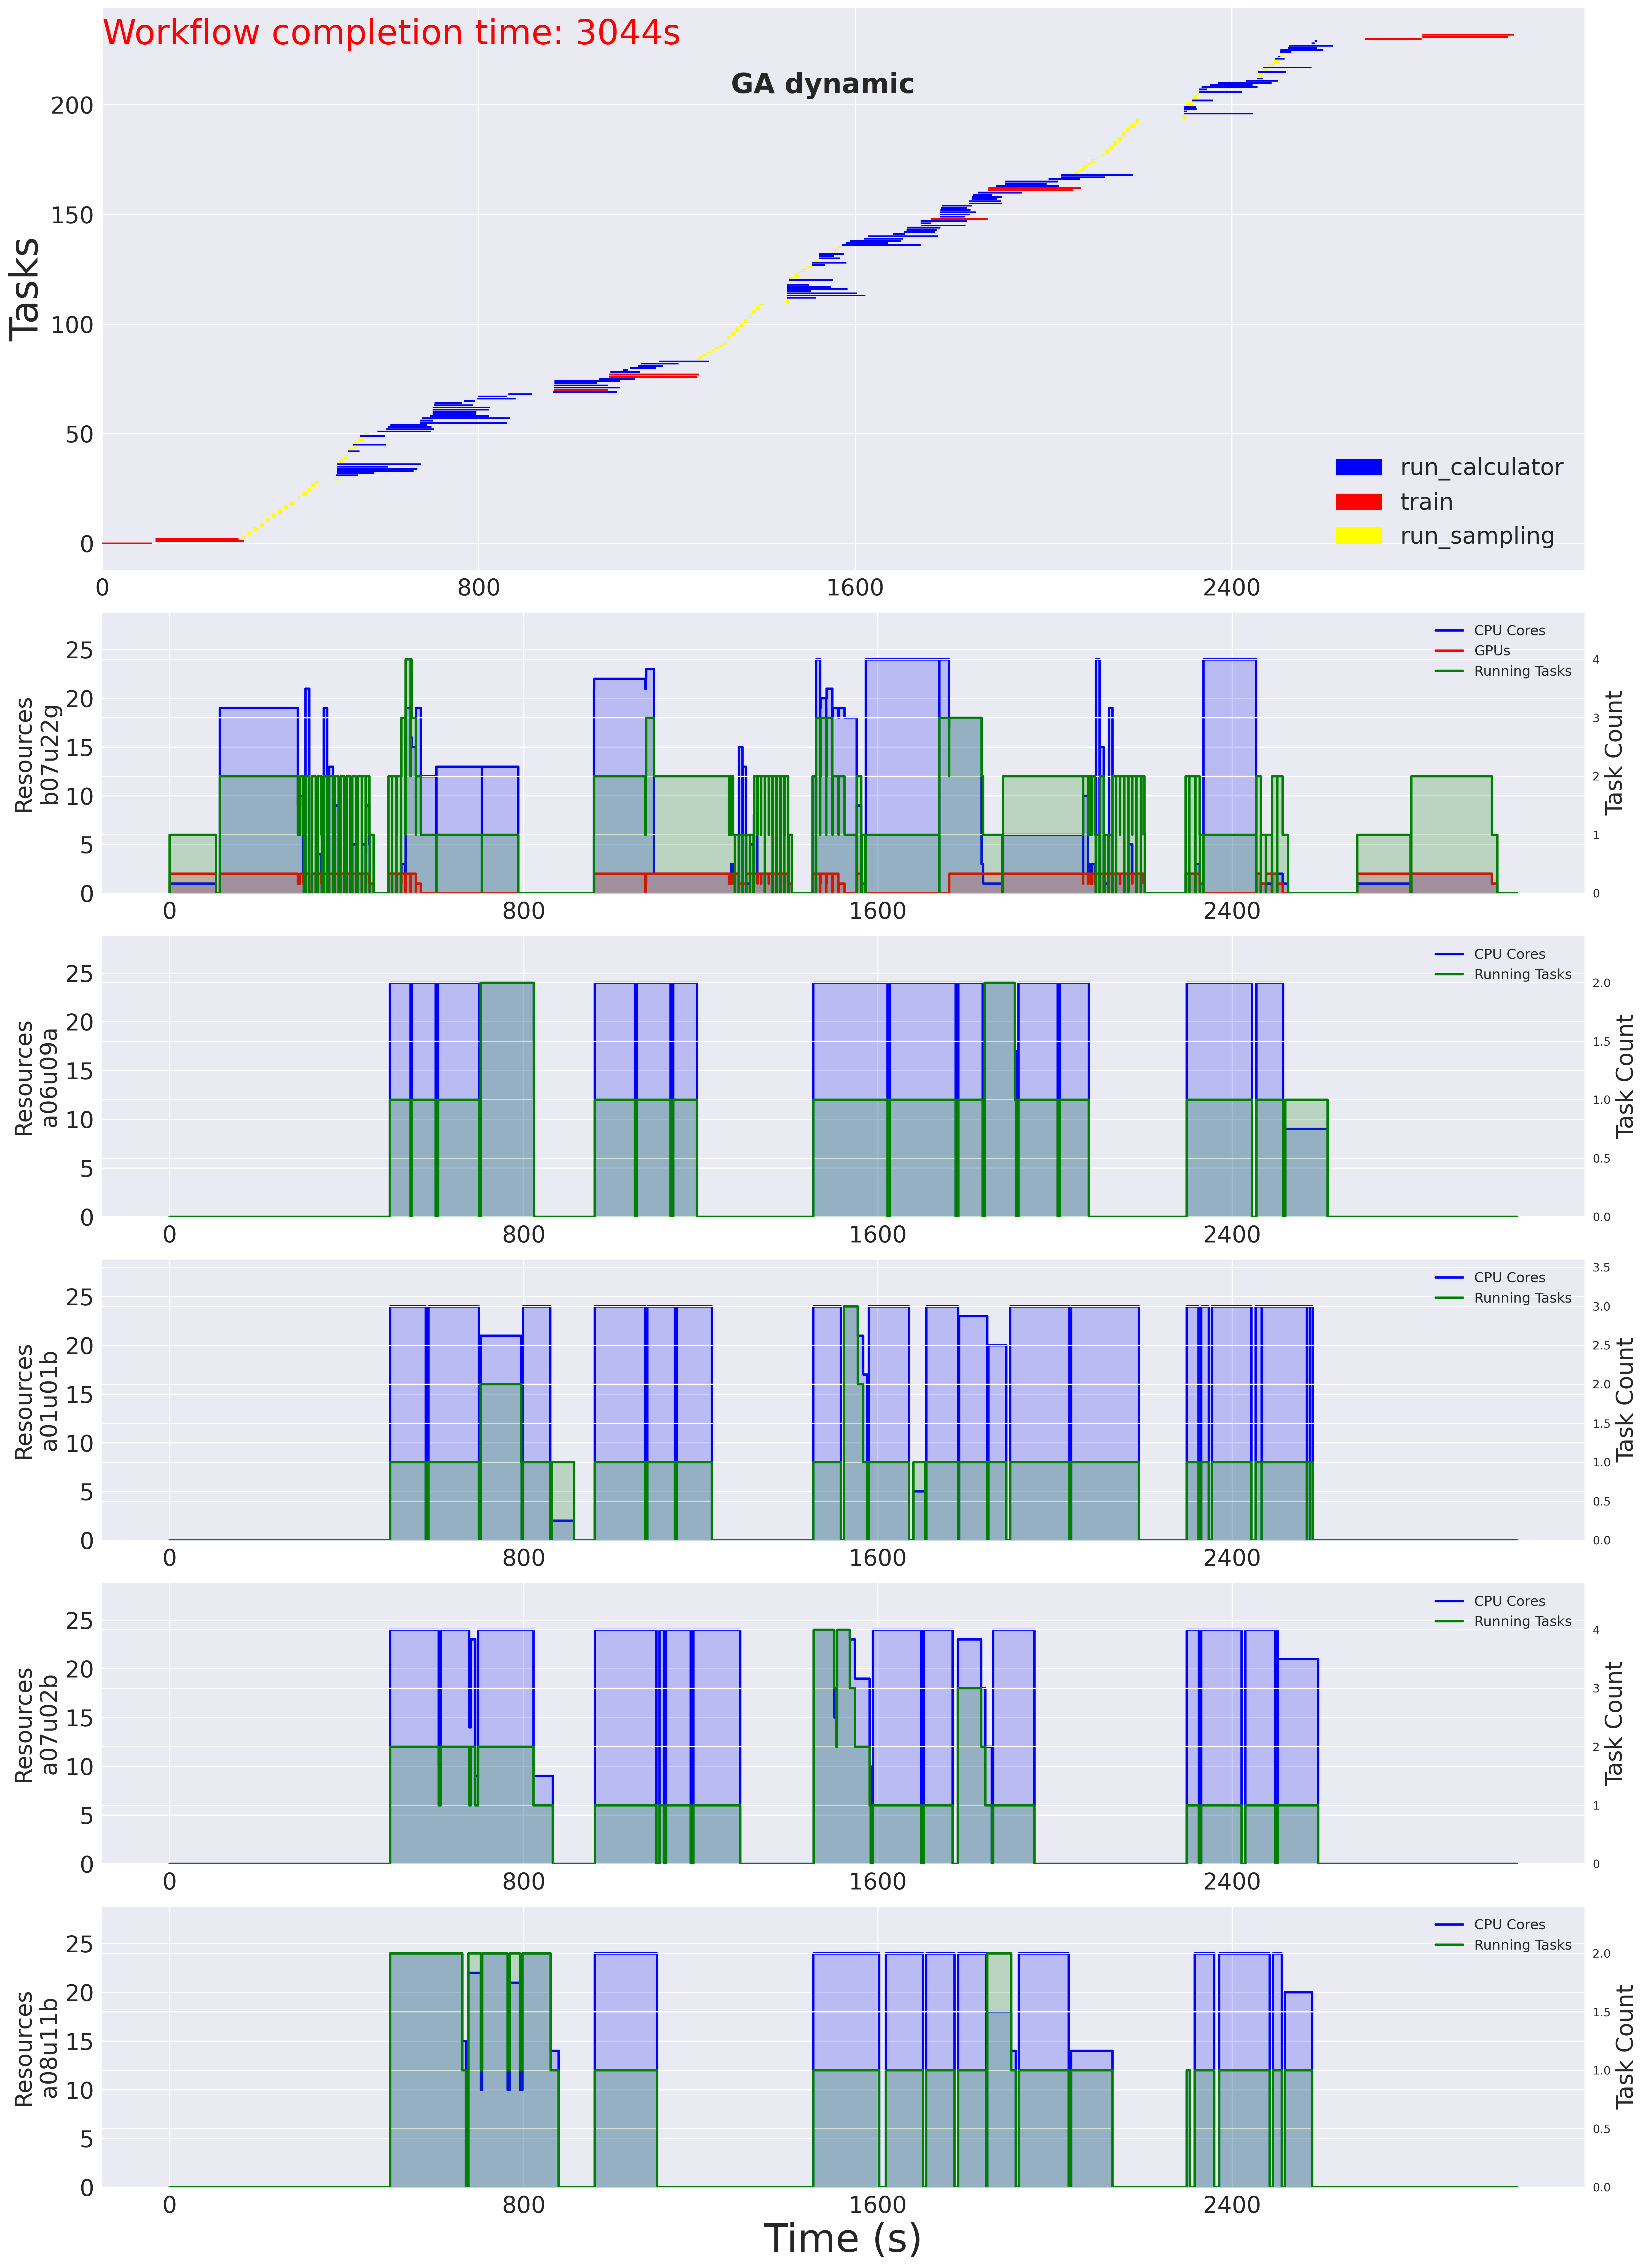

In [43]:
mrsa_test_path = Path('/work/cse-yuanxx/project/colmena/multisite_/finetuning-surrogates/runs/20250314_013806/dft-md-25Mar14-013849-2d9c22')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="GA dynamic")

NameError: name 'mpatches' is not defined

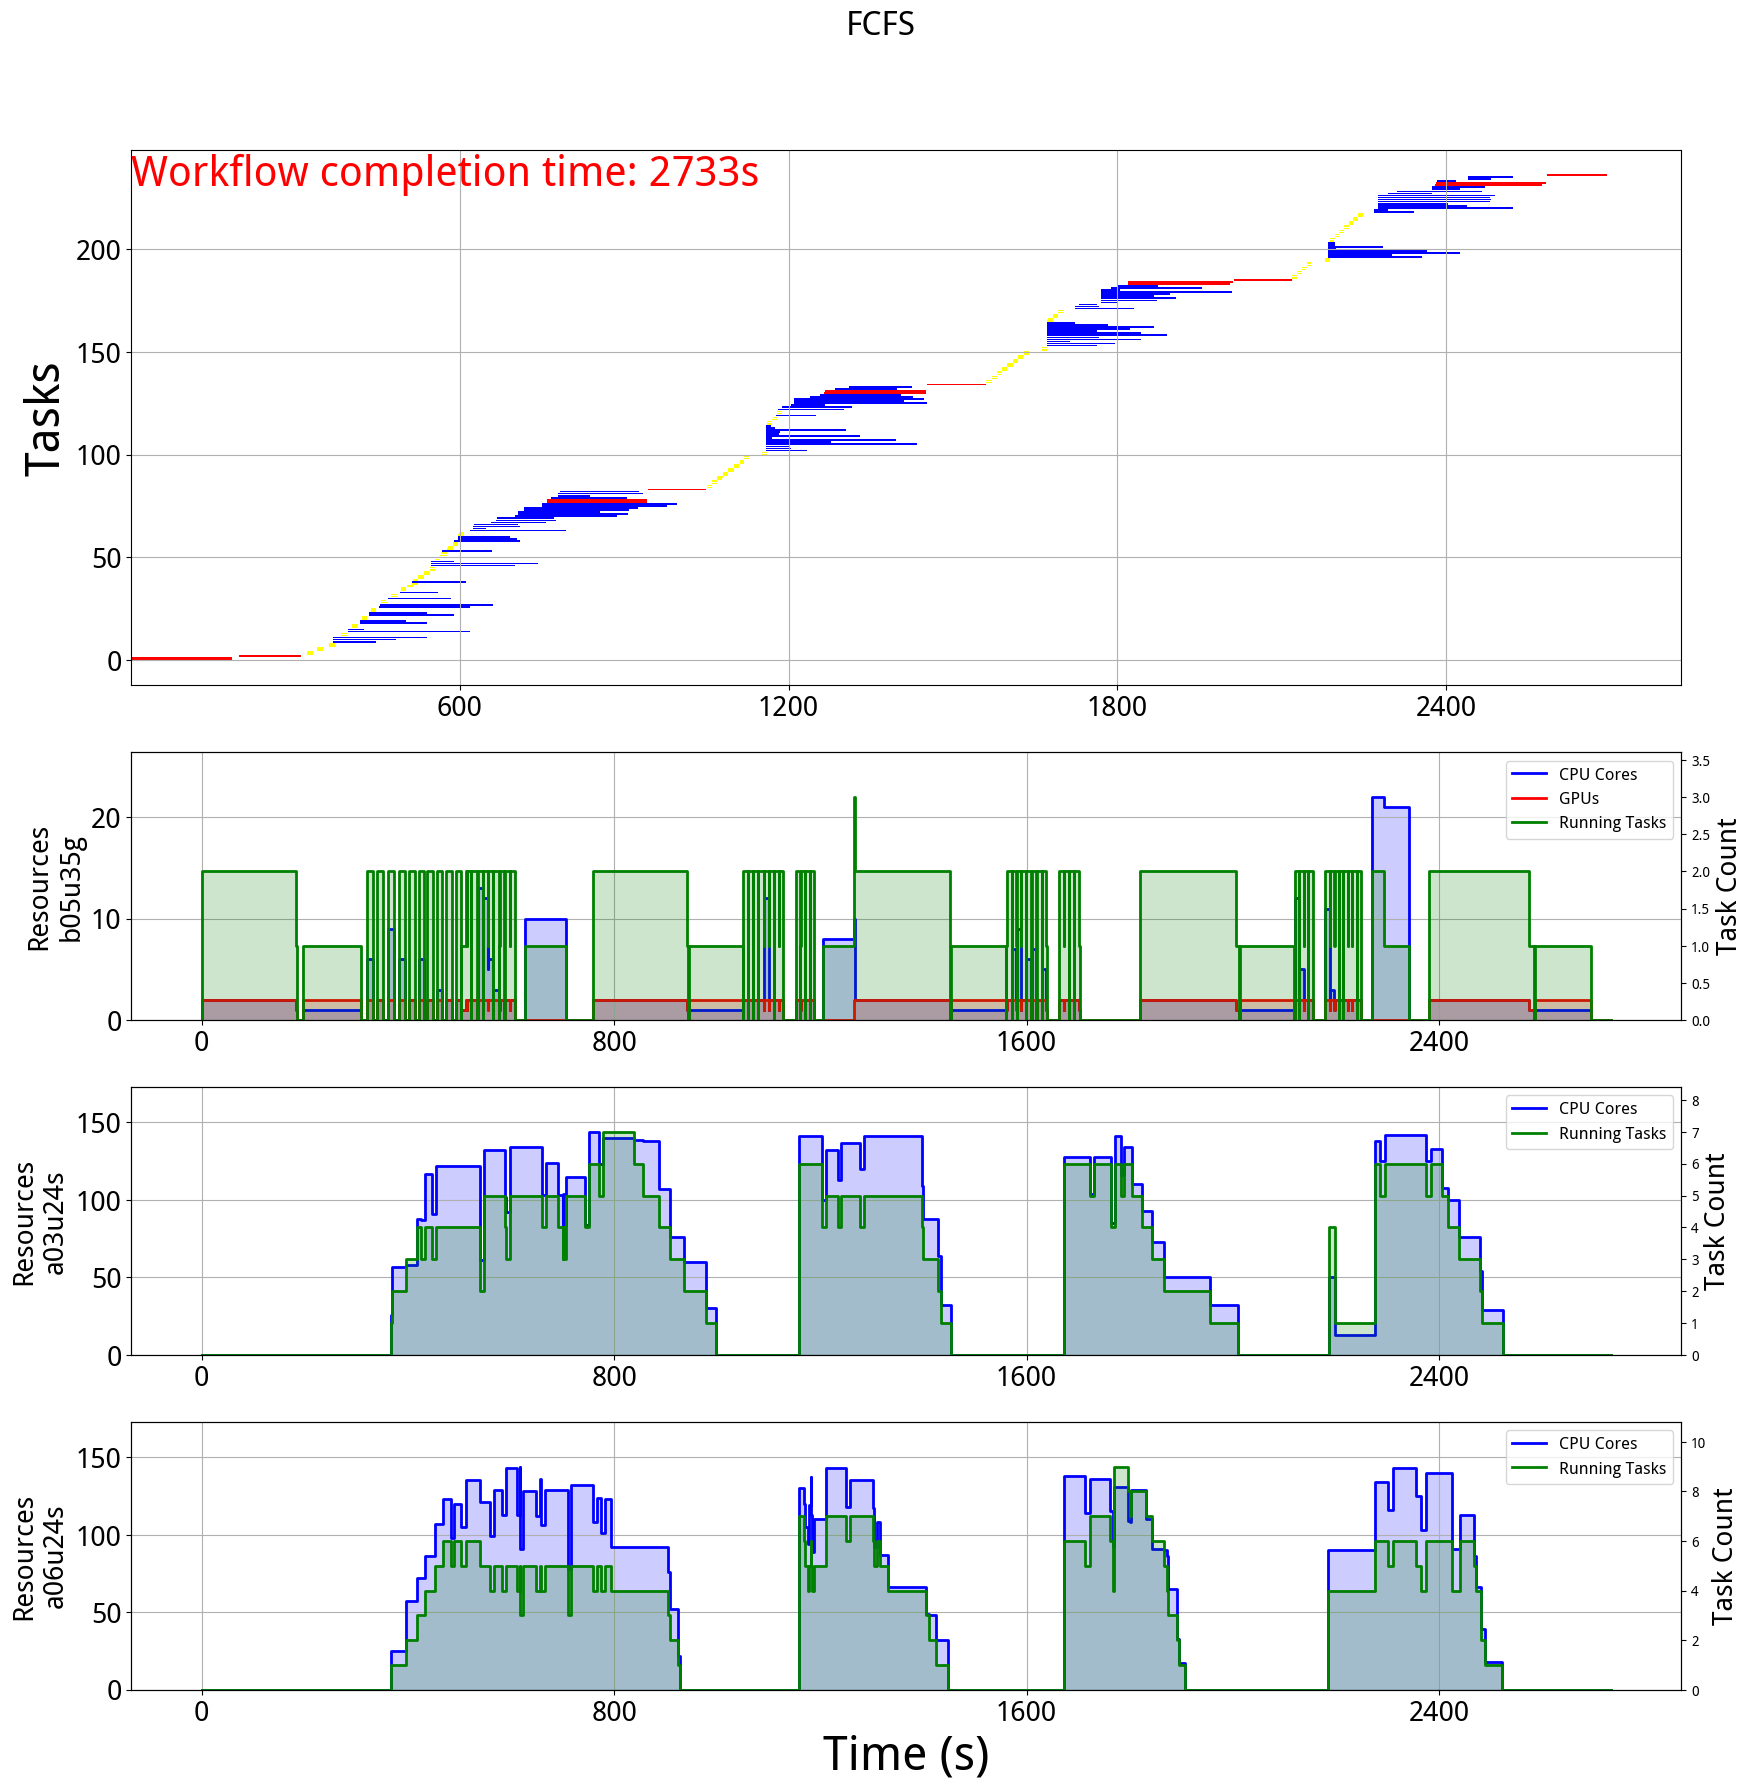

In [13]:
mrsa_test_path = Path('/home/yxx/project/colmena/multisite_/finetuning-surrogates/runs/test2_more_cpu/20250401_181152_ga_basic_2gpu_2733/dft-md-25Apr01-181247-968e04')
results = load_results(mrsa_test_path, task_type=task_type)
time_line_graph(results=results, task_color=task_color, title="FCFS")